In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic, EnCodecLatentDataset_dynamic_v2, latents_to_audio_simple, efficient_codes_to_latents
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None #str(Path("./output/20250817_151624_pistons_2048.16_4.96/"))  # None # 

dataset="syntex" # "ddsp_violin"

if dataset=="syntex": # syntex
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test_HARDcascade" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="nsynth_soft_cascade"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":
    sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    savename="quickstart_softcascade"  #just a tag on the output folder 
    props={"pos": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)

params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 225, # #20, # of batches_per_epoch of batch_size sequeunce
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 125, #75, #14379, # 125, # 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 1,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "hard",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.6,
    top_n_soft = None,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=2, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off

props are {'c1': (0, 1), 'c2': (0, 1), 'c3': (0, 1), 'c4': (0, 1), 'c5': (0, 1), 'c6': (0, 1), 'c7': (0, 1), 'param1': (0, 1)}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2025-10-25_16-14-49',
 'datadir': '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/working/RNeNcodec/notebooks/output',
 'num_epochs': 225,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 125,
 'lr': 0.005,
 'props': {'c1': (0, 1),
  'c2': (0, 1),
  'c3': (0, 1),
  'c4': (0, 1),
  'c5': (0, 1),
  'c6': (0, 1),
  'c7': (0, 1),
  'param1': (0, 1)},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 1,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'hard',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperature_hard': 1.0,
 'tau_soft': 0.6,
 'to

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] No filters provided; using all 4410 rows.
Loaded 1375920 sequences from 4410 files in 'train_sm' split
[EnCodecLatentDataset] No filters provided; using all 147 rows.
Loaded 45864 sequences from 147 files in 'val' split
size of dataset is 1375920
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 1375920
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([125, 8])
pvect[0]: tensor([0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.3000])
pvect[last]: tensor([0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.1000])
inp.shape is torch.Size([125, 128])


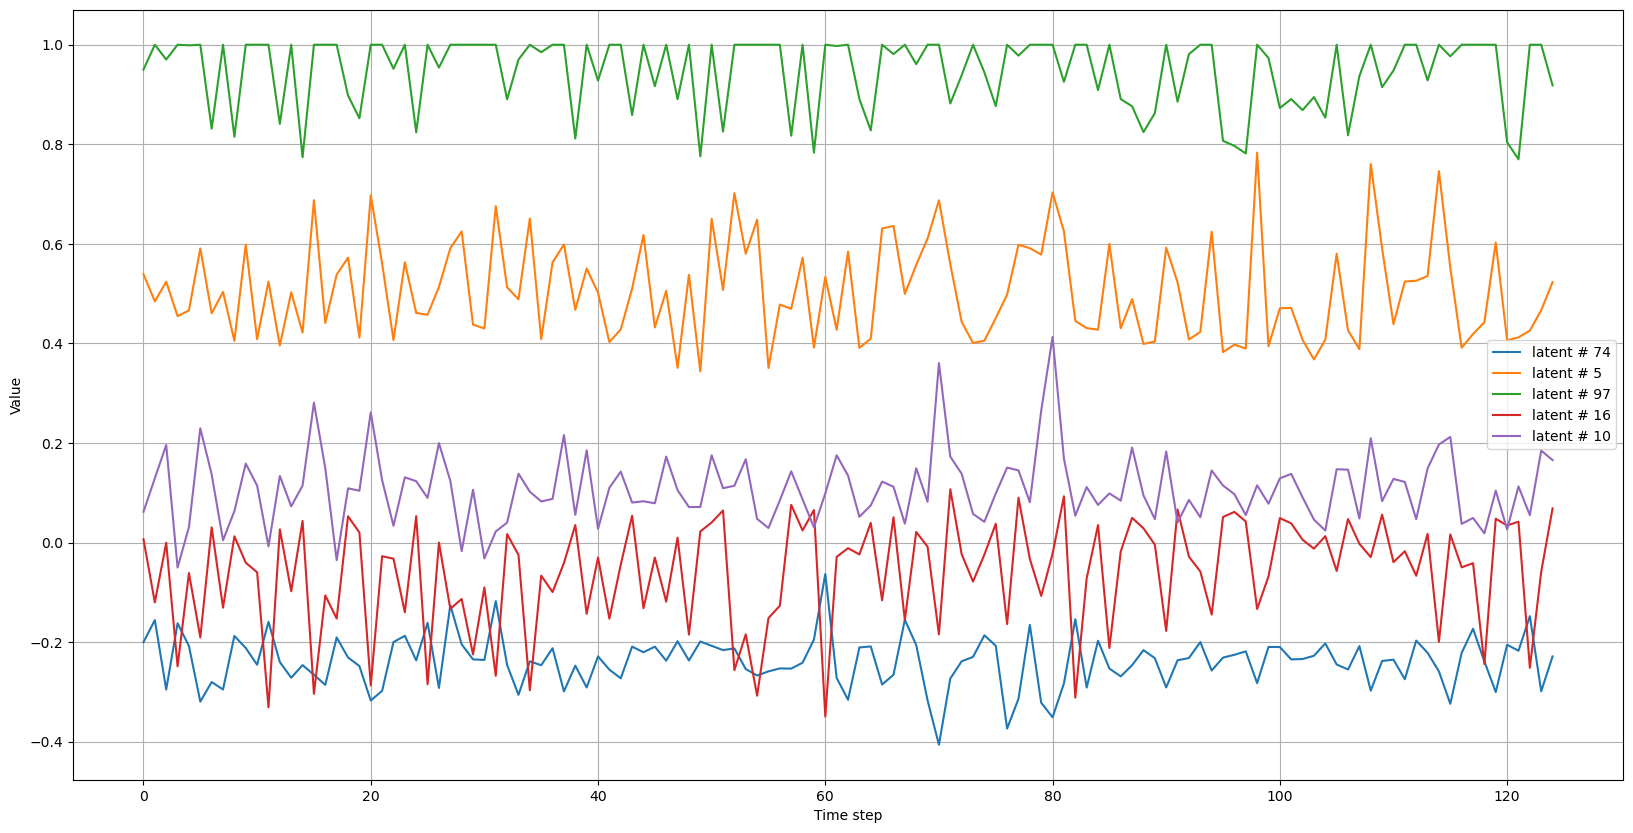

SHAPE: torch.Size([1, 128, 125])


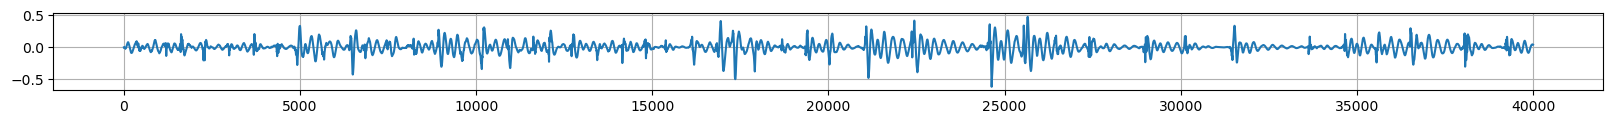

conditioning.shap = torch.Size([125, 8])


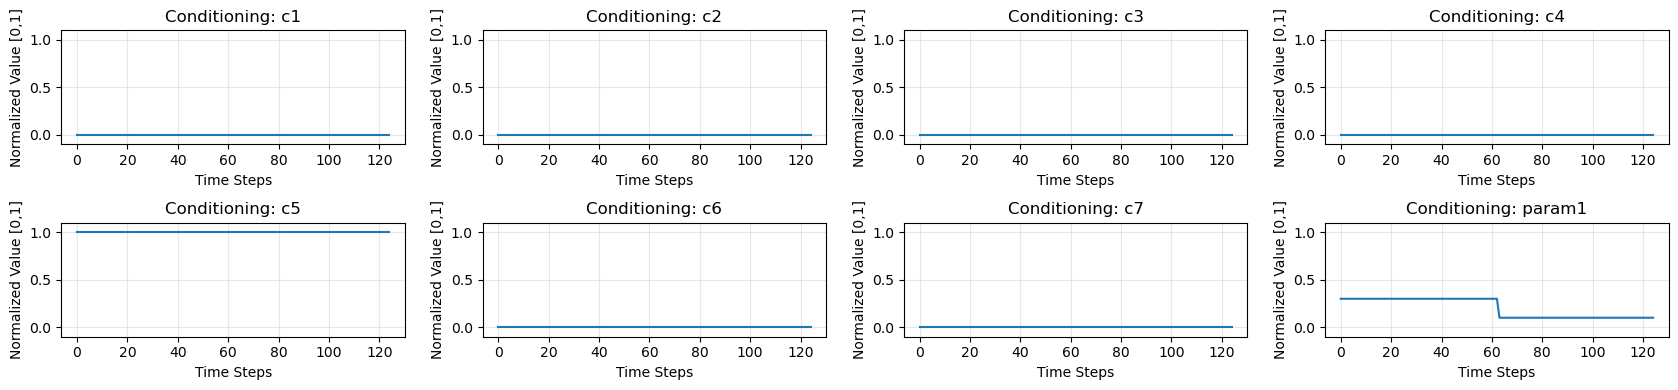

In [8]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
# entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
# ds_idx, start, token_path = entry
# cpath = adataset._cond_path_for(token_path)
# print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)


# # ---- Save Config ----
# #machine readable
# torch.save({
#     "model_config": model_config,
#     "data_config": data_config
# }, f"{out_dir}/config_v1.pt")


# #human readable
# with open(f"{out_dir}/config_v1.txt", "w") as f: 
#     f.write("params = " + repr(params) + "\\n")
#     f.write("model_config = " + repr(model_config) + "\\n")
#     f.write("data_config = " + repr(data_config) + "\\n")

#This can replace the above 2 torch.save calls 
save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to /home/lonce/working/RNeNcodec/notebooks/output/20251025_161452_multiclass_test_HARDcascade/config_v2.pt
wrote json param file
wrote /home/lonce/working/RNeNcodec/notebooks/output/20251025_161452_multiclass_test_HARDcascade/config_v2.pt


In [12]:
import copy
from rnencodec.generator import RNNGenerator

inference_model_config=copy.deepcopy(model_config)
inference_model_config.cascade='hard' # 
inference_model_config.hard_sample_mode="sample"
inference_model_config.top_n_hard=12
inference_model_config.temperature_hard=1.0


def newgen(model,max_length):
    #This hack allows us to "configure" the model for generation differently - in particular how it is sampled (which may be different from how it is trained)
    inference_model = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to('cpu')
    inference_model.load_state_dict(model.state_dict())

    #override these values of state
    inference_model.cascade='hard' # 
    inference_model.hard_sample_mode="sample"
    inference_model.top_n_hard=12
    inference_model.temperature_hard=1.0



    rnninference=RNNGenerator(inference_model, inference_model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -inference_model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
inference_model_config

GRUModelConfig(input_size=128, cond_size=8, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=1, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='hard', hard_sample_mode='sample', top_n_hard=12, temperature_hard=1.0, tau_soft=0.6, top_n_soft=None)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128


In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2416432
latent_proj: 13,674
cond_proj:   198
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,416,432
✅ E_eff is built: n_q=8, K=1024, D=128, device=cuda:0
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


2025-10-25 16:14:52 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2025-10-25 16:15:39.158718, epoch 1,  Loss: 0.2678
  Quantizer 0 Loss: 4.0516
  Quantizer 1 Loss: 4.3135
  Quantizer 2 Loss: 4.6971
  Quantizer 3 Loss: 5.0172
  Quantizer 4 Loss: 5.2090
  Quantizer 5 Loss: 5.3170
  Quantizer 6 Loss: 5.5148
  Quantizer 7 Loss: 5.5821
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


/home/lonce/working/RNeNcodec/rnencodec/generator/generator.py:159: UserWarning: Warning: ....... chunk size 375 is <= hop size 375. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


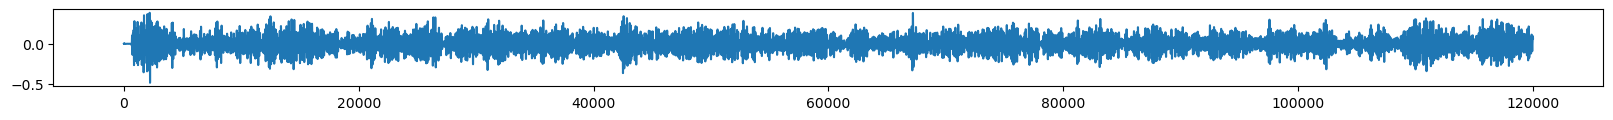

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2025-10-25 16:16:27.924429, epoch 2,  Loss: 0.2514
  Quantizer 0 Loss: 3.0221
  Quantizer 1 Loss: 3.4575
  Quantizer 2 Loss: 3.9910
  Quantizer 3 Loss: 4.3808
  Quantizer 4 Loss: 4.6308
  Quantizer 5 Loss: 4.7853
  Quantizer 6 Loss: 4.9994
  Quantizer 7 Loss: 5.0895
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


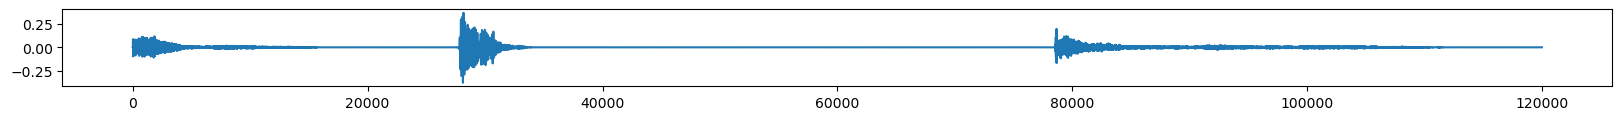

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2025-10-25 16:17:16.634240, epoch 3,  Loss: 0.2445
  Quantizer 0 Loss: 2.7947
  Quantizer 1 Loss: 3.2841
  Quantizer 2 Loss: 3.8581
  Quantizer 3 Loss: 4.2664
  Quantizer 4 Loss: 4.5361
  Quantizer 5 Loss: 4.7010
  Quantizer 6 Loss: 4.9205
  Quantizer 7 Loss: 5.0206
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


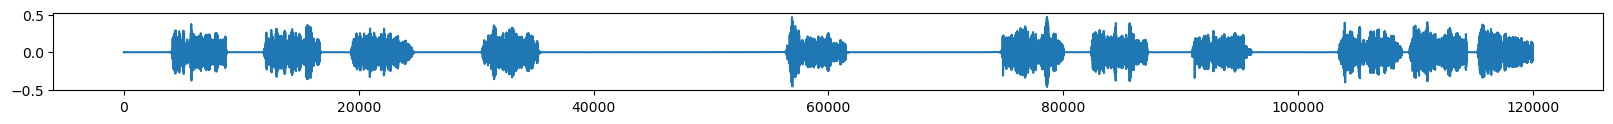

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2025-10-25 16:18:04.963414, epoch 4,  Loss: 0.2374
  Quantizer 0 Loss: 2.6250
  Quantizer 1 Loss: 3.1480
  Quantizer 2 Loss: 3.7556
  Quantizer 3 Loss: 4.1776
  Quantizer 4 Loss: 4.4532
  Quantizer 5 Loss: 4.6211
  Quantizer 6 Loss: 4.8470
  Quantizer 7 Loss: 4.9503
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


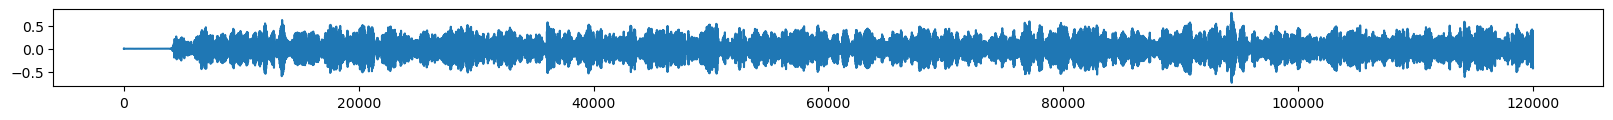

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2025-10-25 16:18:52.815923, epoch 5,  Loss: 0.2418
  Quantizer 0 Loss: 2.5505
  Quantizer 1 Loss: 3.0776
  Quantizer 2 Loss: 3.7091
  Quantizer 3 Loss: 4.1351
  Quantizer 4 Loss: 4.4192
  Quantizer 5 Loss: 4.5868
  Quantizer 6 Loss: 4.8139
  Quantizer 7 Loss: 4.9203
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


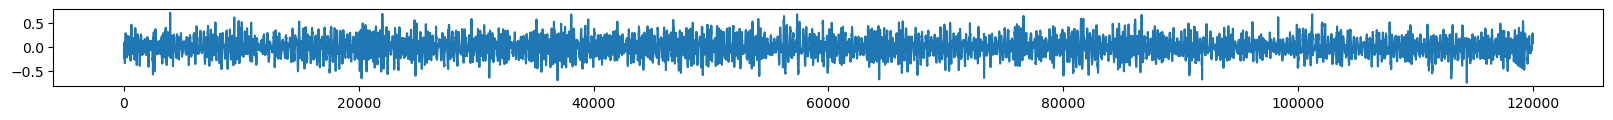

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2025-10-25 16:19:40.381797, epoch 6,  Loss: 0.2363
  Quantizer 0 Loss: 2.4858
  Quantizer 1 Loss: 3.0101
  Quantizer 2 Loss: 3.6483
  Quantizer 3 Loss: 4.0832
  Quantizer 4 Loss: 4.3695
  Quantizer 5 Loss: 4.5462
  Quantizer 6 Loss: 4.7728
  Quantizer 7 Loss: 4.8828
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


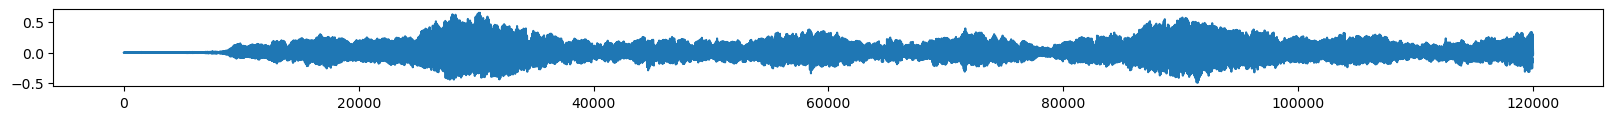

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2025-10-25 16:20:29.200893, epoch 7,  Loss: 0.2337
  Quantizer 0 Loss: 2.4360
  Quantizer 1 Loss: 2.9660
  Quantizer 2 Loss: 3.6147
  Quantizer 3 Loss: 4.0521
  Quantizer 4 Loss: 4.3472
  Quantizer 5 Loss: 4.5244
  Quantizer 6 Loss: 4.7548
  Quantizer 7 Loss: 4.8640
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


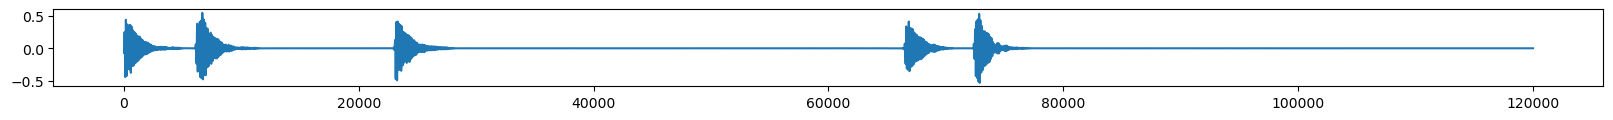

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2025-10-25 16:21:16.947262, epoch 8,  Loss: 0.2283
  Quantizer 0 Loss: 2.4067
  Quantizer 1 Loss: 2.9379
  Quantizer 2 Loss: 3.5996
  Quantizer 3 Loss: 4.0358
  Quantizer 4 Loss: 4.3248
  Quantizer 5 Loss: 4.5040
  Quantizer 6 Loss: 4.7374
  Quantizer 7 Loss: 4.8480
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


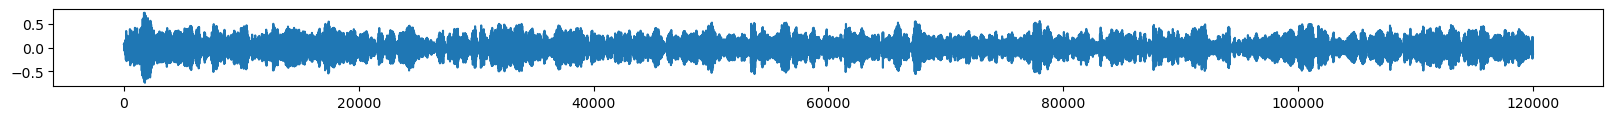

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2025-10-25 16:22:06.007021, epoch 9,  Loss: 0.2244
  Quantizer 0 Loss: 2.3800
  Quantizer 1 Loss: 2.9039
  Quantizer 2 Loss: 3.5532
  Quantizer 3 Loss: 3.9982
  Quantizer 4 Loss: 4.2863
  Quantizer 5 Loss: 4.4719
  Quantizer 6 Loss: 4.6997
  Quantizer 7 Loss: 4.8170
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


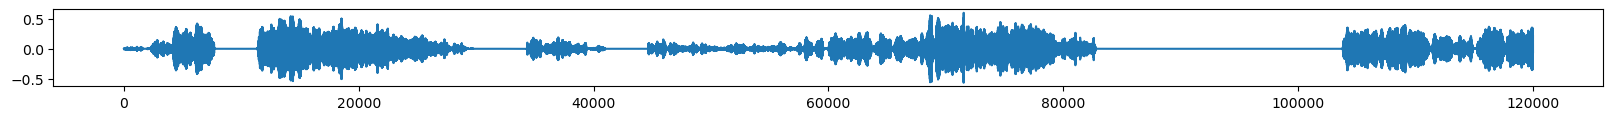

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2025-10-25 16:22:55.267272, epoch 10,  Loss: 0.2350
  Quantizer 0 Loss: 2.3585
  Quantizer 1 Loss: 2.8846
  Quantizer 2 Loss: 3.5390
  Quantizer 3 Loss: 3.9743
  Quantizer 4 Loss: 4.2827
  Quantizer 5 Loss: 4.4666
  Quantizer 6 Loss: 4.6955
  Quantizer 7 Loss: 4.8123
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


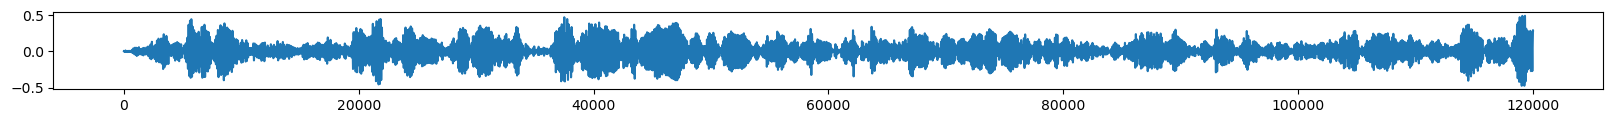

Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2025-10-25 16:23:44.152895, epoch 11,  Loss: 0.2261
  Quantizer 0 Loss: 2.3531
  Quantizer 1 Loss: 2.8741
  Quantizer 2 Loss: 3.5248
  Quantizer 3 Loss: 3.9683
  Quantizer 4 Loss: 4.2657
  Quantizer 5 Loss: 4.4519
  Quantizer 6 Loss: 4.6885
  Quantizer 7 Loss: 4.8031
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


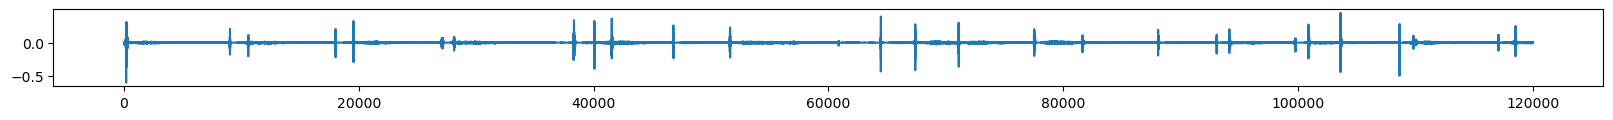

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2025-10-25 16:24:33.834671, epoch 12,  Loss: 0.2345
  Quantizer 0 Loss: 2.3454
  Quantizer 1 Loss: 2.8732
  Quantizer 2 Loss: 3.5308
  Quantizer 3 Loss: 3.9686
  Quantizer 4 Loss: 4.2705
  Quantizer 5 Loss: 4.4633
  Quantizer 6 Loss: 4.6964
  Quantizer 7 Loss: 4.8135
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


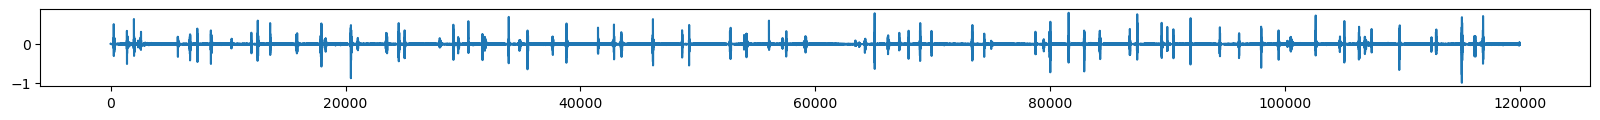

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2025-10-25 16:25:23.325088, epoch 13,  Loss: 0.2335
  Quantizer 0 Loss: 2.3403
  Quantizer 1 Loss: 2.8633
  Quantizer 2 Loss: 3.5158
  Quantizer 3 Loss: 3.9641
  Quantizer 4 Loss: 4.2657
  Quantizer 5 Loss: 4.4542
  Quantizer 6 Loss: 4.6901
  Quantizer 7 Loss: 4.8102
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


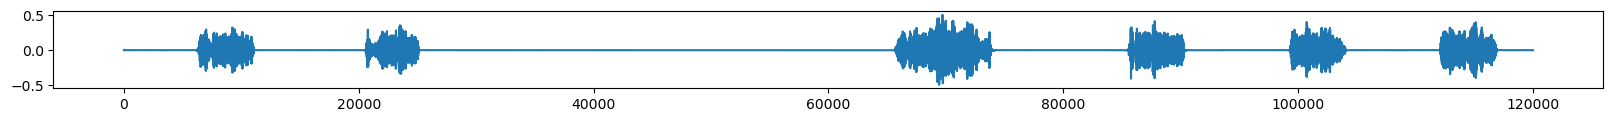

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2025-10-25 16:26:12.556615, epoch 14,  Loss: 0.2244
  Quantizer 0 Loss: 2.3153
  Quantizer 1 Loss: 2.8327
  Quantizer 2 Loss: 3.4961
  Quantizer 3 Loss: 3.9389
  Quantizer 4 Loss: 4.2426
  Quantizer 5 Loss: 4.4304
  Quantizer 6 Loss: 4.6638
  Quantizer 7 Loss: 4.7876
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


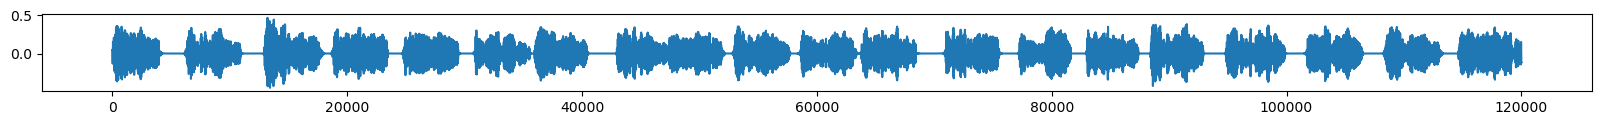

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2025-10-25 16:27:02.168358, epoch 15,  Loss: 0.2263
  Quantizer 0 Loss: 2.3166
  Quantizer 1 Loss: 2.8345
  Quantizer 2 Loss: 3.4927
  Quantizer 3 Loss: 3.9337
  Quantizer 4 Loss: 4.2402
  Quantizer 5 Loss: 4.4273
  Quantizer 6 Loss: 4.6640
  Quantizer 7 Loss: 4.7844
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


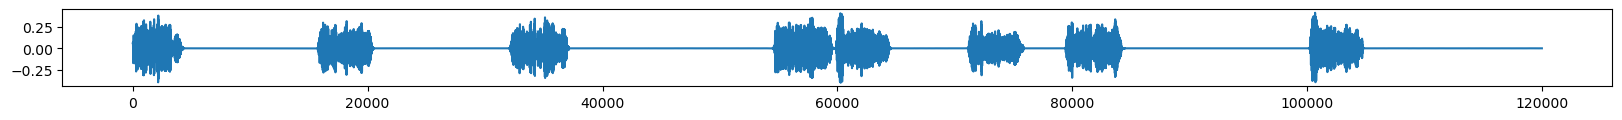

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2025-10-25 16:27:52.061870, epoch 16,  Loss: 0.2215
  Quantizer 0 Loss: 2.3111
  Quantizer 1 Loss: 2.8191
  Quantizer 2 Loss: 3.4812
  Quantizer 3 Loss: 3.9261
  Quantizer 4 Loss: 4.2303
  Quantizer 5 Loss: 4.4231
  Quantizer 6 Loss: 4.6607
  Quantizer 7 Loss: 4.7762
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


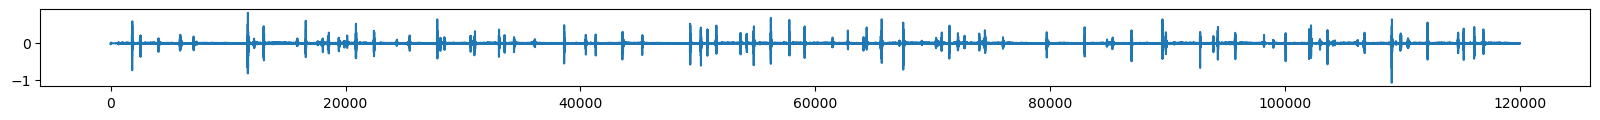

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2025-10-25 16:28:41.596464, epoch 17,  Loss: 0.2230
  Quantizer 0 Loss: 2.2931
  Quantizer 1 Loss: 2.8062
  Quantizer 2 Loss: 3.4621
  Quantizer 3 Loss: 3.9109
  Quantizer 4 Loss: 4.2137
  Quantizer 5 Loss: 4.4076
  Quantizer 6 Loss: 4.6452
  Quantizer 7 Loss: 4.7628
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


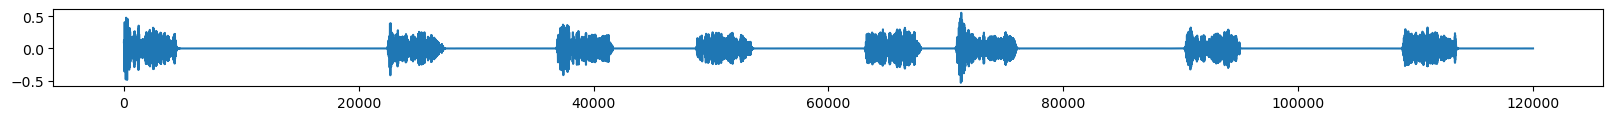

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2025-10-25 16:29:29.948865, epoch 18,  Loss: 0.2255
  Quantizer 0 Loss: 2.2942
  Quantizer 1 Loss: 2.8115
  Quantizer 2 Loss: 3.4594
  Quantizer 3 Loss: 3.9085
  Quantizer 4 Loss: 4.2053
  Quantizer 5 Loss: 4.4007
  Quantizer 6 Loss: 4.6350
  Quantizer 7 Loss: 4.7568
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


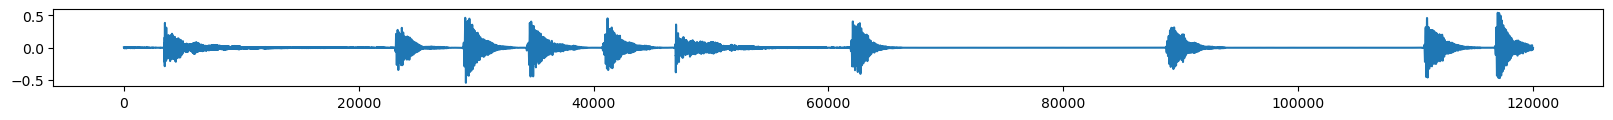

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2025-10-25 16:30:18.886462, epoch 19,  Loss: 0.2202
  Quantizer 0 Loss: 2.2705
  Quantizer 1 Loss: 2.7795
  Quantizer 2 Loss: 3.4371
  Quantizer 3 Loss: 3.8872
  Quantizer 4 Loss: 4.1902
  Quantizer 5 Loss: 4.3832
  Quantizer 6 Loss: 4.6234
  Quantizer 7 Loss: 4.7478
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


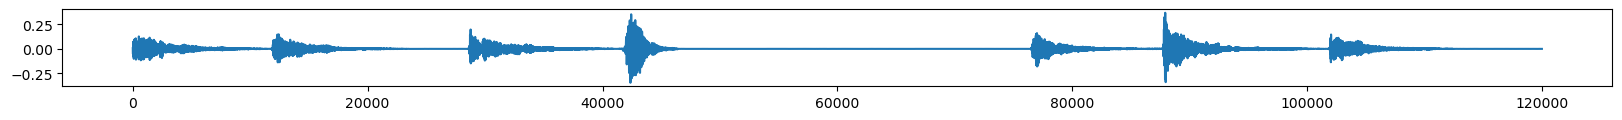

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2025-10-25 16:31:08.766764, epoch 20,  Loss: 0.2210
  Quantizer 0 Loss: 2.2715
  Quantizer 1 Loss: 2.7798
  Quantizer 2 Loss: 3.4325
  Quantizer 3 Loss: 3.8791
  Quantizer 4 Loss: 4.1872
  Quantizer 5 Loss: 4.3820
  Quantizer 6 Loss: 4.6199
  Quantizer 7 Loss: 4.7444
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


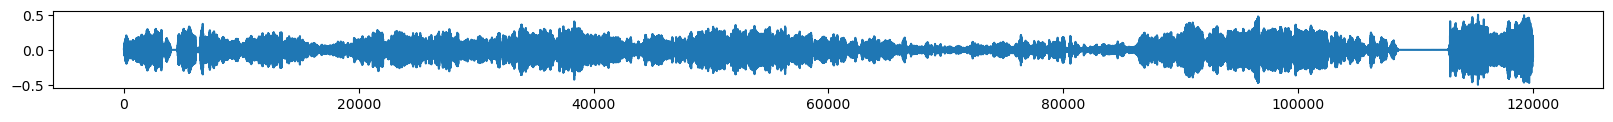

Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2025-10-25 16:31:58.568637, epoch 21,  Loss: 0.2169
  Quantizer 0 Loss: 2.2781
  Quantizer 1 Loss: 2.7896
  Quantizer 2 Loss: 3.4397
  Quantizer 3 Loss: 3.8858
  Quantizer 4 Loss: 4.1897
  Quantizer 5 Loss: 4.3835
  Quantizer 6 Loss: 4.6236
  Quantizer 7 Loss: 4.7439
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


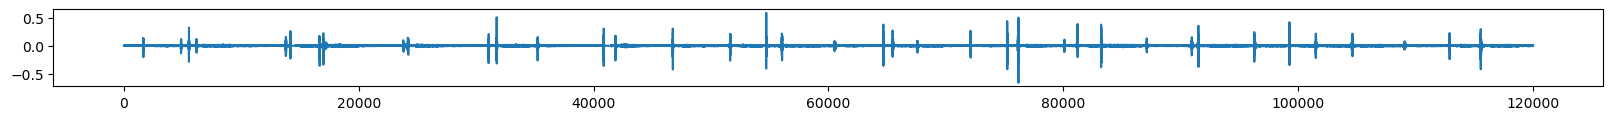

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2025-10-25 16:32:49.258600, epoch 22,  Loss: 0.2209
  Quantizer 0 Loss: 2.2563
  Quantizer 1 Loss: 2.7713
  Quantizer 2 Loss: 3.4231
  Quantizer 3 Loss: 3.8642
  Quantizer 4 Loss: 4.1732
  Quantizer 5 Loss: 4.3677
  Quantizer 6 Loss: 4.6079
  Quantizer 7 Loss: 4.7385
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


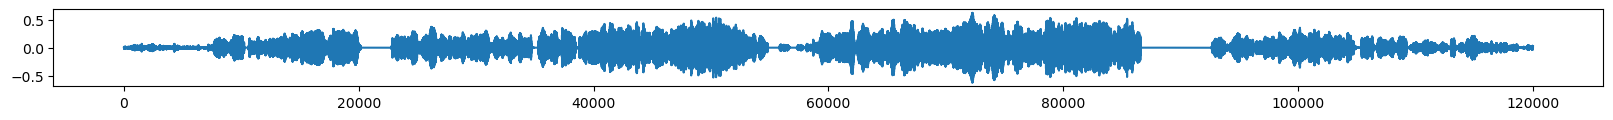

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2025-10-25 16:33:38.979371, epoch 23,  Loss: 0.2224
  Quantizer 0 Loss: 2.2692
  Quantizer 1 Loss: 2.7740
  Quantizer 2 Loss: 3.4318
  Quantizer 3 Loss: 3.8761
  Quantizer 4 Loss: 4.1800
  Quantizer 5 Loss: 4.3774
  Quantizer 6 Loss: 4.6139
  Quantizer 7 Loss: 4.7346
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


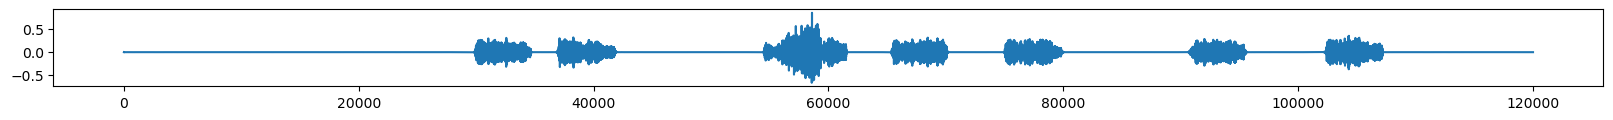

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2025-10-25 16:34:28.389089, epoch 24,  Loss: 0.2222
  Quantizer 0 Loss: 2.2563
  Quantizer 1 Loss: 2.7644
  Quantizer 2 Loss: 3.4146
  Quantizer 3 Loss: 3.8643
  Quantizer 4 Loss: 4.1775
  Quantizer 5 Loss: 4.3706
  Quantizer 6 Loss: 4.6080
  Quantizer 7 Loss: 4.7400
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


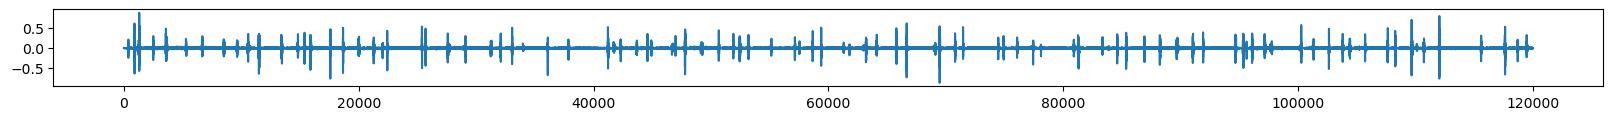

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2025-10-25 16:35:17.504583, epoch 25,  Loss: 0.2207
  Quantizer 0 Loss: 2.2715
  Quantizer 1 Loss: 2.7810
  Quantizer 2 Loss: 3.4369
  Quantizer 3 Loss: 3.8805
  Quantizer 4 Loss: 4.1896
  Quantizer 5 Loss: 4.3856
  Quantizer 6 Loss: 4.6277
  Quantizer 7 Loss: 4.7467
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


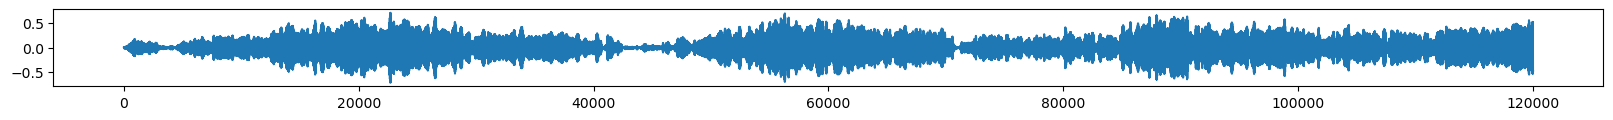

Saved checkpoint at epoch 25
Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2025-10-25 16:36:08.453980, epoch 26,  Loss: 0.2468
  Quantizer 0 Loss: 2.2770
  Quantizer 1 Loss: 3.3915
  Quantizer 2 Loss: 4.1948
  Quantizer 3 Loss: 4.6850
  Quantizer 4 Loss: 4.9874
  Quantizer 5 Loss: 5.1736
  Quantizer 6 Loss: 5.3848
  Quantizer 7 Loss: 5.4664
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


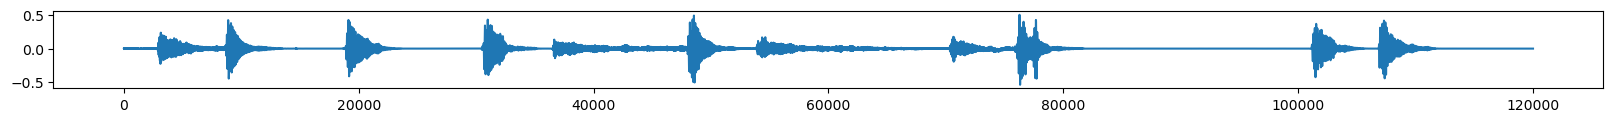

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2025-10-25 16:36:59.656690, epoch 27,  Loss: 0.2551
  Quantizer 0 Loss: 2.2669
  Quantizer 1 Loss: 3.2702
  Quantizer 2 Loss: 4.0413
  Quantizer 3 Loss: 4.5251
  Quantizer 4 Loss: 4.8406
  Quantizer 5 Loss: 5.0351
  Quantizer 6 Loss: 5.2661
  Quantizer 7 Loss: 5.3635
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


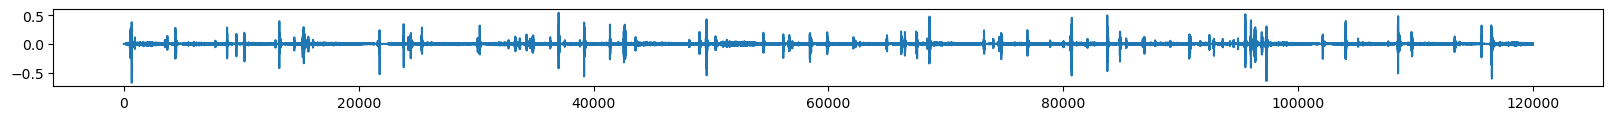

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2025-10-25 16:37:50.046577, epoch 28,  Loss: 0.2431
  Quantizer 0 Loss: 2.2588
  Quantizer 1 Loss: 3.2304
  Quantizer 2 Loss: 3.9888
  Quantizer 3 Loss: 4.4707
  Quantizer 4 Loss: 4.7804
  Quantizer 5 Loss: 4.9726
  Quantizer 6 Loss: 5.2066
  Quantizer 7 Loss: 5.3033
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


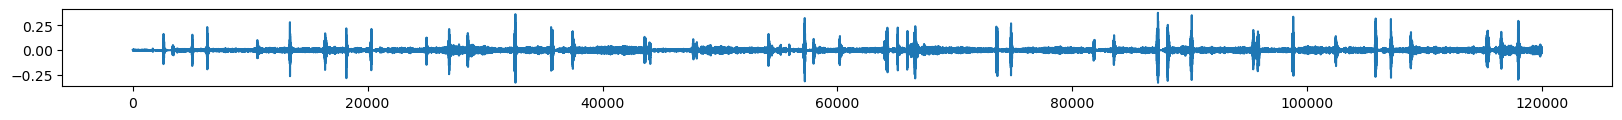

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2025-10-25 16:38:40.547124, epoch 29,  Loss: 0.2439
  Quantizer 0 Loss: 2.2526
  Quantizer 1 Loss: 3.2213
  Quantizer 2 Loss: 3.9770
  Quantizer 3 Loss: 4.4496
  Quantizer 4 Loss: 4.7545
  Quantizer 5 Loss: 4.9451
  Quantizer 6 Loss: 5.1798
  Quantizer 7 Loss: 5.2834
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


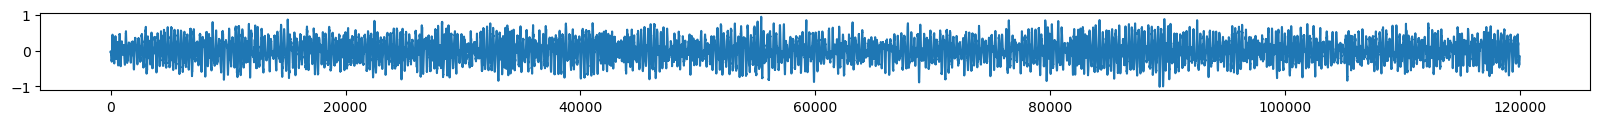

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2025-10-25 16:39:31.626455, epoch 30,  Loss: 0.2488
  Quantizer 0 Loss: 2.2347
  Quantizer 1 Loss: 3.1926
  Quantizer 2 Loss: 3.9461
  Quantizer 3 Loss: 4.4196
  Quantizer 4 Loss: 4.7268
  Quantizer 5 Loss: 4.9184
  Quantizer 6 Loss: 5.1474
  Quantizer 7 Loss: 5.2557
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


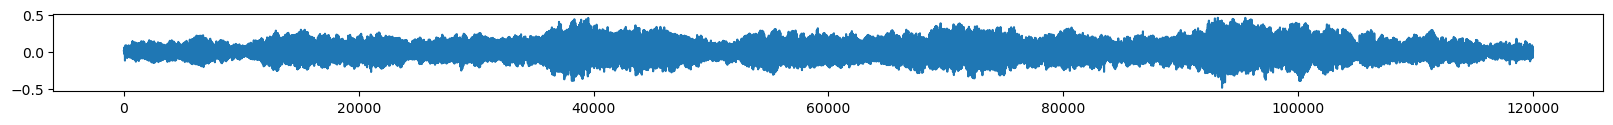

Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2025-10-25 16:40:23.281253, epoch 31,  Loss: 0.2455
  Quantizer 0 Loss: 2.2463
  Quantizer 1 Loss: 3.1990
  Quantizer 2 Loss: 3.9466
  Quantizer 3 Loss: 4.4170
  Quantizer 4 Loss: 4.7185
  Quantizer 5 Loss: 4.9127
  Quantizer 6 Loss: 5.1399
  Quantizer 7 Loss: 5.2427
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


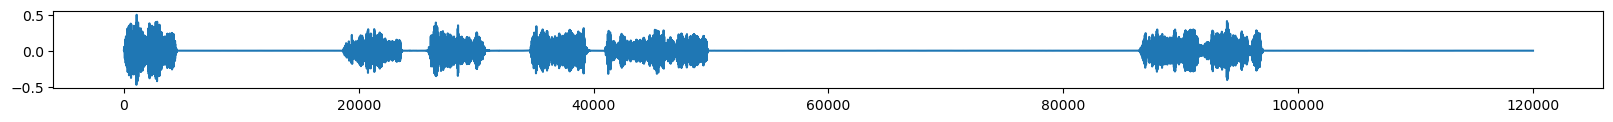

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2025-10-25 16:41:14.055846, epoch 32,  Loss: 0.2416
  Quantizer 0 Loss: 2.2382
  Quantizer 1 Loss: 3.1971
  Quantizer 2 Loss: 3.9463
  Quantizer 3 Loss: 4.4160
  Quantizer 4 Loss: 4.7209
  Quantizer 5 Loss: 4.9088
  Quantizer 6 Loss: 5.1426
  Quantizer 7 Loss: 5.2444
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


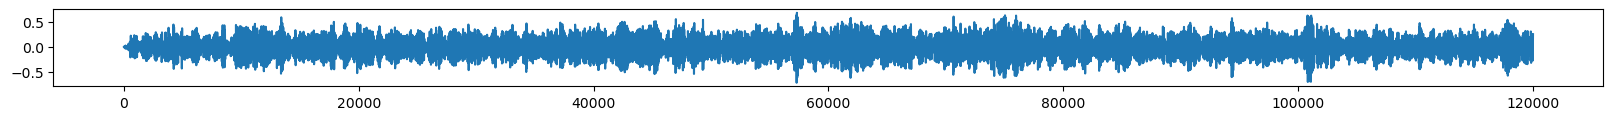

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2025-10-25 16:42:04.128992, epoch 33,  Loss: 0.2441
  Quantizer 0 Loss: 2.2481
  Quantizer 1 Loss: 3.2015
  Quantizer 2 Loss: 3.9524
  Quantizer 3 Loss: 4.4152
  Quantizer 4 Loss: 4.7185
  Quantizer 5 Loss: 4.9023
  Quantizer 6 Loss: 5.1296
  Quantizer 7 Loss: 5.2299
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


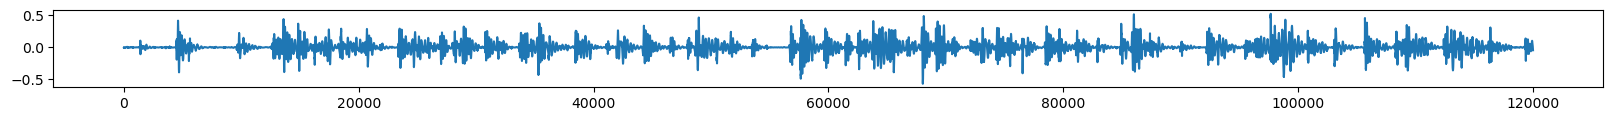

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2025-10-25 16:42:53.742255, epoch 34,  Loss: 0.2427
  Quantizer 0 Loss: 2.2342
  Quantizer 1 Loss: 3.1871
  Quantizer 2 Loss: 3.9386
  Quantizer 3 Loss: 4.4003
  Quantizer 4 Loss: 4.7043
  Quantizer 5 Loss: 4.8945
  Quantizer 6 Loss: 5.1169
  Quantizer 7 Loss: 5.2194
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


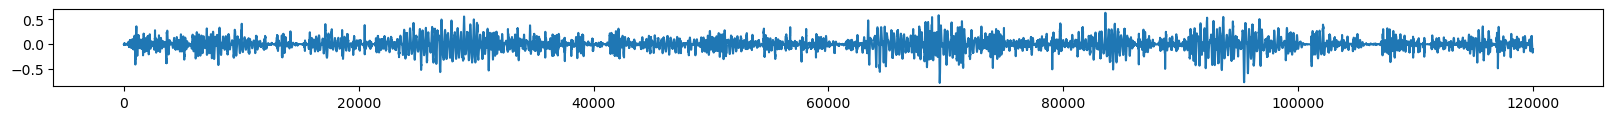

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2025-10-25 16:43:43.928448, epoch 35,  Loss: 0.2544
  Quantizer 0 Loss: 2.2441
  Quantizer 1 Loss: 3.1885
  Quantizer 2 Loss: 3.9354
  Quantizer 3 Loss: 4.4038
  Quantizer 4 Loss: 4.7113
  Quantizer 5 Loss: 4.8969
  Quantizer 6 Loss: 5.1243
  Quantizer 7 Loss: 5.2280
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


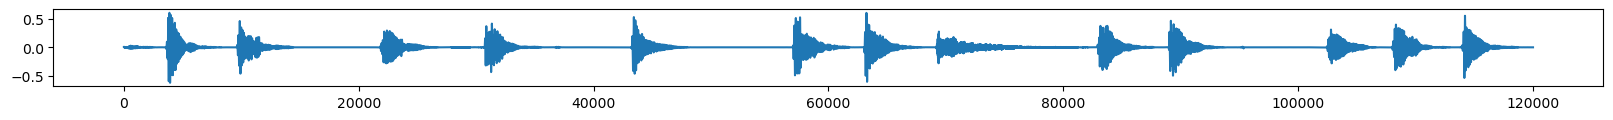

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2025-10-25 16:44:32.897398, epoch 36,  Loss: 0.2466
  Quantizer 0 Loss: 2.2310
  Quantizer 1 Loss: 3.1718
  Quantizer 2 Loss: 3.9291
  Quantizer 3 Loss: 4.3971
  Quantizer 4 Loss: 4.7006
  Quantizer 5 Loss: 4.8888
  Quantizer 6 Loss: 5.1178
  Quantizer 7 Loss: 5.2137
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


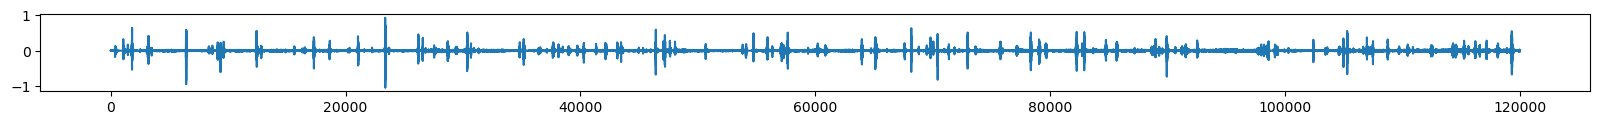

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2025-10-25 16:45:22.344905, epoch 37,  Loss: 0.2497
  Quantizer 0 Loss: 2.2152
  Quantizer 1 Loss: 3.1502
  Quantizer 2 Loss: 3.9043
  Quantizer 3 Loss: 4.3696
  Quantizer 4 Loss: 4.6796
  Quantizer 5 Loss: 4.8656
  Quantizer 6 Loss: 5.0943
  Quantizer 7 Loss: 5.1955
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


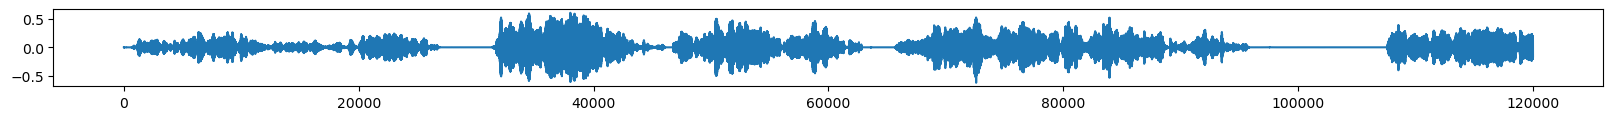

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2025-10-25 16:46:12.849045, epoch 38,  Loss: 0.2473
  Quantizer 0 Loss: 2.2239
  Quantizer 1 Loss: 3.1680
  Quantizer 2 Loss: 3.9148
  Quantizer 3 Loss: 4.3858
  Quantizer 4 Loss: 4.6904
  Quantizer 5 Loss: 4.8762
  Quantizer 6 Loss: 5.1082
  Quantizer 7 Loss: 5.2070
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


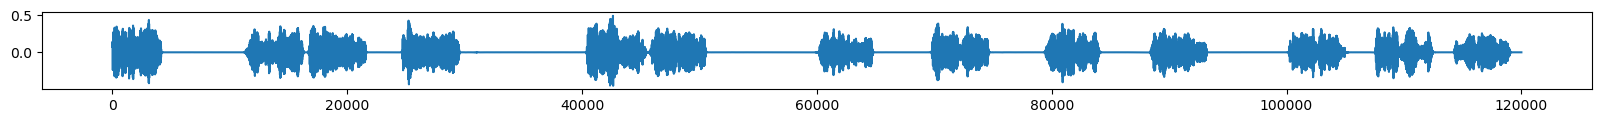

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2025-10-25 16:47:03.451089, epoch 39,  Loss: 0.2513
  Quantizer 0 Loss: 2.2193
  Quantizer 1 Loss: 3.1573
  Quantizer 2 Loss: 3.9051
  Quantizer 3 Loss: 4.3739
  Quantizer 4 Loss: 4.6793
  Quantizer 5 Loss: 4.8657
  Quantizer 6 Loss: 5.0944
  Quantizer 7 Loss: 5.1928
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


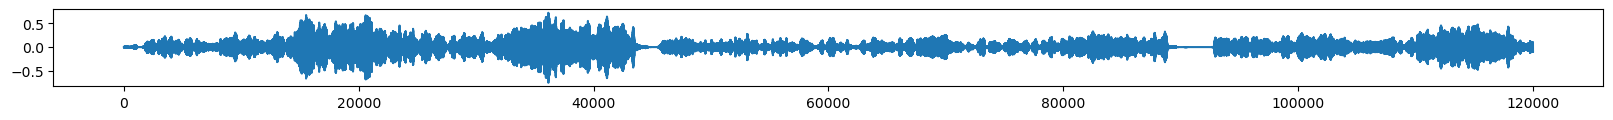

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2025-10-25 16:47:53.620154, epoch 40,  Loss: 0.2515
  Quantizer 0 Loss: 2.2202
  Quantizer 1 Loss: 3.1602
  Quantizer 2 Loss: 3.9126
  Quantizer 3 Loss: 4.3780
  Quantizer 4 Loss: 4.6796
  Quantizer 5 Loss: 4.8719
  Quantizer 6 Loss: 5.1010
  Quantizer 7 Loss: 5.2007
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


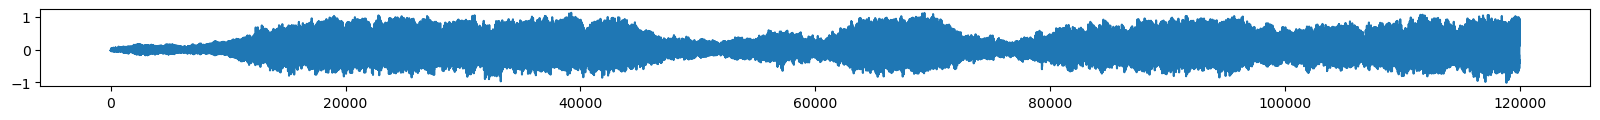

Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2025-10-25 16:48:43.496440, epoch 41,  Loss: 0.2411
  Quantizer 0 Loss: 2.2033
  Quantizer 1 Loss: 3.1445
  Quantizer 2 Loss: 3.8927
  Quantizer 3 Loss: 4.3640
  Quantizer 4 Loss: 4.6737
  Quantizer 5 Loss: 4.8581
  Quantizer 6 Loss: 5.0867
  Quantizer 7 Loss: 5.1893
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


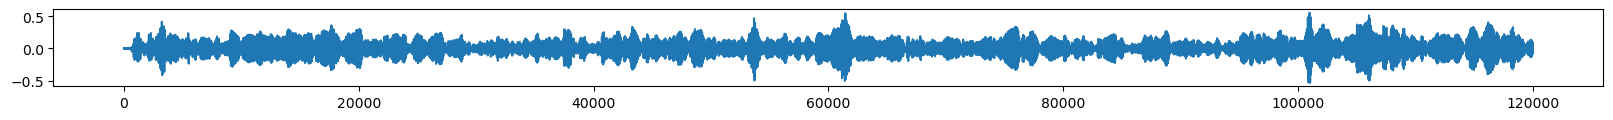

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2025-10-25 16:49:32.880898, epoch 42,  Loss: 0.2404
  Quantizer 0 Loss: 2.2138
  Quantizer 1 Loss: 3.1510
  Quantizer 2 Loss: 3.9009
  Quantizer 3 Loss: 4.3649
  Quantizer 4 Loss: 4.6765
  Quantizer 5 Loss: 4.8627
  Quantizer 6 Loss: 5.0917
  Quantizer 7 Loss: 5.1912
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


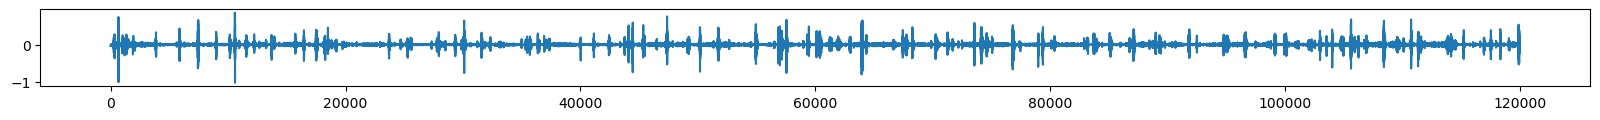

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2025-10-25 16:50:22.594084, epoch 43,  Loss: 0.2422
  Quantizer 0 Loss: 2.2198
  Quantizer 1 Loss: 3.1587
  Quantizer 2 Loss: 3.9153
  Quantizer 3 Loss: 4.3769
  Quantizer 4 Loss: 4.6807
  Quantizer 5 Loss: 4.8704
  Quantizer 6 Loss: 5.0991
  Quantizer 7 Loss: 5.2002
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


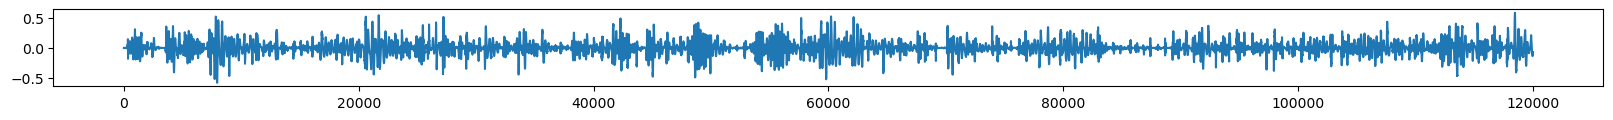

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2025-10-25 16:51:12.712538, epoch 44,  Loss: 0.2467
  Quantizer 0 Loss: 2.2150
  Quantizer 1 Loss: 3.1526
  Quantizer 2 Loss: 3.9059
  Quantizer 3 Loss: 4.3762
  Quantizer 4 Loss: 4.6783
  Quantizer 5 Loss: 4.8714
  Quantizer 6 Loss: 5.0951
  Quantizer 7 Loss: 5.1947
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


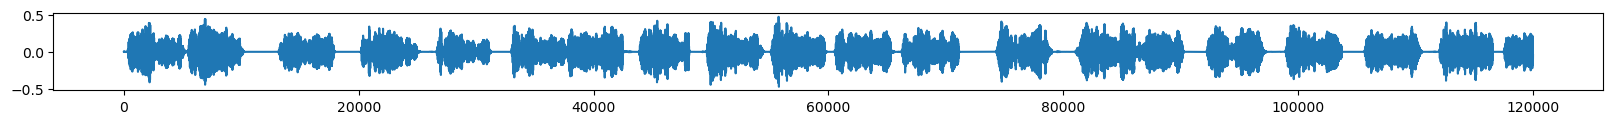

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2025-10-25 16:52:03.932706, epoch 45,  Loss: 0.2521
  Quantizer 0 Loss: 2.2066
  Quantizer 1 Loss: 3.1462
  Quantizer 2 Loss: 3.8952
  Quantizer 3 Loss: 4.3613
  Quantizer 4 Loss: 4.6687
  Quantizer 5 Loss: 4.8579
  Quantizer 6 Loss: 5.0893
  Quantizer 7 Loss: 5.1884
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


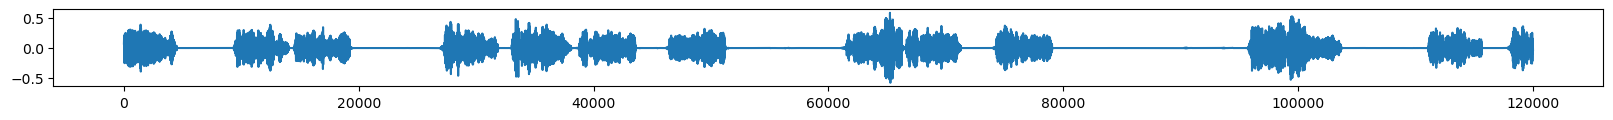

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2025-10-25 16:52:53.674942, epoch 46,  Loss: 0.2485
  Quantizer 0 Loss: 2.2067
  Quantizer 1 Loss: 3.1429
  Quantizer 2 Loss: 3.8913
  Quantizer 3 Loss: 4.3606
  Quantizer 4 Loss: 4.6668
  Quantizer 5 Loss: 4.8544
  Quantizer 6 Loss: 5.0897
  Quantizer 7 Loss: 5.1854
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


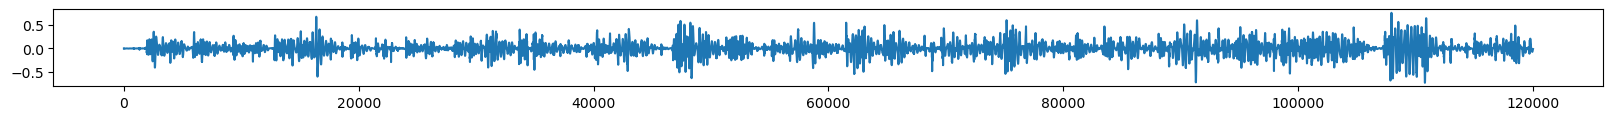

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2025-10-25 16:53:44.574956, epoch 47,  Loss: 0.2402
  Quantizer 0 Loss: 2.2119
  Quantizer 1 Loss: 3.1546
  Quantizer 2 Loss: 3.9075
  Quantizer 3 Loss: 4.3811
  Quantizer 4 Loss: 4.6882
  Quantizer 5 Loss: 4.8776
  Quantizer 6 Loss: 5.1056
  Quantizer 7 Loss: 5.2083
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


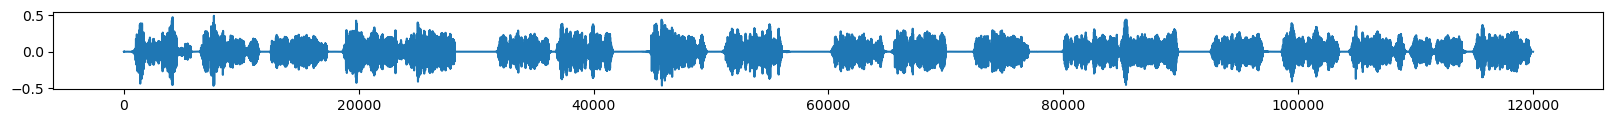

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2025-10-25 16:54:35.714300, epoch 48,  Loss: 0.2528
  Quantizer 0 Loss: 2.2139
  Quantizer 1 Loss: 3.1612
  Quantizer 2 Loss: 3.9003
  Quantizer 3 Loss: 4.3695
  Quantizer 4 Loss: 4.6691
  Quantizer 5 Loss: 4.8620
  Quantizer 6 Loss: 5.0945
  Quantizer 7 Loss: 5.1941
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


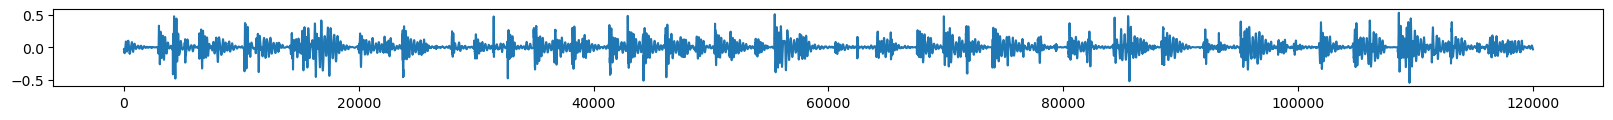

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2025-10-25 16:55:27.179911, epoch 49,  Loss: 0.2431
  Quantizer 0 Loss: 2.1932
  Quantizer 1 Loss: 3.1286
  Quantizer 2 Loss: 3.8815
  Quantizer 3 Loss: 4.3573
  Quantizer 4 Loss: 4.6662
  Quantizer 5 Loss: 4.8524
  Quantizer 6 Loss: 5.0802
  Quantizer 7 Loss: 5.1830
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


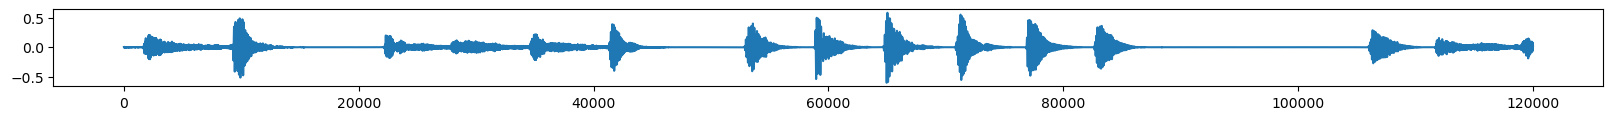

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2025-10-25 16:56:18.147243, epoch 50,  Loss: 0.2524
  Quantizer 0 Loss: 2.2000
  Quantizer 1 Loss: 3.1354
  Quantizer 2 Loss: 3.8889
  Quantizer 3 Loss: 4.3613
  Quantizer 4 Loss: 4.6722
  Quantizer 5 Loss: 4.8620
  Quantizer 6 Loss: 5.0912
  Quantizer 7 Loss: 5.1898
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


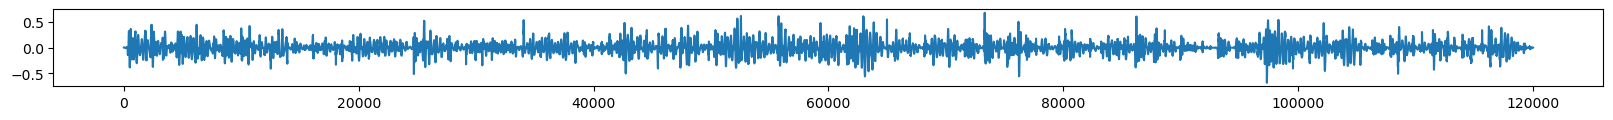

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2025-10-25 16:57:08.319334, epoch 51,  Loss: 0.2268
  Quantizer 0 Loss: 2.2035
  Quantizer 1 Loss: 2.8397
  Quantizer 2 Loss: 3.5662
  Quantizer 3 Loss: 4.0539
  Quantizer 4 Loss: 4.3931
  Quantizer 5 Loss: 4.5986
  Quantizer 6 Loss: 4.8478
  Quantizer 7 Loss: 4.9693
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


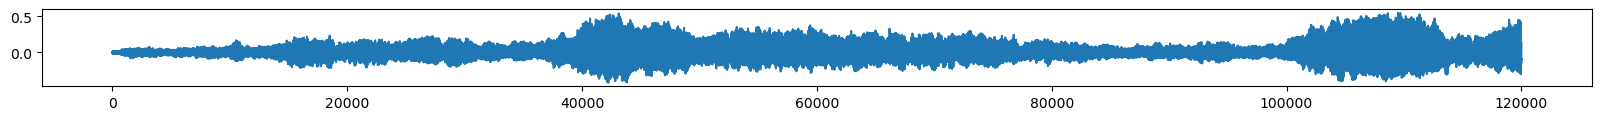

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2025-10-25 16:57:58.819847, epoch 52,  Loss: 0.2167
  Quantizer 0 Loss: 2.1970
  Quantizer 1 Loss: 2.7647
  Quantizer 2 Loss: 3.4489
  Quantizer 3 Loss: 3.9236
  Quantizer 4 Loss: 4.2501
  Quantizer 5 Loss: 4.4598
  Quantizer 6 Loss: 4.7056
  Quantizer 7 Loss: 4.8345
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


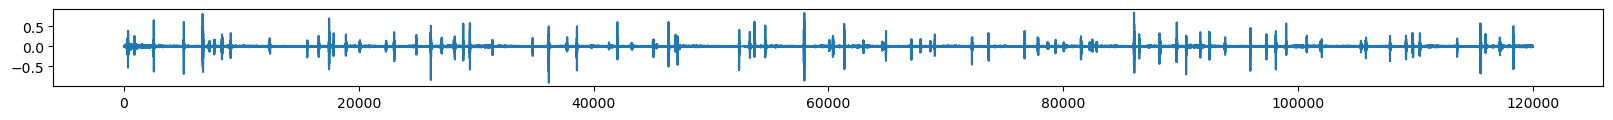

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2025-10-25 16:58:50.102455, epoch 53,  Loss: 0.2319
  Quantizer 0 Loss: 2.2150
  Quantizer 1 Loss: 2.7623
  Quantizer 2 Loss: 3.4352
  Quantizer 3 Loss: 3.9014
  Quantizer 4 Loss: 4.2171
  Quantizer 5 Loss: 4.4252
  Quantizer 6 Loss: 4.6741
  Quantizer 7 Loss: 4.7978
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


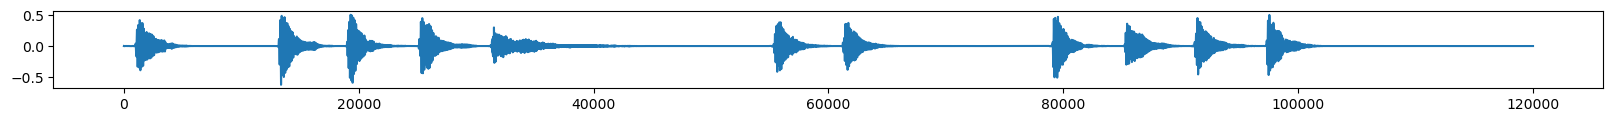

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2025-10-25 16:59:40.959233, epoch 54,  Loss: 0.2209
  Quantizer 0 Loss: 2.2029
  Quantizer 1 Loss: 2.7462
  Quantizer 2 Loss: 3.4170
  Quantizer 3 Loss: 3.8719
  Quantizer 4 Loss: 4.1959
  Quantizer 5 Loss: 4.4033
  Quantizer 6 Loss: 4.6434
  Quantizer 7 Loss: 4.7764
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


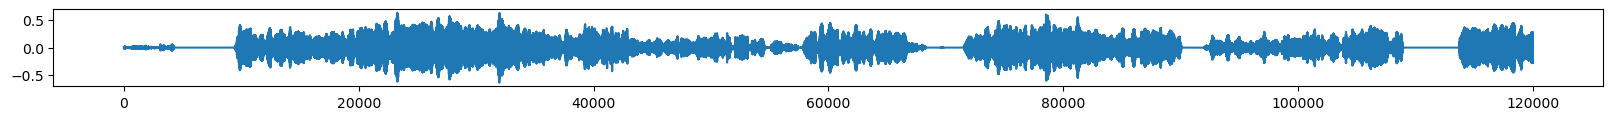

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2025-10-25 17:00:31.992163, epoch 55,  Loss: 0.2200
  Quantizer 0 Loss: 2.1891
  Quantizer 1 Loss: 2.7279
  Quantizer 2 Loss: 3.3901
  Quantizer 3 Loss: 3.8454
  Quantizer 4 Loss: 4.1685
  Quantizer 5 Loss: 4.3659
  Quantizer 6 Loss: 4.6182
  Quantizer 7 Loss: 4.7452
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


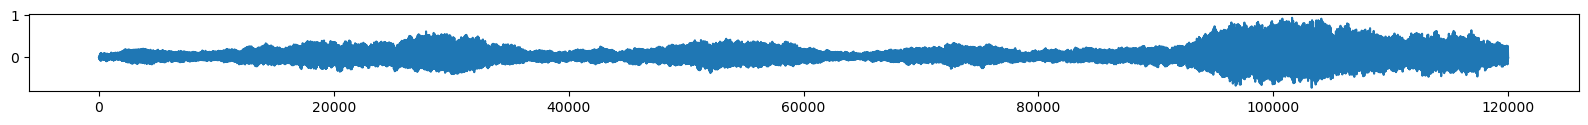

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2025-10-25 17:01:23.704270, epoch 56,  Loss: 0.2168
  Quantizer 0 Loss: 2.2140
  Quantizer 1 Loss: 2.7339
  Quantizer 2 Loss: 3.3972
  Quantizer 3 Loss: 3.8536
  Quantizer 4 Loss: 4.1709
  Quantizer 5 Loss: 4.3711
  Quantizer 6 Loss: 4.6126
  Quantizer 7 Loss: 4.7438
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


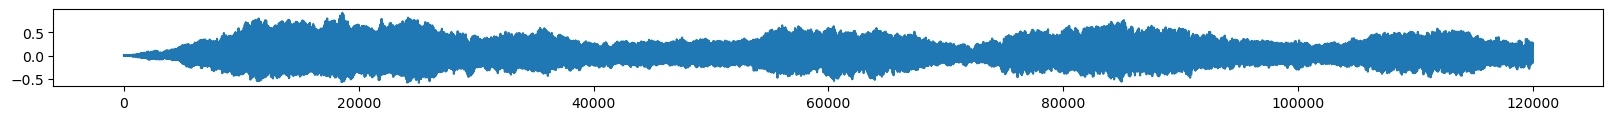

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2025-10-25 17:02:14.742629, epoch 57,  Loss: 0.2212
  Quantizer 0 Loss: 2.2075
  Quantizer 1 Loss: 2.7369
  Quantizer 2 Loss: 3.4017
  Quantizer 3 Loss: 3.8537
  Quantizer 4 Loss: 4.1674
  Quantizer 5 Loss: 4.3669
  Quantizer 6 Loss: 4.6079
  Quantizer 7 Loss: 4.7425
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


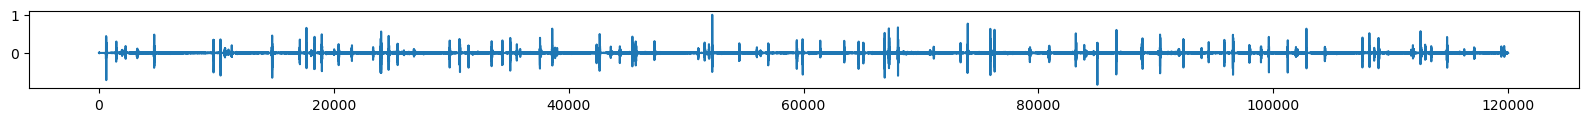

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2025-10-25 17:03:03.760384, epoch 58,  Loss: 0.2243
  Quantizer 0 Loss: 2.1975
  Quantizer 1 Loss: 2.7200
  Quantizer 2 Loss: 3.3821
  Quantizer 3 Loss: 3.8367
  Quantizer 4 Loss: 4.1506
  Quantizer 5 Loss: 4.3536
  Quantizer 6 Loss: 4.6010
  Quantizer 7 Loss: 4.7281
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


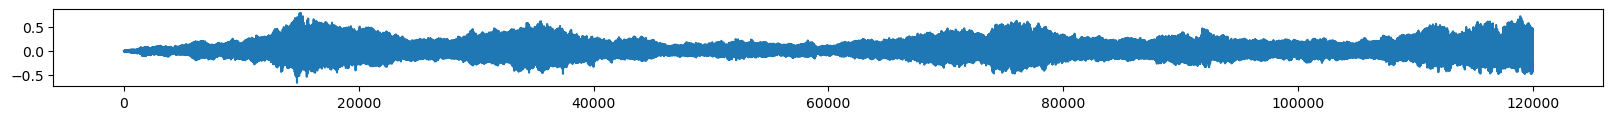

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2025-10-25 17:03:52.916434, epoch 59,  Loss: 0.2137
  Quantizer 0 Loss: 2.2151
  Quantizer 1 Loss: 2.7386
  Quantizer 2 Loss: 3.3977
  Quantizer 3 Loss: 3.8448
  Quantizer 4 Loss: 4.1624
  Quantizer 5 Loss: 4.3618
  Quantizer 6 Loss: 4.6107
  Quantizer 7 Loss: 4.7400
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


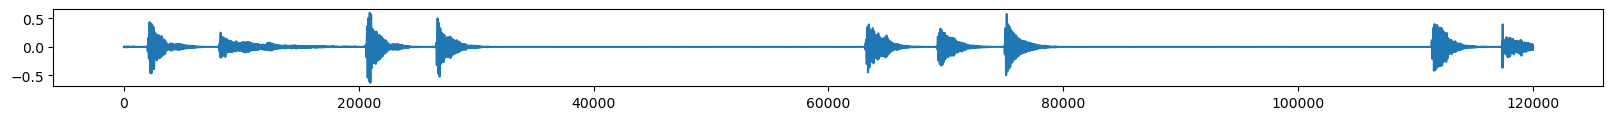

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2025-10-25 17:04:42.961456, epoch 60,  Loss: 0.2213
  Quantizer 0 Loss: 2.2000
  Quantizer 1 Loss: 2.7183
  Quantizer 2 Loss: 3.3669
  Quantizer 3 Loss: 3.8260
  Quantizer 4 Loss: 4.1416
  Quantizer 5 Loss: 4.3432
  Quantizer 6 Loss: 4.5886
  Quantizer 7 Loss: 4.7151
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


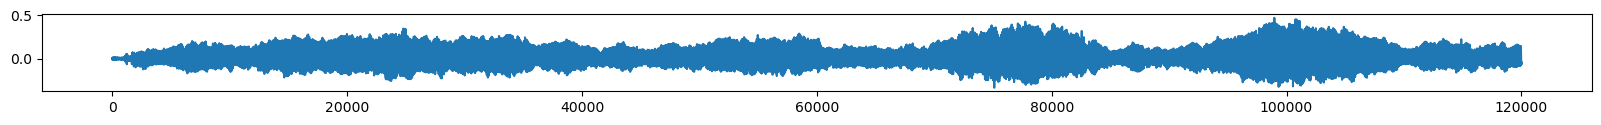

Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2025-10-25 17:05:34.282042, epoch 61,  Loss: 0.2222
  Quantizer 0 Loss: 2.2053
  Quantizer 1 Loss: 2.7294
  Quantizer 2 Loss: 3.3808
  Quantizer 3 Loss: 3.8321
  Quantizer 4 Loss: 4.1446
  Quantizer 5 Loss: 4.3464
  Quantizer 6 Loss: 4.5931
  Quantizer 7 Loss: 4.7219
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


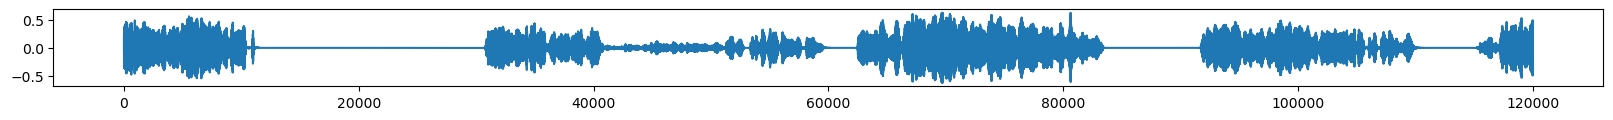

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2025-10-25 17:06:24.586465, epoch 62,  Loss: 0.2255
  Quantizer 0 Loss: 2.2023
  Quantizer 1 Loss: 2.7157
  Quantizer 2 Loss: 3.3678
  Quantizer 3 Loss: 3.8150
  Quantizer 4 Loss: 4.1329
  Quantizer 5 Loss: 4.3303
  Quantizer 6 Loss: 4.5734
  Quantizer 7 Loss: 4.6986
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


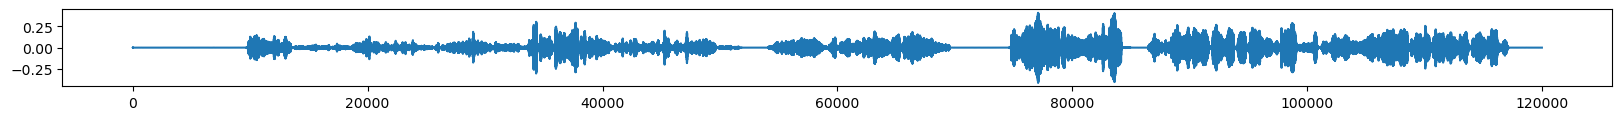

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2025-10-25 17:07:14.410881, epoch 63,  Loss: 0.2178
  Quantizer 0 Loss: 2.1938
  Quantizer 1 Loss: 2.7122
  Quantizer 2 Loss: 3.3675
  Quantizer 3 Loss: 3.8182
  Quantizer 4 Loss: 4.1327
  Quantizer 5 Loss: 4.3323
  Quantizer 6 Loss: 4.5769
  Quantizer 7 Loss: 4.7043
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


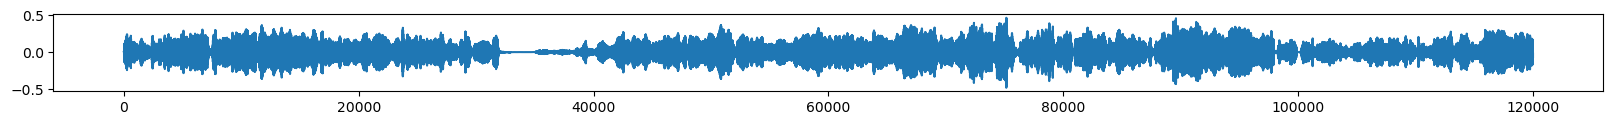

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2025-10-25 17:08:04.096082, epoch 64,  Loss: 0.2204
  Quantizer 0 Loss: 2.1975
  Quantizer 1 Loss: 2.7141
  Quantizer 2 Loss: 3.3668
  Quantizer 3 Loss: 3.8172
  Quantizer 4 Loss: 4.1244
  Quantizer 5 Loss: 4.3226
  Quantizer 6 Loss: 4.5666
  Quantizer 7 Loss: 4.6990
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


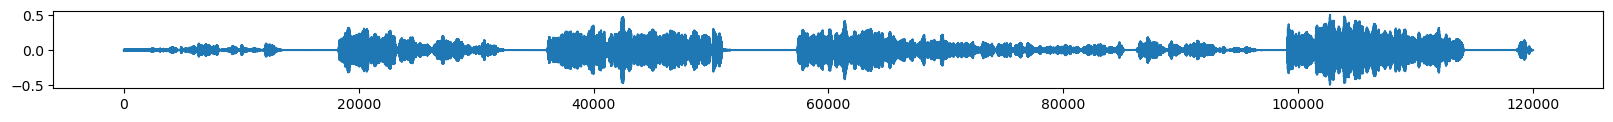

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2025-10-25 17:08:53.770853, epoch 65,  Loss: 0.2208
  Quantizer 0 Loss: 2.1905
  Quantizer 1 Loss: 2.7029
  Quantizer 2 Loss: 3.3541
  Quantizer 3 Loss: 3.8029
  Quantizer 4 Loss: 4.1214
  Quantizer 5 Loss: 4.3230
  Quantizer 6 Loss: 4.5639
  Quantizer 7 Loss: 4.6945
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


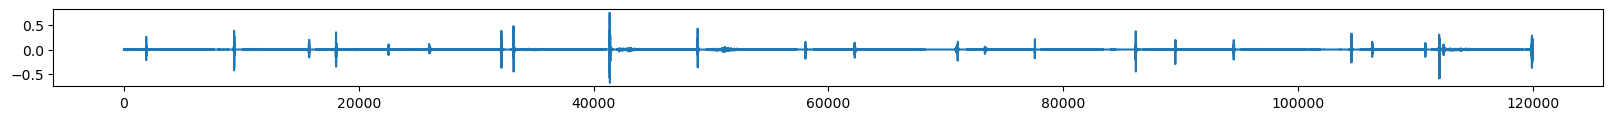

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2025-10-25 17:09:43.376441, epoch 66,  Loss: 0.2150
  Quantizer 0 Loss: 2.2033
  Quantizer 1 Loss: 2.7139
  Quantizer 2 Loss: 3.3719
  Quantizer 3 Loss: 3.8256
  Quantizer 4 Loss: 4.1352
  Quantizer 5 Loss: 4.3338
  Quantizer 6 Loss: 4.5782
  Quantizer 7 Loss: 4.7099
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


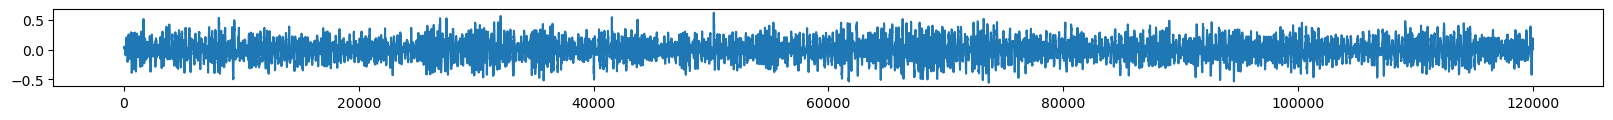

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2025-10-25 17:10:33.602251, epoch 67,  Loss: 0.2199
  Quantizer 0 Loss: 2.1923
  Quantizer 1 Loss: 2.7067
  Quantizer 2 Loss: 3.3593
  Quantizer 3 Loss: 3.8103
  Quantizer 4 Loss: 4.1205
  Quantizer 5 Loss: 4.3248
  Quantizer 6 Loss: 4.5708
  Quantizer 7 Loss: 4.7046
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


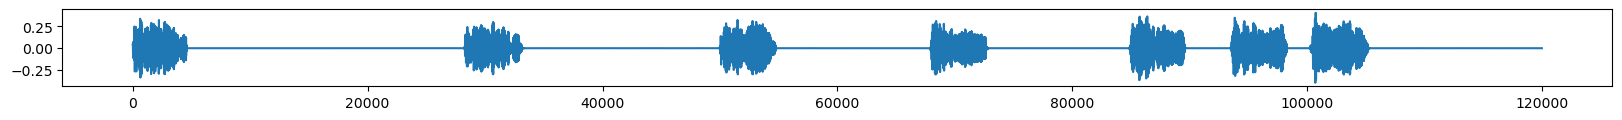

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2025-10-25 17:11:24.858671, epoch 68,  Loss: 0.2249
  Quantizer 0 Loss: 2.1914
  Quantizer 1 Loss: 2.7040
  Quantizer 2 Loss: 3.3566
  Quantizer 3 Loss: 3.8064
  Quantizer 4 Loss: 4.1240
  Quantizer 5 Loss: 4.3277
  Quantizer 6 Loss: 4.5665
  Quantizer 7 Loss: 4.7036
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


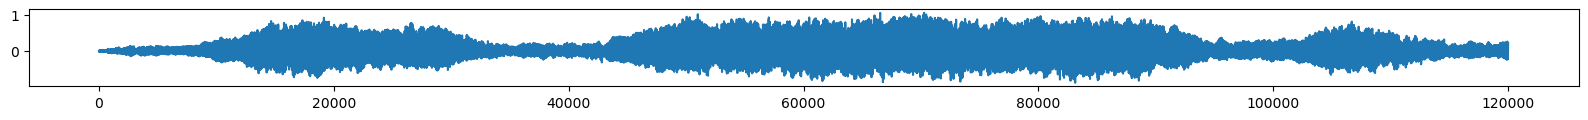

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2025-10-25 17:12:13.793929, epoch 69,  Loss: 0.2180
  Quantizer 0 Loss: 2.2007
  Quantizer 1 Loss: 2.7111
  Quantizer 2 Loss: 3.3614
  Quantizer 3 Loss: 3.8099
  Quantizer 4 Loss: 4.1226
  Quantizer 5 Loss: 4.3264
  Quantizer 6 Loss: 4.5745
  Quantizer 7 Loss: 4.7089
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


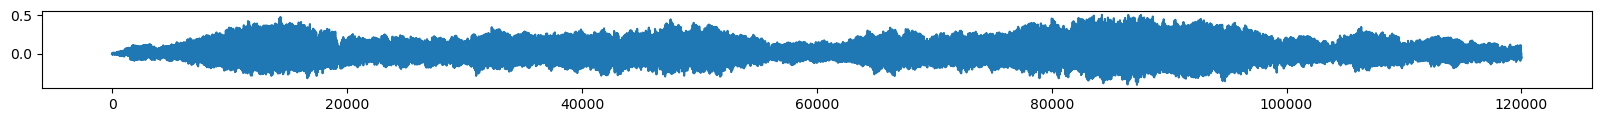

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2025-10-25 17:13:02.369361, epoch 70,  Loss: 0.2141
  Quantizer 0 Loss: 2.1907
  Quantizer 1 Loss: 2.6988
  Quantizer 2 Loss: 3.3487
  Quantizer 3 Loss: 3.7951
  Quantizer 4 Loss: 4.1099
  Quantizer 5 Loss: 4.3103
  Quantizer 6 Loss: 4.5542
  Quantizer 7 Loss: 4.6852
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


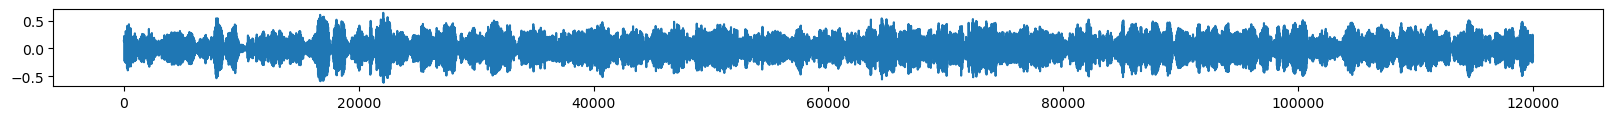

Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2025-10-25 17:13:52.846793, epoch 71,  Loss: 0.2160
  Quantizer 0 Loss: 2.1894
  Quantizer 1 Loss: 2.7061
  Quantizer 2 Loss: 3.3576
  Quantizer 3 Loss: 3.8102
  Quantizer 4 Loss: 4.1279
  Quantizer 5 Loss: 4.3309
  Quantizer 6 Loss: 4.5796
  Quantizer 7 Loss: 4.7055
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


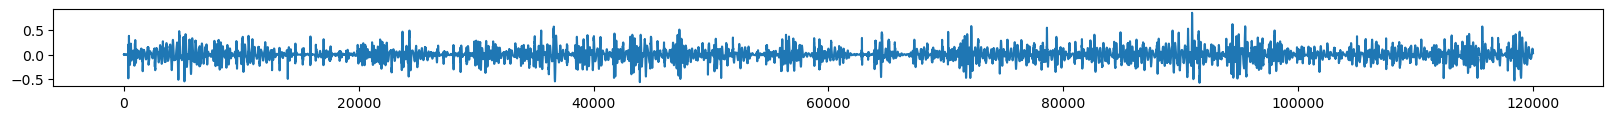

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2025-10-25 17:14:42.191710, epoch 72,  Loss: 0.2237
  Quantizer 0 Loss: 2.1923
  Quantizer 1 Loss: 2.7002
  Quantizer 2 Loss: 3.3436
  Quantizer 3 Loss: 3.7944
  Quantizer 4 Loss: 4.1045
  Quantizer 5 Loss: 4.3109
  Quantizer 6 Loss: 4.5583
  Quantizer 7 Loss: 4.6917
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


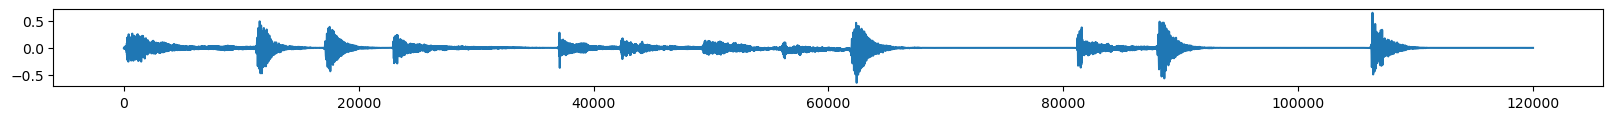

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2025-10-25 17:15:31.112082, epoch 73,  Loss: 0.2182
  Quantizer 0 Loss: 2.1886
  Quantizer 1 Loss: 2.6910
  Quantizer 2 Loss: 3.3409
  Quantizer 3 Loss: 3.7871
  Quantizer 4 Loss: 4.1025
  Quantizer 5 Loss: 4.3090
  Quantizer 6 Loss: 4.5511
  Quantizer 7 Loss: 4.6863
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


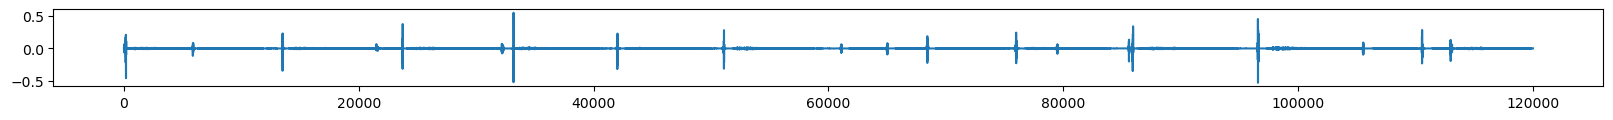

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2025-10-25 17:16:20.945428, epoch 74,  Loss: 0.2199
  Quantizer 0 Loss: 2.1777
  Quantizer 1 Loss: 2.6743
  Quantizer 2 Loss: 3.3302
  Quantizer 3 Loss: 3.7767
  Quantizer 4 Loss: 4.0942
  Quantizer 5 Loss: 4.2955
  Quantizer 6 Loss: 4.5396
  Quantizer 7 Loss: 4.6766
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


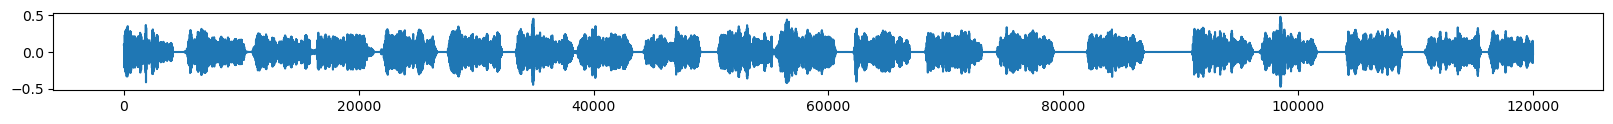

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2025-10-25 17:17:09.819335, epoch 75,  Loss: 0.2201
  Quantizer 0 Loss: 2.1792
  Quantizer 1 Loss: 2.6853
  Quantizer 2 Loss: 3.3353
  Quantizer 3 Loss: 3.7820
  Quantizer 4 Loss: 4.0970
  Quantizer 5 Loss: 4.3029
  Quantizer 6 Loss: 4.5459
  Quantizer 7 Loss: 4.6788
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


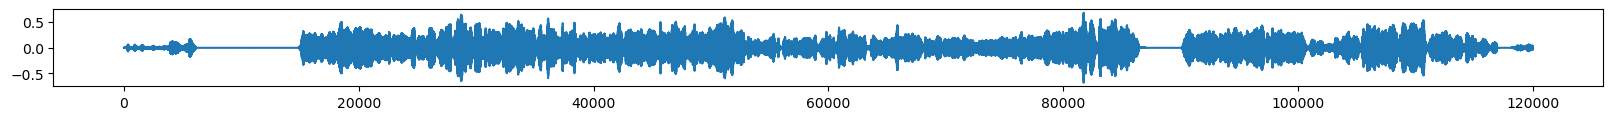

Saved checkpoint at epoch 75
Finished epoch number 75 with a total of 10000 debug_seqs
 time: 2025-10-25 17:17:59.502051, epoch 76,  Loss: 0.2532
  Quantizer 0 Loss: 2.2013
  Quantizer 1 Loss: 3.3166
  Quantizer 2 Loss: 4.1462
  Quantizer 3 Loss: 4.6445
  Quantizer 4 Loss: 4.9549
  Quantizer 5 Loss: 5.1428
  Quantizer 6 Loss: 5.3639
  Quantizer 7 Loss: 5.4484
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


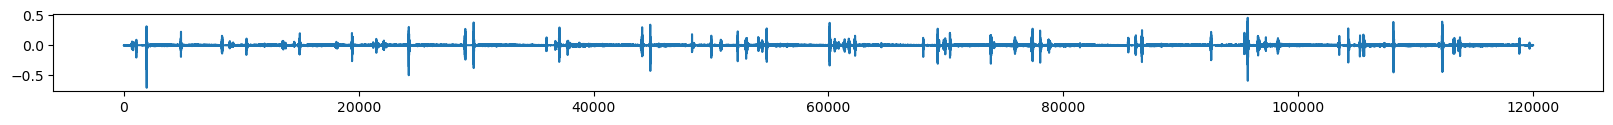

Finished epoch number 76 with a total of 10000 debug_seqs
 time: 2025-10-25 17:18:49.206807, epoch 77,  Loss: 0.2496
  Quantizer 0 Loss: 2.1777
  Quantizer 1 Loss: 3.1643
  Quantizer 2 Loss: 3.9524
  Quantizer 3 Loss: 4.4451
  Quantizer 4 Loss: 4.7665
  Quantizer 5 Loss: 4.9702
  Quantizer 6 Loss: 5.2010
  Quantizer 7 Loss: 5.3005
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


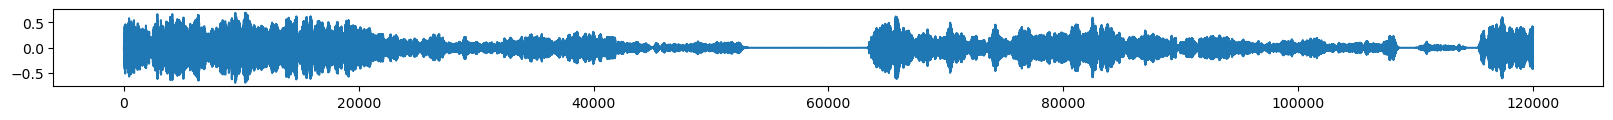

Finished epoch number 77 with a total of 10000 debug_seqs
 time: 2025-10-25 17:19:38.342616, epoch 78,  Loss: 0.2467
  Quantizer 0 Loss: 2.1918
  Quantizer 1 Loss: 3.1731
  Quantizer 2 Loss: 3.9383
  Quantizer 3 Loss: 4.4212
  Quantizer 4 Loss: 4.7438
  Quantizer 5 Loss: 4.9368
  Quantizer 6 Loss: 5.1739
  Quantizer 7 Loss: 5.2808
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


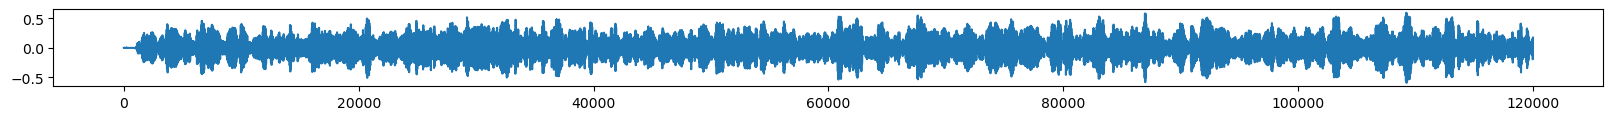

Finished epoch number 78 with a total of 10000 debug_seqs
 time: 2025-10-25 17:20:27.591423, epoch 79,  Loss: 0.2380
  Quantizer 0 Loss: 2.1825
  Quantizer 1 Loss: 3.1358
  Quantizer 2 Loss: 3.9032
  Quantizer 3 Loss: 4.3874
  Quantizer 4 Loss: 4.7008
  Quantizer 5 Loss: 4.8981
  Quantizer 6 Loss: 5.1298
  Quantizer 7 Loss: 5.2358
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


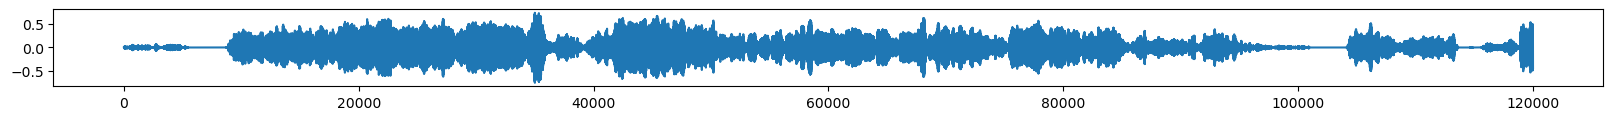

Finished epoch number 79 with a total of 10000 debug_seqs
 time: 2025-10-25 17:21:18.619055, epoch 80,  Loss: 0.2467
  Quantizer 0 Loss: 2.1848
  Quantizer 1 Loss: 3.1419
  Quantizer 2 Loss: 3.9013
  Quantizer 3 Loss: 4.3777
  Quantizer 4 Loss: 4.6904
  Quantizer 5 Loss: 4.8847
  Quantizer 6 Loss: 5.1261
  Quantizer 7 Loss: 5.2250
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


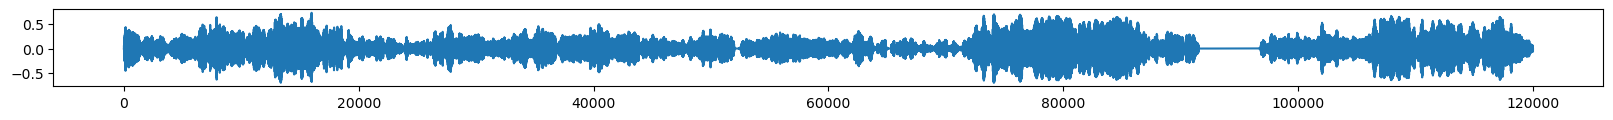

Finished epoch number 80 with a total of 10000 debug_seqs
 time: 2025-10-25 17:22:09.366446, epoch 81,  Loss: 0.2382
  Quantizer 0 Loss: 2.1731
  Quantizer 1 Loss: 3.1301
  Quantizer 2 Loss: 3.8899
  Quantizer 3 Loss: 4.3669
  Quantizer 4 Loss: 4.6789
  Quantizer 5 Loss: 4.8772
  Quantizer 6 Loss: 5.1117
  Quantizer 7 Loss: 5.2200
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


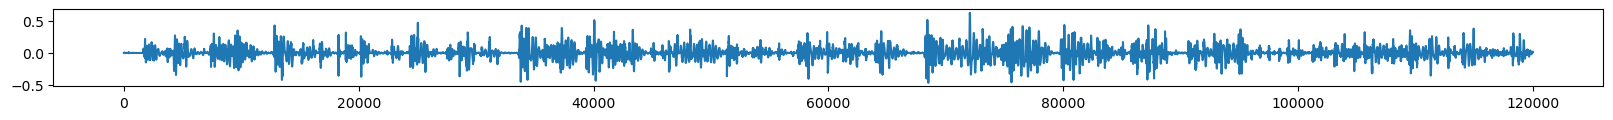

Finished epoch number 81 with a total of 10000 debug_seqs
 time: 2025-10-25 17:23:00.229308, epoch 82,  Loss: 0.2535
  Quantizer 0 Loss: 2.1825
  Quantizer 1 Loss: 3.1356
  Quantizer 2 Loss: 3.8952
  Quantizer 3 Loss: 4.3691
  Quantizer 4 Loss: 4.6820
  Quantizer 5 Loss: 4.8821
  Quantizer 6 Loss: 5.1104
  Quantizer 7 Loss: 5.2150
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


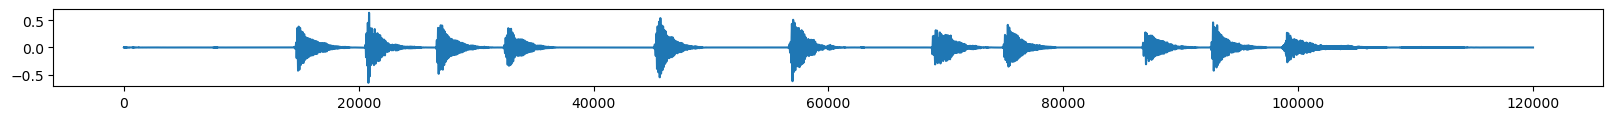

Finished epoch number 82 with a total of 10000 debug_seqs
 time: 2025-10-25 17:23:49.180606, epoch 83,  Loss: 0.2500
  Quantizer 0 Loss: 2.1746
  Quantizer 1 Loss: 3.1248
  Quantizer 2 Loss: 3.8830
  Quantizer 3 Loss: 4.3564
  Quantizer 4 Loss: 4.6626
  Quantizer 5 Loss: 4.8576
  Quantizer 6 Loss: 5.0900
  Quantizer 7 Loss: 5.1929
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


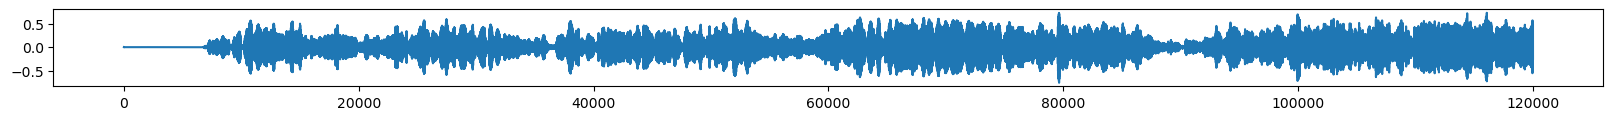

Finished epoch number 83 with a total of 10000 debug_seqs
 time: 2025-10-25 17:24:38.541883, epoch 84,  Loss: 0.2495
  Quantizer 0 Loss: 2.1910
  Quantizer 1 Loss: 3.1314
  Quantizer 2 Loss: 3.8845
  Quantizer 3 Loss: 4.3616
  Quantizer 4 Loss: 4.6686
  Quantizer 5 Loss: 4.8651
  Quantizer 6 Loss: 5.0932
  Quantizer 7 Loss: 5.2028
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


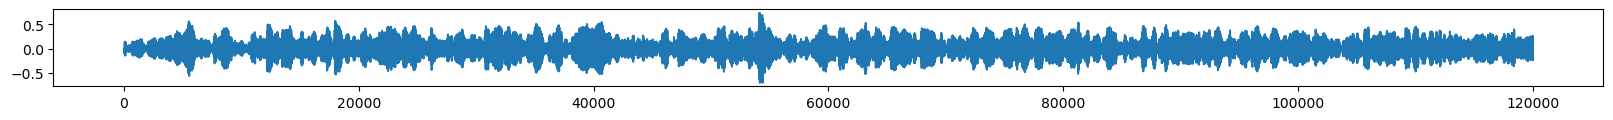

Finished epoch number 84 with a total of 10000 debug_seqs
 time: 2025-10-25 17:25:28.686233, epoch 85,  Loss: 0.2513
  Quantizer 0 Loss: 2.1955
  Quantizer 1 Loss: 3.1269
  Quantizer 2 Loss: 3.8884
  Quantizer 3 Loss: 4.3531
  Quantizer 4 Loss: 4.6608
  Quantizer 5 Loss: 4.8535
  Quantizer 6 Loss: 5.0744
  Quantizer 7 Loss: 5.1770
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


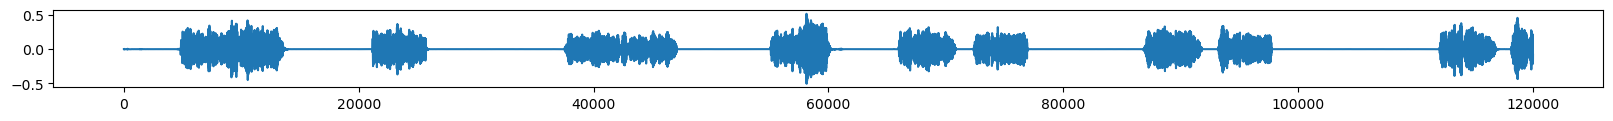

Finished epoch number 85 with a total of 10000 debug_seqs
 time: 2025-10-25 17:26:18.397887, epoch 86,  Loss: 0.2463
  Quantizer 0 Loss: 2.1858
  Quantizer 1 Loss: 3.1239
  Quantizer 2 Loss: 3.8807
  Quantizer 3 Loss: 4.3576
  Quantizer 4 Loss: 4.6609
  Quantizer 5 Loss: 4.8518
  Quantizer 6 Loss: 5.0880
  Quantizer 7 Loss: 5.1909
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


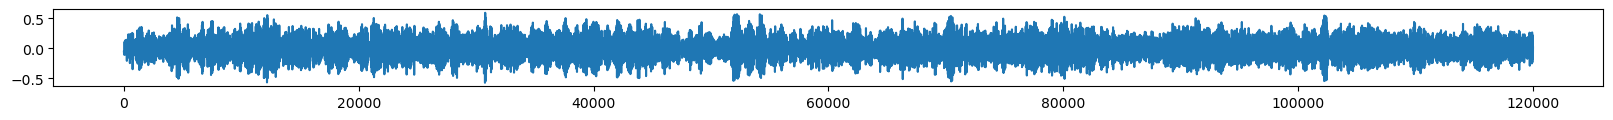

Finished epoch number 86 with a total of 10000 debug_seqs
 time: 2025-10-25 17:27:07.888802, epoch 87,  Loss: 0.2390
  Quantizer 0 Loss: 2.1779
  Quantizer 1 Loss: 3.1145
  Quantizer 2 Loss: 3.8667
  Quantizer 3 Loss: 4.3385
  Quantizer 4 Loss: 4.6492
  Quantizer 5 Loss: 4.8449
  Quantizer 6 Loss: 5.0696
  Quantizer 7 Loss: 5.1745
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


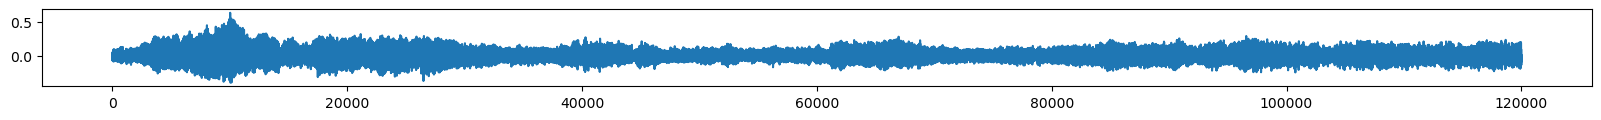

Finished epoch number 87 with a total of 10000 debug_seqs
 time: 2025-10-25 17:27:58.041537, epoch 88,  Loss: 0.2516
  Quantizer 0 Loss: 2.1990
  Quantizer 1 Loss: 3.1296
  Quantizer 2 Loss: 3.8889
  Quantizer 3 Loss: 4.3571
  Quantizer 4 Loss: 4.6656
  Quantizer 5 Loss: 4.8531
  Quantizer 6 Loss: 5.0815
  Quantizer 7 Loss: 5.1824
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


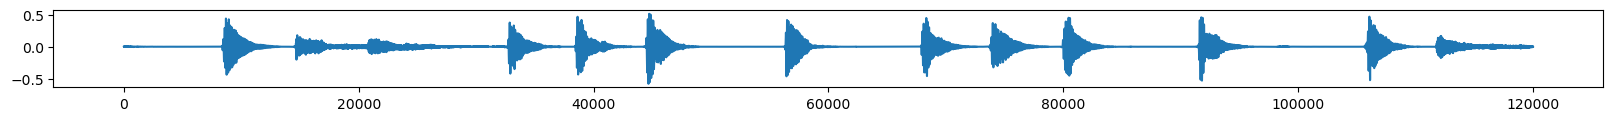

Finished epoch number 88 with a total of 10000 debug_seqs
 time: 2025-10-25 17:28:47.420130, epoch 89,  Loss: 0.2444
  Quantizer 0 Loss: 2.1886
  Quantizer 1 Loss: 3.1221
  Quantizer 2 Loss: 3.8723
  Quantizer 3 Loss: 4.3428
  Quantizer 4 Loss: 4.6511
  Quantizer 5 Loss: 4.8415
  Quantizer 6 Loss: 5.0677
  Quantizer 7 Loss: 5.1709
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


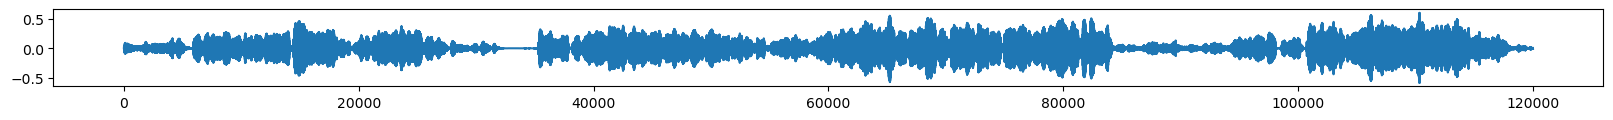

Finished epoch number 89 with a total of 10000 debug_seqs
 time: 2025-10-25 17:29:37.217076, epoch 90,  Loss: 0.2457
  Quantizer 0 Loss: 2.1776
  Quantizer 1 Loss: 3.1111
  Quantizer 2 Loss: 3.8633
  Quantizer 3 Loss: 4.3356
  Quantizer 4 Loss: 4.6424
  Quantizer 5 Loss: 4.8358
  Quantizer 6 Loss: 5.0661
  Quantizer 7 Loss: 5.1713
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


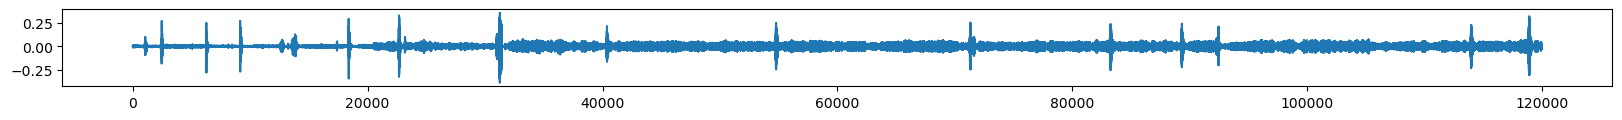

Finished epoch number 90 with a total of 10000 debug_seqs
 time: 2025-10-25 17:30:26.907936, epoch 91,  Loss: 0.2477
  Quantizer 0 Loss: 2.1761
  Quantizer 1 Loss: 3.1196
  Quantizer 2 Loss: 3.8736
  Quantizer 3 Loss: 4.3487
  Quantizer 4 Loss: 4.6562
  Quantizer 5 Loss: 4.8492
  Quantizer 6 Loss: 5.0796
  Quantizer 7 Loss: 5.1817
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


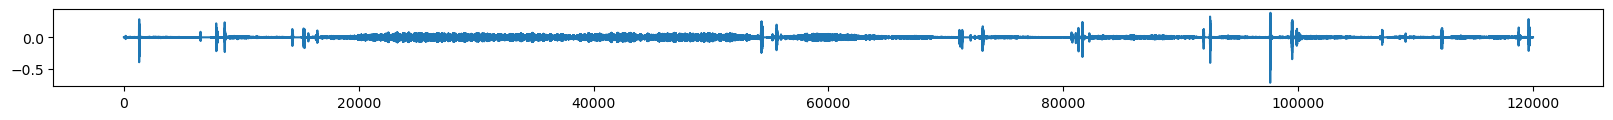

Finished epoch number 91 with a total of 10000 debug_seqs
 time: 2025-10-25 17:31:15.937005, epoch 92,  Loss: 0.2361
  Quantizer 0 Loss: 2.1679
  Quantizer 1 Loss: 3.1113
  Quantizer 2 Loss: 3.8578
  Quantizer 3 Loss: 4.3354
  Quantizer 4 Loss: 4.6433
  Quantizer 5 Loss: 4.8369
  Quantizer 6 Loss: 5.0628
  Quantizer 7 Loss: 5.1709
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


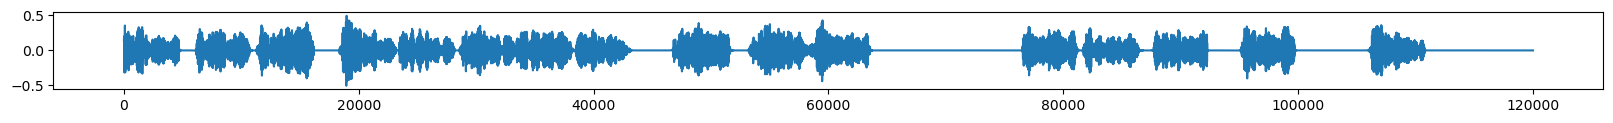

Finished epoch number 92 with a total of 10000 debug_seqs
 time: 2025-10-25 17:32:04.609769, epoch 93,  Loss: 0.2492
  Quantizer 0 Loss: 2.1748
  Quantizer 1 Loss: 3.1115
  Quantizer 2 Loss: 3.8669
  Quantizer 3 Loss: 4.3428
  Quantizer 4 Loss: 4.6540
  Quantizer 5 Loss: 4.8474
  Quantizer 6 Loss: 5.0768
  Quantizer 7 Loss: 5.1799
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


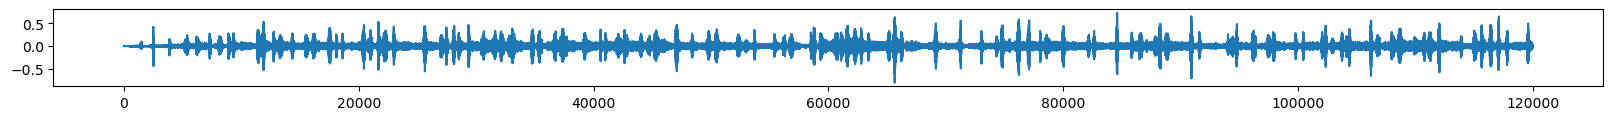

Finished epoch number 93 with a total of 10000 debug_seqs
 time: 2025-10-25 17:32:53.695190, epoch 94,  Loss: 0.2378
  Quantizer 0 Loss: 2.1845
  Quantizer 1 Loss: 3.1199
  Quantizer 2 Loss: 3.8755
  Quantizer 3 Loss: 4.3510
  Quantizer 4 Loss: 4.6568
  Quantizer 5 Loss: 4.8515
  Quantizer 6 Loss: 5.0805
  Quantizer 7 Loss: 5.1896
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


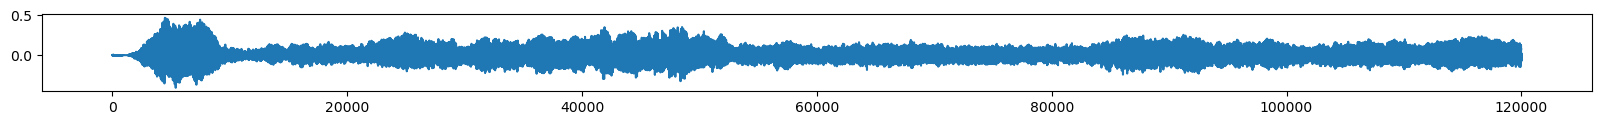

Finished epoch number 94 with a total of 10000 debug_seqs
 time: 2025-10-25 17:33:43.531408, epoch 95,  Loss: 0.2510
  Quantizer 0 Loss: 2.1759
  Quantizer 1 Loss: 3.1026
  Quantizer 2 Loss: 3.8640
  Quantizer 3 Loss: 4.3310
  Quantizer 4 Loss: 4.6413
  Quantizer 5 Loss: 4.8361
  Quantizer 6 Loss: 5.0602
  Quantizer 7 Loss: 5.1608
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


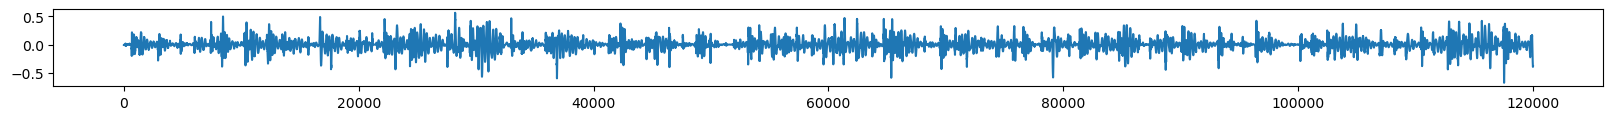

Finished epoch number 95 with a total of 10000 debug_seqs
 time: 2025-10-25 17:34:33.411772, epoch 96,  Loss: 0.2410
  Quantizer 0 Loss: 2.1749
  Quantizer 1 Loss: 3.1169
  Quantizer 2 Loss: 3.8724
  Quantizer 3 Loss: 4.3443
  Quantizer 4 Loss: 4.6535
  Quantizer 5 Loss: 4.8492
  Quantizer 6 Loss: 5.0784
  Quantizer 7 Loss: 5.1859
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


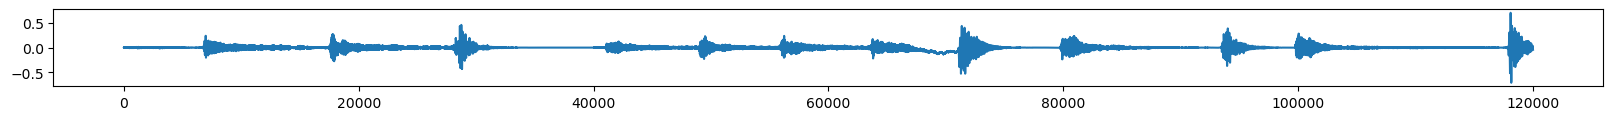

Finished epoch number 96 with a total of 10000 debug_seqs
 time: 2025-10-25 17:35:24.373564, epoch 97,  Loss: 0.2447
  Quantizer 0 Loss: 2.1754
  Quantizer 1 Loss: 3.1066
  Quantizer 2 Loss: 3.8637
  Quantizer 3 Loss: 4.3366
  Quantizer 4 Loss: 4.6485
  Quantizer 5 Loss: 4.8355
  Quantizer 6 Loss: 5.0641
  Quantizer 7 Loss: 5.1674
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


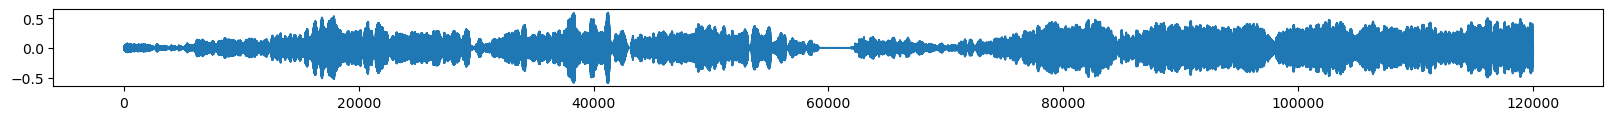

Finished epoch number 97 with a total of 10000 debug_seqs
 time: 2025-10-25 17:36:13.389795, epoch 98,  Loss: 0.2501
  Quantizer 0 Loss: 2.1719
  Quantizer 1 Loss: 3.1008
  Quantizer 2 Loss: 3.8575
  Quantizer 3 Loss: 4.3402
  Quantizer 4 Loss: 4.6436
  Quantizer 5 Loss: 4.8392
  Quantizer 6 Loss: 5.0667
  Quantizer 7 Loss: 5.1742
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


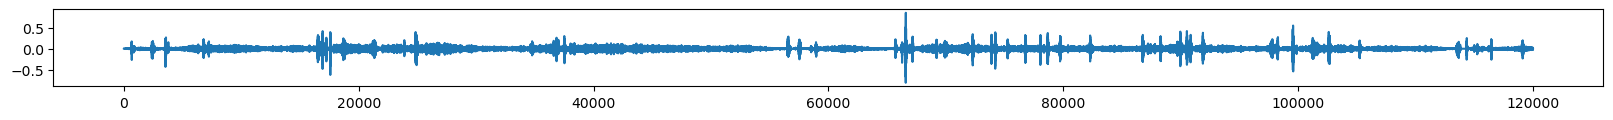

Finished epoch number 98 with a total of 10000 debug_seqs
 time: 2025-10-25 17:37:02.622173, epoch 99,  Loss: 0.2320
  Quantizer 0 Loss: 2.1569
  Quantizer 1 Loss: 3.0914
  Quantizer 2 Loss: 3.8447
  Quantizer 3 Loss: 4.3157
  Quantizer 4 Loss: 4.6304
  Quantizer 5 Loss: 4.8227
  Quantizer 6 Loss: 5.0494
  Quantizer 7 Loss: 5.1508
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


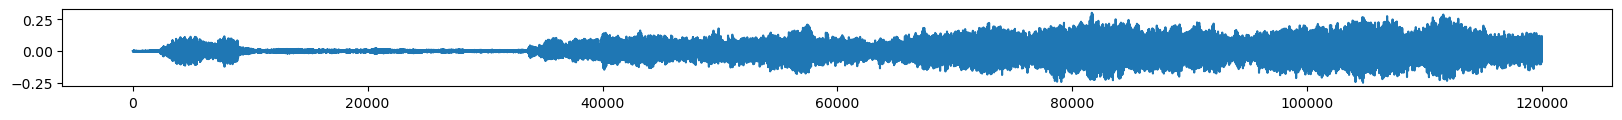

Finished epoch number 99 with a total of 10000 debug_seqs
 time: 2025-10-25 17:37:52.990324, epoch 100,  Loss: 0.2422
  Quantizer 0 Loss: 2.1700
  Quantizer 1 Loss: 3.1092
  Quantizer 2 Loss: 3.8588
  Quantizer 3 Loss: 4.3341
  Quantizer 4 Loss: 4.6430
  Quantizer 5 Loss: 4.8367
  Quantizer 6 Loss: 5.0690
  Quantizer 7 Loss: 5.1692
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


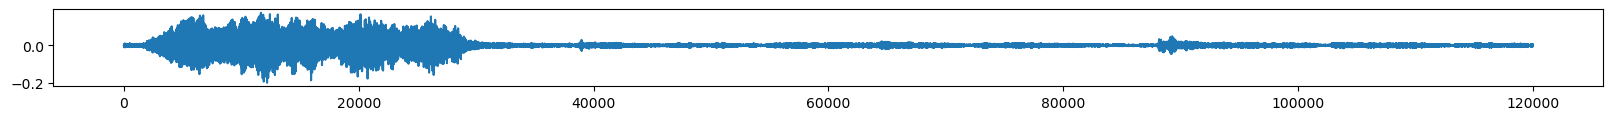

Saved checkpoint at epoch 100
Finished epoch number 100 with a total of 10000 debug_seqs
 time: 2025-10-25 17:38:42.285242, epoch 101,  Loss: 0.2226
  Quantizer 0 Loss: 2.1638
  Quantizer 1 Loss: 2.7946
  Quantizer 2 Loss: 3.5133
  Quantizer 3 Loss: 4.0109
  Quantizer 4 Loss: 4.3510
  Quantizer 5 Loss: 4.5605
  Quantizer 6 Loss: 4.8191
  Quantizer 7 Loss: 4.9409
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


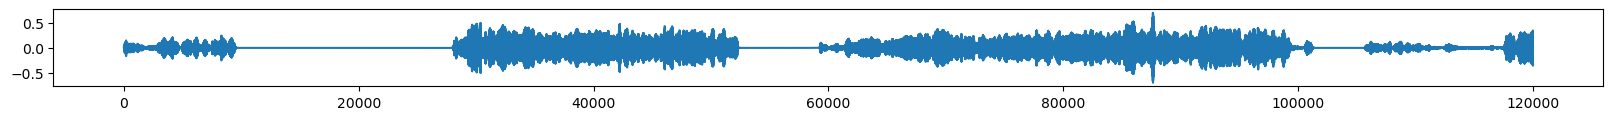

Finished epoch number 101 with a total of 10000 debug_seqs
 time: 2025-10-25 17:39:31.203234, epoch 102,  Loss: 0.2126
  Quantizer 0 Loss: 2.1688
  Quantizer 1 Loss: 2.7226
  Quantizer 2 Loss: 3.4047
  Quantizer 3 Loss: 3.8823
  Quantizer 4 Loss: 4.2081
  Quantizer 5 Loss: 4.4269
  Quantizer 6 Loss: 4.6784
  Quantizer 7 Loss: 4.8110
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


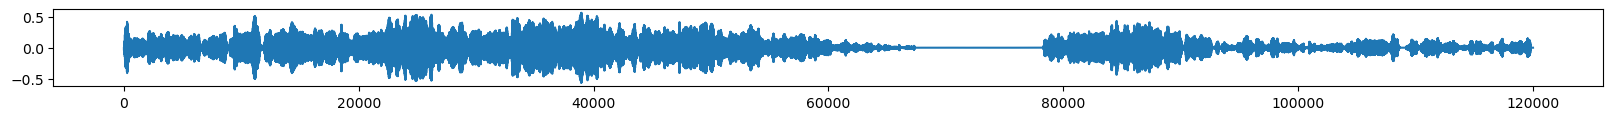

Finished epoch number 102 with a total of 10000 debug_seqs
 time: 2025-10-25 17:40:20.912832, epoch 103,  Loss: 0.2208
  Quantizer 0 Loss: 2.1740
  Quantizer 1 Loss: 2.7189
  Quantizer 2 Loss: 3.3891
  Quantizer 3 Loss: 3.8545
  Quantizer 4 Loss: 4.1761
  Quantizer 5 Loss: 4.3877
  Quantizer 6 Loss: 4.6355
  Quantizer 7 Loss: 4.7692
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


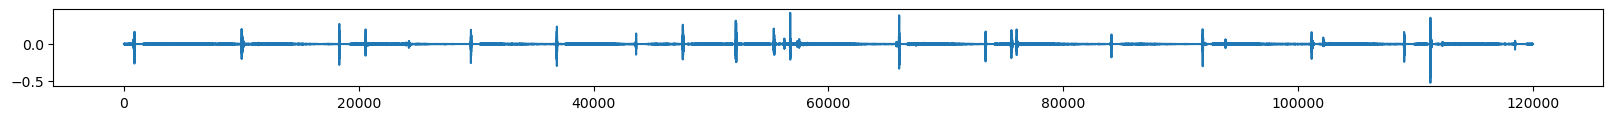

Finished epoch number 103 with a total of 10000 debug_seqs
 time: 2025-10-25 17:41:10.550747, epoch 104,  Loss: 0.2246
  Quantizer 0 Loss: 2.1764
  Quantizer 1 Loss: 2.7128
  Quantizer 2 Loss: 3.3821
  Quantizer 3 Loss: 3.8397
  Quantizer 4 Loss: 4.1667
  Quantizer 5 Loss: 4.3719
  Quantizer 6 Loss: 4.6193
  Quantizer 7 Loss: 4.7517
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


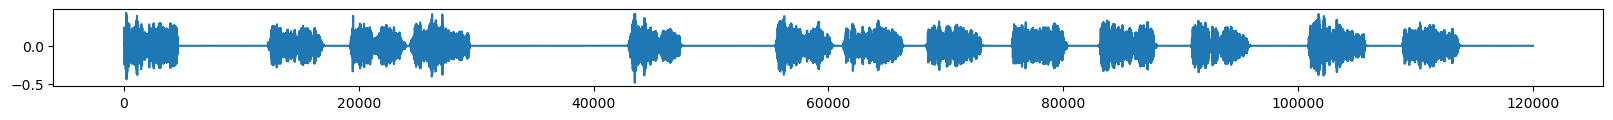

Finished epoch number 104 with a total of 10000 debug_seqs
 time: 2025-10-25 17:41:59.163167, epoch 105,  Loss: 0.2286
  Quantizer 0 Loss: 2.1791
  Quantizer 1 Loss: 2.7098
  Quantizer 2 Loss: 3.3724
  Quantizer 3 Loss: 3.8329
  Quantizer 4 Loss: 4.1545
  Quantizer 5 Loss: 4.3633
  Quantizer 6 Loss: 4.6100
  Quantizer 7 Loss: 4.7388
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


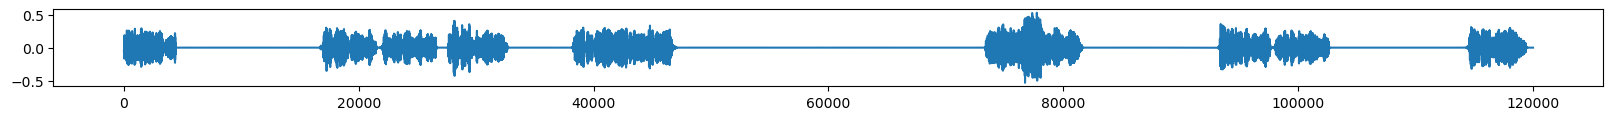

Finished epoch number 105 with a total of 10000 debug_seqs
 time: 2025-10-25 17:42:47.793894, epoch 106,  Loss: 0.2173
  Quantizer 0 Loss: 2.1697
  Quantizer 1 Loss: 2.6922
  Quantizer 2 Loss: 3.3534
  Quantizer 3 Loss: 3.8140
  Quantizer 4 Loss: 4.1361
  Quantizer 5 Loss: 4.3423
  Quantizer 6 Loss: 4.5865
  Quantizer 7 Loss: 4.7237
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


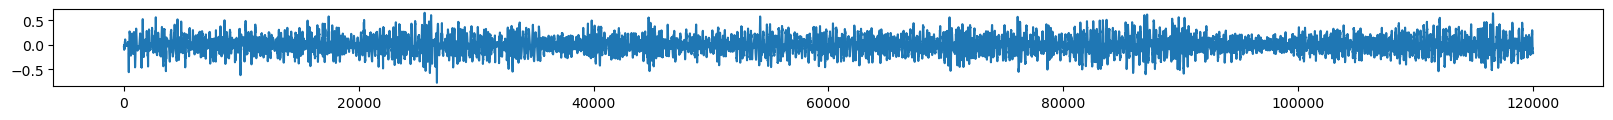

Finished epoch number 106 with a total of 10000 debug_seqs
 time: 2025-10-25 17:43:37.793010, epoch 107,  Loss: 0.2158
  Quantizer 0 Loss: 2.1697
  Quantizer 1 Loss: 2.6885
  Quantizer 2 Loss: 3.3421
  Quantizer 3 Loss: 3.8005
  Quantizer 4 Loss: 4.1194
  Quantizer 5 Loss: 4.3218
  Quantizer 6 Loss: 4.5715
  Quantizer 7 Loss: 4.7053
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


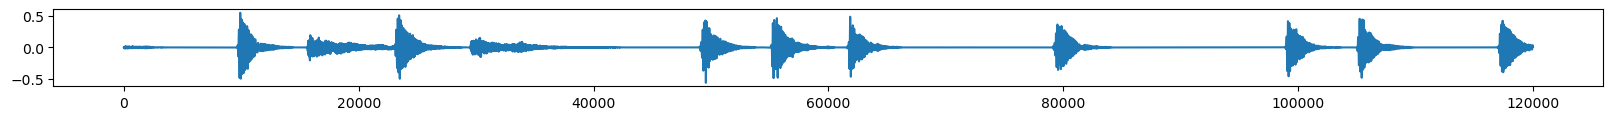

Finished epoch number 107 with a total of 10000 debug_seqs
 time: 2025-10-25 17:44:26.582496, epoch 108,  Loss: 0.2209
  Quantizer 0 Loss: 2.1723
  Quantizer 1 Loss: 2.6908
  Quantizer 2 Loss: 3.3448
  Quantizer 3 Loss: 3.8048
  Quantizer 4 Loss: 4.1269
  Quantizer 5 Loss: 4.3306
  Quantizer 6 Loss: 4.5774
  Quantizer 7 Loss: 4.7092
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


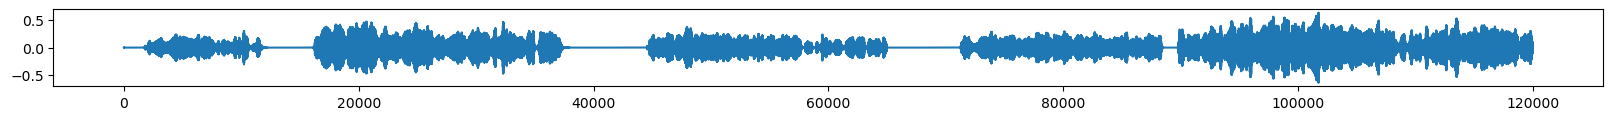

Finished epoch number 108 with a total of 10000 debug_seqs
 time: 2025-10-25 17:45:16.365952, epoch 109,  Loss: 0.2205
  Quantizer 0 Loss: 2.1629
  Quantizer 1 Loss: 2.6797
  Quantizer 2 Loss: 3.3333
  Quantizer 3 Loss: 3.7852
  Quantizer 4 Loss: 4.1019
  Quantizer 5 Loss: 4.3062
  Quantizer 6 Loss: 4.5510
  Quantizer 7 Loss: 4.6832
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


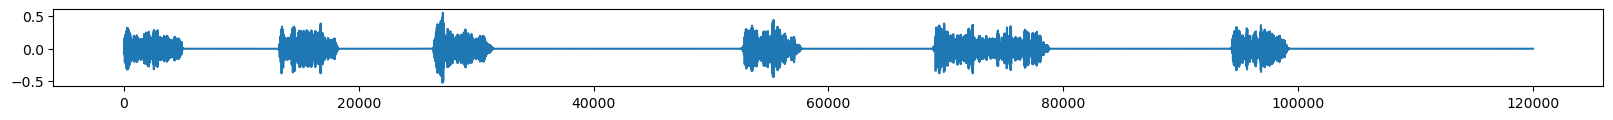

Finished epoch number 109 with a total of 10000 debug_seqs
 time: 2025-10-25 17:46:06.595510, epoch 110,  Loss: 0.2178
  Quantizer 0 Loss: 2.1732
  Quantizer 1 Loss: 2.6967
  Quantizer 2 Loss: 3.3450
  Quantizer 3 Loss: 3.7978
  Quantizer 4 Loss: 4.1166
  Quantizer 5 Loss: 4.3249
  Quantizer 6 Loss: 4.5700
  Quantizer 7 Loss: 4.7025
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


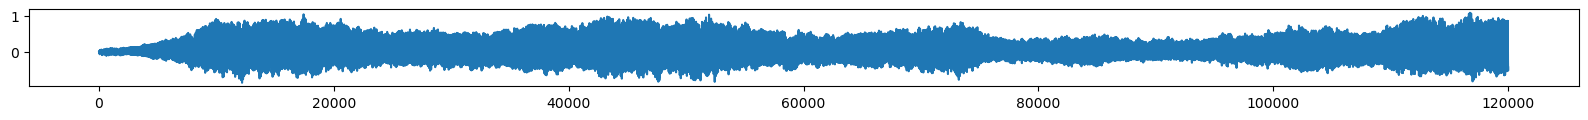

Finished epoch number 110 with a total of 10000 debug_seqs
 time: 2025-10-25 17:46:54.873172, epoch 111,  Loss: 0.2185
  Quantizer 0 Loss: 2.1698
  Quantizer 1 Loss: 2.6856
  Quantizer 2 Loss: 3.3351
  Quantizer 3 Loss: 3.7969
  Quantizer 4 Loss: 4.1089
  Quantizer 5 Loss: 4.3141
  Quantizer 6 Loss: 4.5600
  Quantizer 7 Loss: 4.6910
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


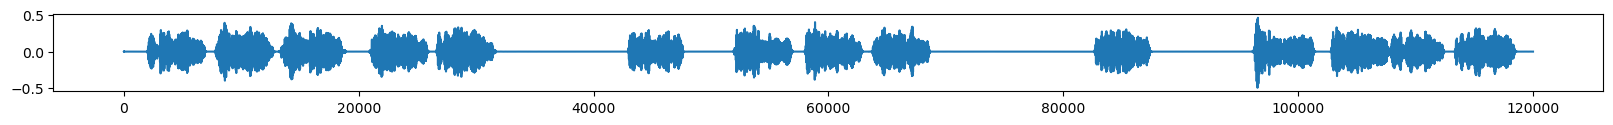

Finished epoch number 111 with a total of 10000 debug_seqs
 time: 2025-10-25 17:47:45.079412, epoch 112,  Loss: 0.2125
  Quantizer 0 Loss: 2.1676
  Quantizer 1 Loss: 2.6823
  Quantizer 2 Loss: 3.3273
  Quantizer 3 Loss: 3.7867
  Quantizer 4 Loss: 4.0999
  Quantizer 5 Loss: 4.3056
  Quantizer 6 Loss: 4.5523
  Quantizer 7 Loss: 4.6836
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


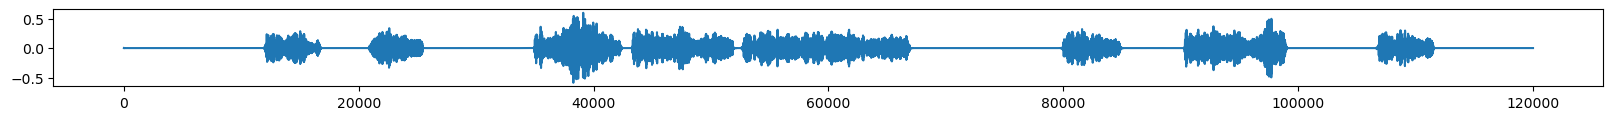

Finished epoch number 112 with a total of 10000 debug_seqs
 time: 2025-10-25 17:48:33.632415, epoch 113,  Loss: 0.2154
  Quantizer 0 Loss: 2.1836
  Quantizer 1 Loss: 2.6979
  Quantizer 2 Loss: 3.3537
  Quantizer 3 Loss: 3.8023
  Quantizer 4 Loss: 4.1213
  Quantizer 5 Loss: 4.3238
  Quantizer 6 Loss: 4.5706
  Quantizer 7 Loss: 4.7030
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


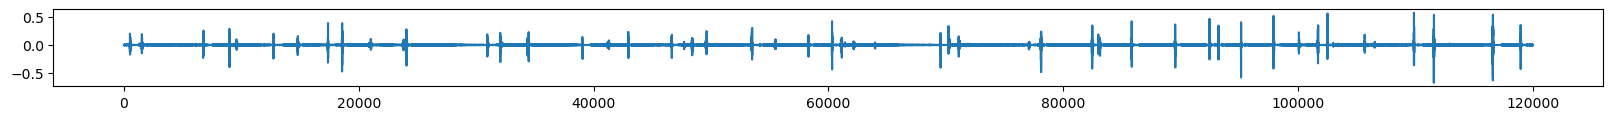

Finished epoch number 113 with a total of 10000 debug_seqs
 time: 2025-10-25 17:49:21.647298, epoch 114,  Loss: 0.2133
  Quantizer 0 Loss: 2.1597
  Quantizer 1 Loss: 2.6629
  Quantizer 2 Loss: 3.3188
  Quantizer 3 Loss: 3.7639
  Quantizer 4 Loss: 4.0783
  Quantizer 5 Loss: 4.2893
  Quantizer 6 Loss: 4.5329
  Quantizer 7 Loss: 4.6643
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


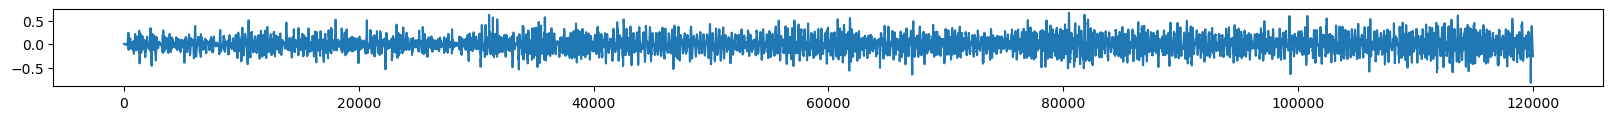

Finished epoch number 114 with a total of 10000 debug_seqs
 time: 2025-10-25 17:50:10.005639, epoch 115,  Loss: 0.2179
  Quantizer 0 Loss: 2.1613
  Quantizer 1 Loss: 2.6680
  Quantizer 2 Loss: 3.3234
  Quantizer 3 Loss: 3.7709
  Quantizer 4 Loss: 4.0888
  Quantizer 5 Loss: 4.2937
  Quantizer 6 Loss: 4.5404
  Quantizer 7 Loss: 4.6694
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


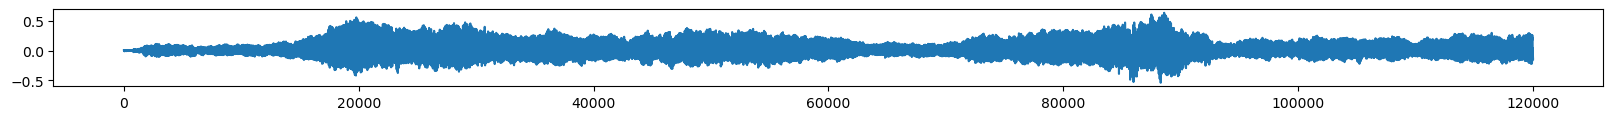

Finished epoch number 115 with a total of 10000 debug_seqs
 time: 2025-10-25 17:50:59.776472, epoch 116,  Loss: 0.2135
  Quantizer 0 Loss: 2.1693
  Quantizer 1 Loss: 2.6725
  Quantizer 2 Loss: 3.3265
  Quantizer 3 Loss: 3.7728
  Quantizer 4 Loss: 4.0862
  Quantizer 5 Loss: 4.2968
  Quantizer 6 Loss: 4.5399
  Quantizer 7 Loss: 4.6697
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


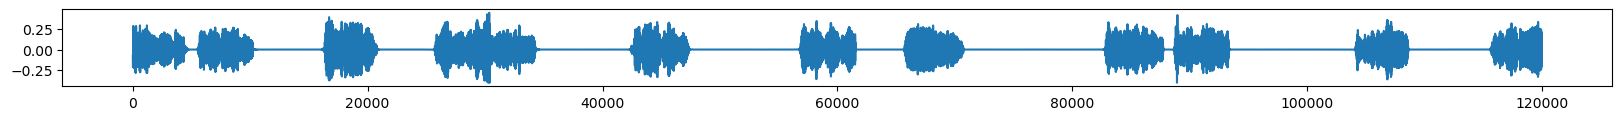

Finished epoch number 116 with a total of 10000 debug_seqs
 time: 2025-10-25 17:51:48.100400, epoch 117,  Loss: 0.2080
  Quantizer 0 Loss: 2.1643
  Quantizer 1 Loss: 2.6681
  Quantizer 2 Loss: 3.3182
  Quantizer 3 Loss: 3.7685
  Quantizer 4 Loss: 4.0792
  Quantizer 5 Loss: 4.2903
  Quantizer 6 Loss: 4.5354
  Quantizer 7 Loss: 4.6689
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


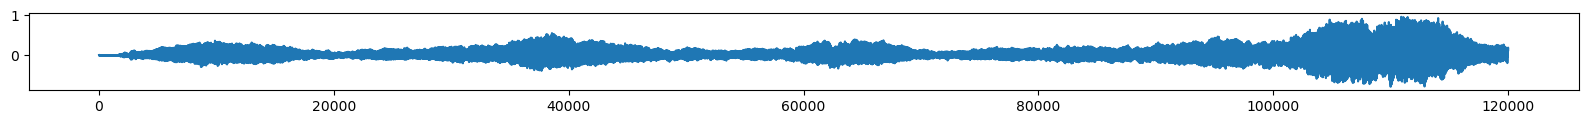

Finished epoch number 117 with a total of 10000 debug_seqs
 time: 2025-10-25 17:52:36.504904, epoch 118,  Loss: 0.2174
  Quantizer 0 Loss: 2.1633
  Quantizer 1 Loss: 2.6741
  Quantizer 2 Loss: 3.3254
  Quantizer 3 Loss: 3.7789
  Quantizer 4 Loss: 4.0872
  Quantizer 5 Loss: 4.2932
  Quantizer 6 Loss: 4.5394
  Quantizer 7 Loss: 4.6708
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


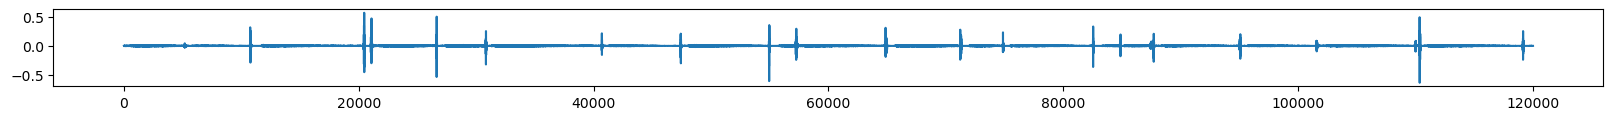

Finished epoch number 118 with a total of 10000 debug_seqs
 time: 2025-10-25 17:53:25.367378, epoch 119,  Loss: 0.2146
  Quantizer 0 Loss: 2.1557
  Quantizer 1 Loss: 2.6670
  Quantizer 2 Loss: 3.3137
  Quantizer 3 Loss: 3.7659
  Quantizer 4 Loss: 4.0789
  Quantizer 5 Loss: 4.2873
  Quantizer 6 Loss: 4.5329
  Quantizer 7 Loss: 4.6673
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


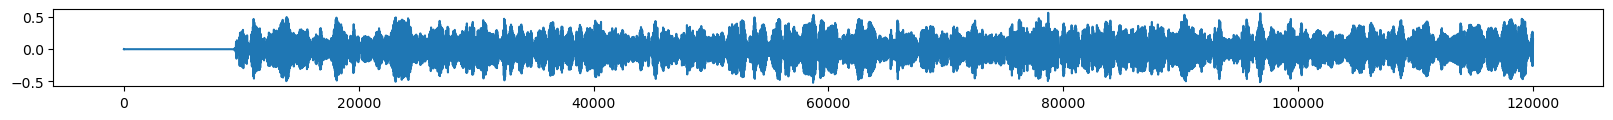

Finished epoch number 119 with a total of 10000 debug_seqs
 time: 2025-10-25 17:54:13.436890, epoch 120,  Loss: 0.2199
  Quantizer 0 Loss: 2.1554
  Quantizer 1 Loss: 2.6651
  Quantizer 2 Loss: 3.3102
  Quantizer 3 Loss: 3.7628
  Quantizer 4 Loss: 4.0854
  Quantizer 5 Loss: 4.2852
  Quantizer 6 Loss: 4.5309
  Quantizer 7 Loss: 4.6684
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


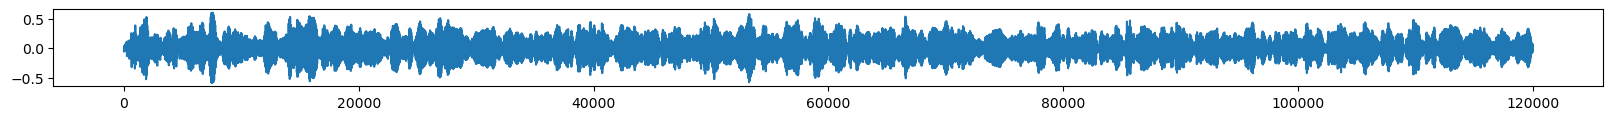

Finished epoch number 120 with a total of 10000 debug_seqs
 time: 2025-10-25 17:55:01.942984, epoch 121,  Loss: 0.2181
  Quantizer 0 Loss: 2.1621
  Quantizer 1 Loss: 2.6744
  Quantizer 2 Loss: 3.3245
  Quantizer 3 Loss: 3.7708
  Quantizer 4 Loss: 4.0871
  Quantizer 5 Loss: 4.2903
  Quantizer 6 Loss: 4.5344
  Quantizer 7 Loss: 4.6691
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


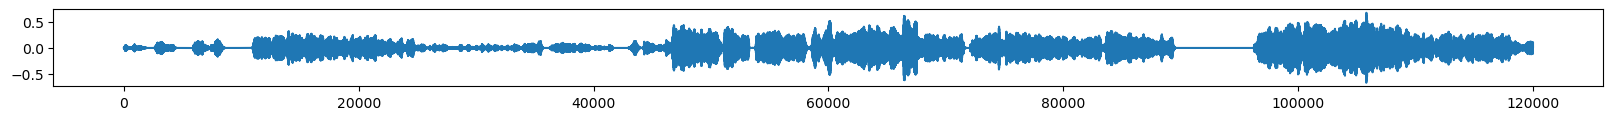

Finished epoch number 121 with a total of 10000 debug_seqs
 time: 2025-10-25 17:55:51.099223, epoch 122,  Loss: 0.2213
  Quantizer 0 Loss: 2.1653
  Quantizer 1 Loss: 2.6668
  Quantizer 2 Loss: 3.3232
  Quantizer 3 Loss: 3.7720
  Quantizer 4 Loss: 4.0903
  Quantizer 5 Loss: 4.2976
  Quantizer 6 Loss: 4.5420
  Quantizer 7 Loss: 4.6766
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


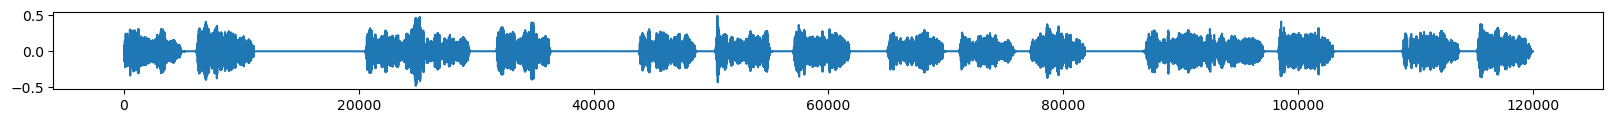

Finished epoch number 122 with a total of 10000 debug_seqs
 time: 2025-10-25 17:56:38.568985, epoch 123,  Loss: 0.2193
  Quantizer 0 Loss: 2.1739
  Quantizer 1 Loss: 2.6801
  Quantizer 2 Loss: 3.3329
  Quantizer 3 Loss: 3.7826
  Quantizer 4 Loss: 4.0979
  Quantizer 5 Loss: 4.2992
  Quantizer 6 Loss: 4.5478
  Quantizer 7 Loss: 4.6805
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


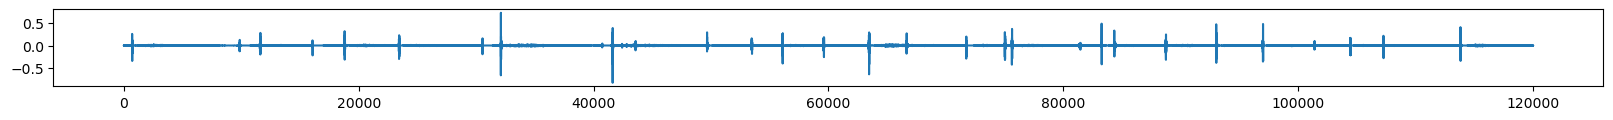

Finished epoch number 123 with a total of 10000 debug_seqs
 time: 2025-10-25 17:57:26.910322, epoch 124,  Loss: 0.2108
  Quantizer 0 Loss: 2.1545
  Quantizer 1 Loss: 2.6693
  Quantizer 2 Loss: 3.3094
  Quantizer 3 Loss: 3.7616
  Quantizer 4 Loss: 4.0830
  Quantizer 5 Loss: 4.2853
  Quantizer 6 Loss: 4.5315
  Quantizer 7 Loss: 4.6644
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


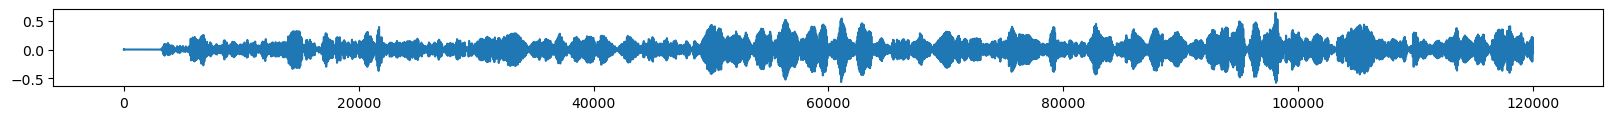

Finished epoch number 124 with a total of 10000 debug_seqs
 time: 2025-10-25 17:58:15.611395, epoch 125,  Loss: 0.2163
  Quantizer 0 Loss: 2.1639
  Quantizer 1 Loss: 2.6677
  Quantizer 2 Loss: 3.3162
  Quantizer 3 Loss: 3.7715
  Quantizer 4 Loss: 4.0860
  Quantizer 5 Loss: 4.2890
  Quantizer 6 Loss: 4.5338
  Quantizer 7 Loss: 4.6681
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


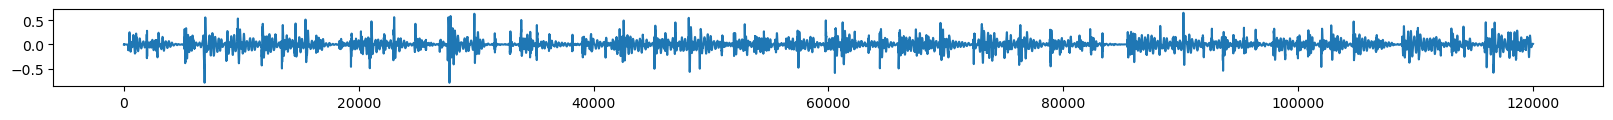

Saved checkpoint at epoch 125
Finished epoch number 125 with a total of 10000 debug_seqs
 time: 2025-10-25 17:59:04.917163, epoch 126,  Loss: 0.2486
  Quantizer 0 Loss: 2.1822
  Quantizer 1 Loss: 3.2993
  Quantizer 2 Loss: 4.1235
  Quantizer 3 Loss: 4.6326
  Quantizer 4 Loss: 4.9416
  Quantizer 5 Loss: 5.1319
  Quantizer 6 Loss: 5.3475
  Quantizer 7 Loss: 5.4377
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


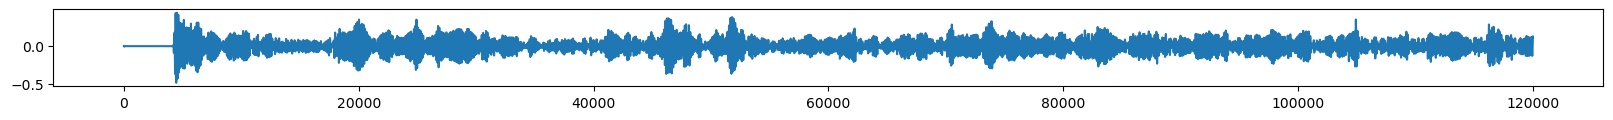

Finished epoch number 126 with a total of 10000 debug_seqs
 time: 2025-10-25 17:59:54.354883, epoch 127,  Loss: 0.2541
  Quantizer 0 Loss: 2.1809
  Quantizer 1 Loss: 3.1672
  Quantizer 2 Loss: 3.9560
  Quantizer 3 Loss: 4.4503
  Quantizer 4 Loss: 4.7725
  Quantizer 5 Loss: 4.9759
  Quantizer 6 Loss: 5.2058
  Quantizer 7 Loss: 5.3091
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


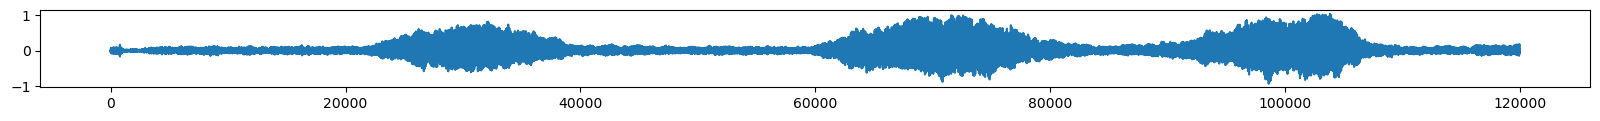

Finished epoch number 127 with a total of 10000 debug_seqs
 time: 2025-10-25 18:00:42.900828, epoch 128,  Loss: 0.2412
  Quantizer 0 Loss: 2.1675
  Quantizer 1 Loss: 3.1369
  Quantizer 2 Loss: 3.9112
  Quantizer 3 Loss: 4.3990
  Quantizer 4 Loss: 4.7216
  Quantizer 5 Loss: 4.9235
  Quantizer 6 Loss: 5.1567
  Quantizer 7 Loss: 5.2600
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


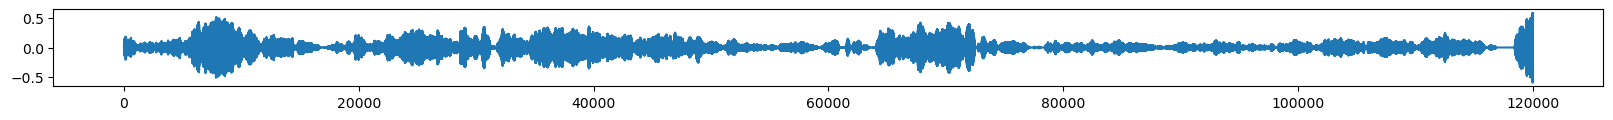

Finished epoch number 128 with a total of 10000 debug_seqs
 time: 2025-10-25 18:01:32.535417, epoch 129,  Loss: 0.2567
  Quantizer 0 Loss: 2.1648
  Quantizer 1 Loss: 3.1229
  Quantizer 2 Loss: 3.8969
  Quantizer 3 Loss: 4.3796
  Quantizer 4 Loss: 4.6963
  Quantizer 5 Loss: 4.8913
  Quantizer 6 Loss: 5.1247
  Quantizer 7 Loss: 5.2329
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


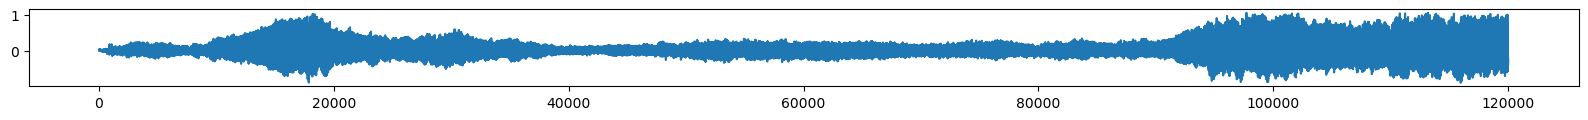

Finished epoch number 129 with a total of 10000 debug_seqs
 time: 2025-10-25 18:02:21.842036, epoch 130,  Loss: 0.2346
  Quantizer 0 Loss: 2.1613
  Quantizer 1 Loss: 3.1147
  Quantizer 2 Loss: 3.8749
  Quantizer 3 Loss: 4.3574
  Quantizer 4 Loss: 4.6743
  Quantizer 5 Loss: 4.8685
  Quantizer 6 Loss: 5.1068
  Quantizer 7 Loss: 5.2140
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


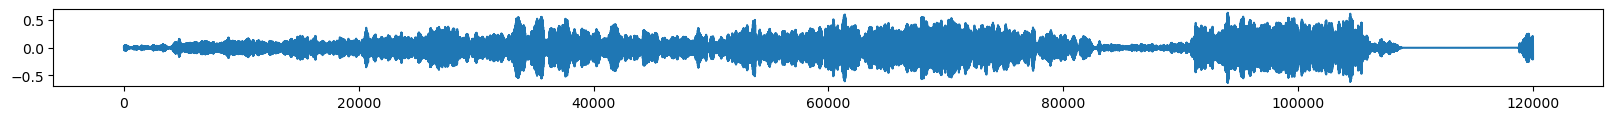

Finished epoch number 130 with a total of 10000 debug_seqs
 time: 2025-10-25 18:03:09.419144, epoch 131,  Loss: 0.2379
  Quantizer 0 Loss: 2.1654
  Quantizer 1 Loss: 3.1085
  Quantizer 2 Loss: 3.8717
  Quantizer 3 Loss: 4.3498
  Quantizer 4 Loss: 4.6671
  Quantizer 5 Loss: 4.8587
  Quantizer 6 Loss: 5.0890
  Quantizer 7 Loss: 5.1984
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


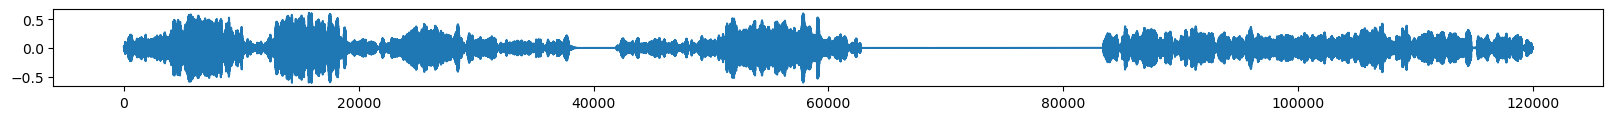

Finished epoch number 131 with a total of 10000 debug_seqs
 time: 2025-10-25 18:03:57.244886, epoch 132,  Loss: 0.2429
  Quantizer 0 Loss: 2.1531
  Quantizer 1 Loss: 3.1021
  Quantizer 2 Loss: 3.8580
  Quantizer 3 Loss: 4.3360
  Quantizer 4 Loss: 4.6556
  Quantizer 5 Loss: 4.8490
  Quantizer 6 Loss: 5.0833
  Quantizer 7 Loss: 5.1870
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


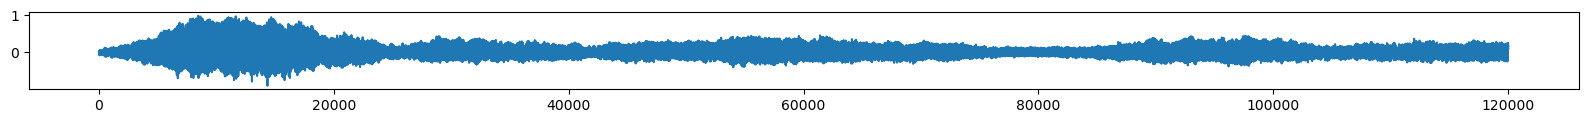

Finished epoch number 132 with a total of 10000 debug_seqs
 time: 2025-10-25 18:04:46.132841, epoch 133,  Loss: 0.2396
  Quantizer 0 Loss: 2.1655
  Quantizer 1 Loss: 3.1100
  Quantizer 2 Loss: 3.8671
  Quantizer 3 Loss: 4.3417
  Quantizer 4 Loss: 4.6522
  Quantizer 5 Loss: 4.8517
  Quantizer 6 Loss: 5.0886
  Quantizer 7 Loss: 5.1888
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


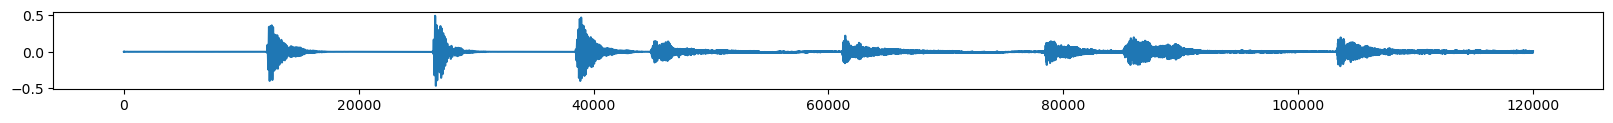

Finished epoch number 133 with a total of 10000 debug_seqs
 time: 2025-10-25 18:05:34.750989, epoch 134,  Loss: 0.2447
  Quantizer 0 Loss: 2.1520
  Quantizer 1 Loss: 3.0908
  Quantizer 2 Loss: 3.8592
  Quantizer 3 Loss: 4.3356
  Quantizer 4 Loss: 4.6449
  Quantizer 5 Loss: 4.8395
  Quantizer 6 Loss: 5.0761
  Quantizer 7 Loss: 5.1802
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


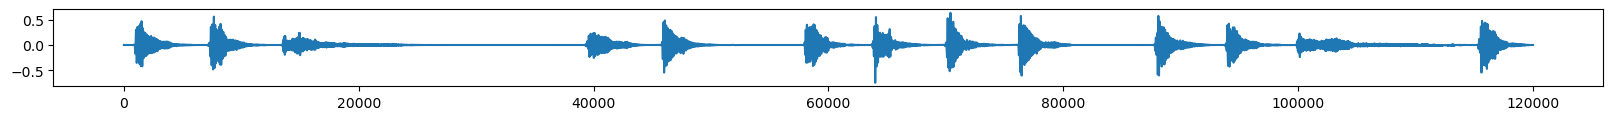

Finished epoch number 134 with a total of 10000 debug_seqs
 time: 2025-10-25 18:06:24.116737, epoch 135,  Loss: 0.2481
  Quantizer 0 Loss: 2.1501
  Quantizer 1 Loss: 3.0907
  Quantizer 2 Loss: 3.8468
  Quantizer 3 Loss: 4.3265
  Quantizer 4 Loss: 4.6353
  Quantizer 5 Loss: 4.8316
  Quantizer 6 Loss: 5.0664
  Quantizer 7 Loss: 5.1713
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


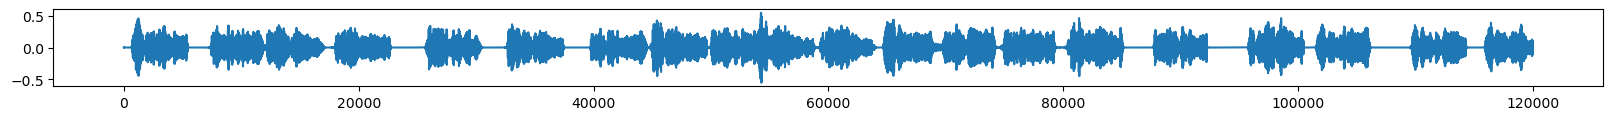

Finished epoch number 135 with a total of 10000 debug_seqs
 time: 2025-10-25 18:07:13.912914, epoch 136,  Loss: 0.2425
  Quantizer 0 Loss: 2.1646
  Quantizer 1 Loss: 3.1119
  Quantizer 2 Loss: 3.8662
  Quantizer 3 Loss: 4.3447
  Quantizer 4 Loss: 4.6544
  Quantizer 5 Loss: 4.8534
  Quantizer 6 Loss: 5.0825
  Quantizer 7 Loss: 5.1847
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


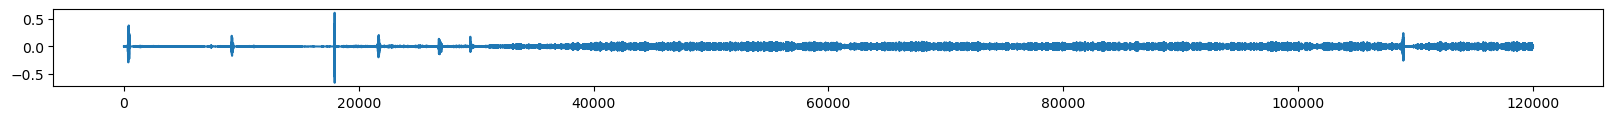

Finished epoch number 136 with a total of 10000 debug_seqs
 time: 2025-10-25 18:08:02.034639, epoch 137,  Loss: 0.2455
  Quantizer 0 Loss: 2.1449
  Quantizer 1 Loss: 3.0921
  Quantizer 2 Loss: 3.8431
  Quantizer 3 Loss: 4.3172
  Quantizer 4 Loss: 4.6326
  Quantizer 5 Loss: 4.8321
  Quantizer 6 Loss: 5.0575
  Quantizer 7 Loss: 5.1636
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


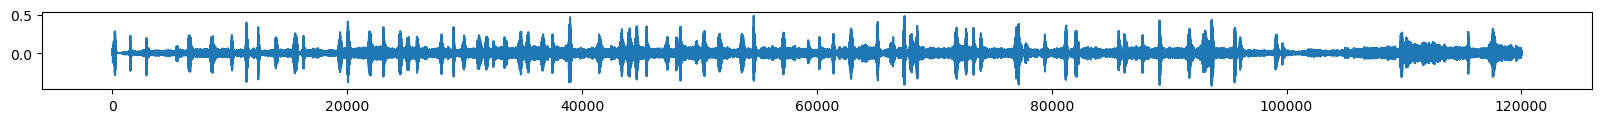

Finished epoch number 137 with a total of 10000 debug_seqs
 time: 2025-10-25 18:08:50.794014, epoch 138,  Loss: 0.2432
  Quantizer 0 Loss: 2.1503
  Quantizer 1 Loss: 3.0843
  Quantizer 2 Loss: 3.8417
  Quantizer 3 Loss: 4.3176
  Quantizer 4 Loss: 4.6275
  Quantizer 5 Loss: 4.8208
  Quantizer 6 Loss: 5.0486
  Quantizer 7 Loss: 5.1565
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


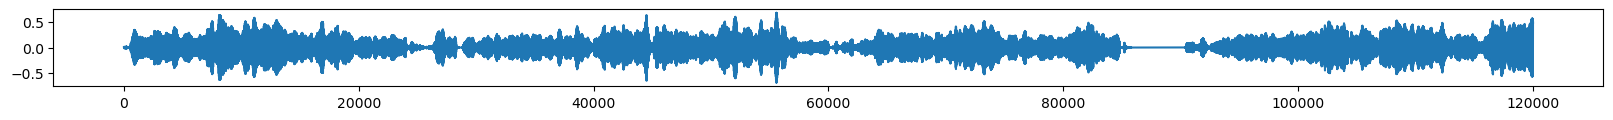

Finished epoch number 138 with a total of 10000 debug_seqs
 time: 2025-10-25 18:09:38.255767, epoch 139,  Loss: 0.2481
  Quantizer 0 Loss: 2.1604
  Quantizer 1 Loss: 3.0946
  Quantizer 2 Loss: 3.8521
  Quantizer 3 Loss: 4.3247
  Quantizer 4 Loss: 4.6313
  Quantizer 5 Loss: 4.8334
  Quantizer 6 Loss: 5.0582
  Quantizer 7 Loss: 5.1670
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


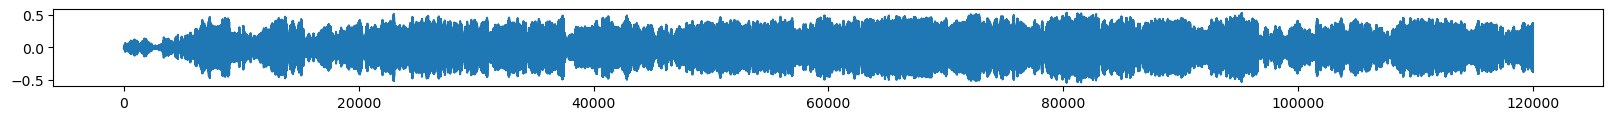

Finished epoch number 139 with a total of 10000 debug_seqs
 time: 2025-10-25 18:10:26.903301, epoch 140,  Loss: 0.2482
  Quantizer 0 Loss: 2.1566
  Quantizer 1 Loss: 3.0940
  Quantizer 2 Loss: 3.8516
  Quantizer 3 Loss: 4.3234
  Quantizer 4 Loss: 4.6306
  Quantizer 5 Loss: 4.8265
  Quantizer 6 Loss: 5.0567
  Quantizer 7 Loss: 5.1623
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


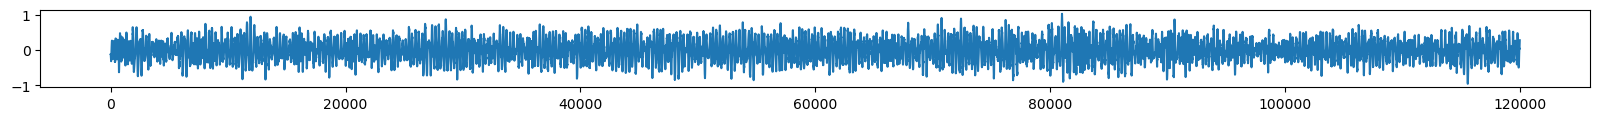

Finished epoch number 140 with a total of 10000 debug_seqs
 time: 2025-10-25 18:11:15.811764, epoch 141,  Loss: 0.2450
  Quantizer 0 Loss: 2.1672
  Quantizer 1 Loss: 3.1040
  Quantizer 2 Loss: 3.8622
  Quantizer 3 Loss: 4.3348
  Quantizer 4 Loss: 4.6423
  Quantizer 5 Loss: 4.8431
  Quantizer 6 Loss: 5.0703
  Quantizer 7 Loss: 5.1747
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


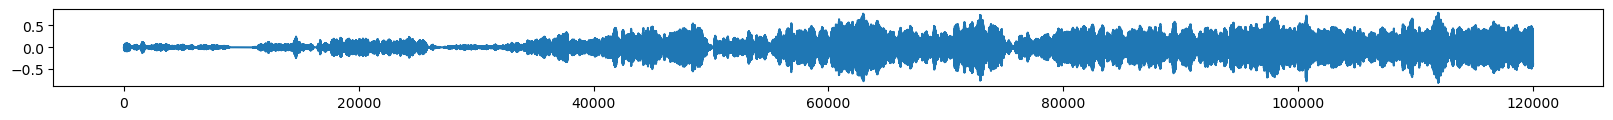

Finished epoch number 141 with a total of 10000 debug_seqs
 time: 2025-10-25 18:12:04.194400, epoch 142,  Loss: 0.2514
  Quantizer 0 Loss: 2.1529
  Quantizer 1 Loss: 3.0891
  Quantizer 2 Loss: 3.8499
  Quantizer 3 Loss: 4.3235
  Quantizer 4 Loss: 4.6339
  Quantizer 5 Loss: 4.8242
  Quantizer 6 Loss: 5.0573
  Quantizer 7 Loss: 5.1616
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


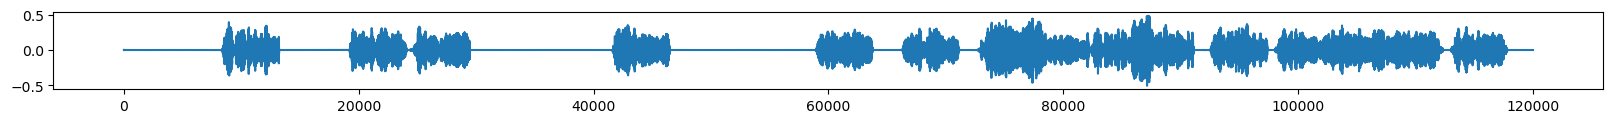

Finished epoch number 142 with a total of 10000 debug_seqs
 time: 2025-10-25 18:12:53.187555, epoch 143,  Loss: 0.2512
  Quantizer 0 Loss: 2.1498
  Quantizer 1 Loss: 3.0806
  Quantizer 2 Loss: 3.8395
  Quantizer 3 Loss: 4.3058
  Quantizer 4 Loss: 4.6217
  Quantizer 5 Loss: 4.8187
  Quantizer 6 Loss: 5.0467
  Quantizer 7 Loss: 5.1490
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


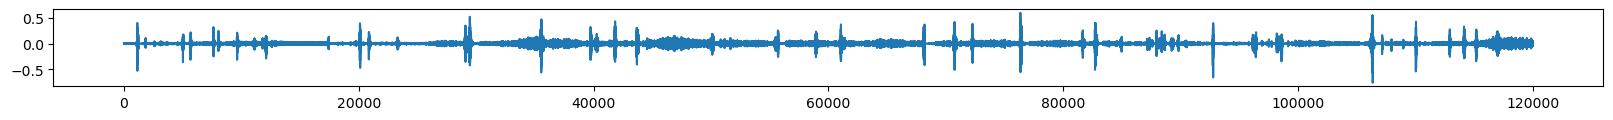

Finished epoch number 143 with a total of 10000 debug_seqs
 time: 2025-10-25 18:13:41.577411, epoch 144,  Loss: 0.2491
  Quantizer 0 Loss: 2.1604
  Quantizer 1 Loss: 3.0896
  Quantizer 2 Loss: 3.8539
  Quantizer 3 Loss: 4.3272
  Quantizer 4 Loss: 4.6354
  Quantizer 5 Loss: 4.8313
  Quantizer 6 Loss: 5.0593
  Quantizer 7 Loss: 5.1644
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


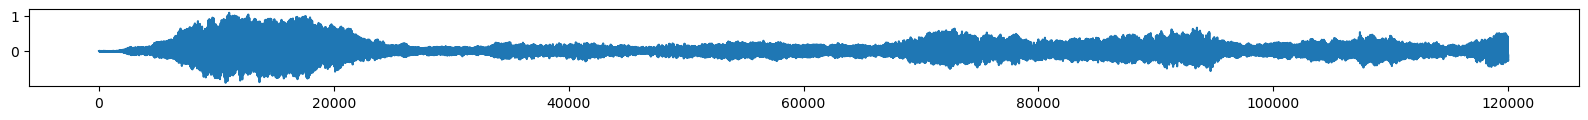

Finished epoch number 144 with a total of 10000 debug_seqs
 time: 2025-10-25 18:14:29.922229, epoch 145,  Loss: 0.2453
  Quantizer 0 Loss: 2.1528
  Quantizer 1 Loss: 3.0812
  Quantizer 2 Loss: 3.8400
  Quantizer 3 Loss: 4.3129
  Quantizer 4 Loss: 4.6239
  Quantizer 5 Loss: 4.8210
  Quantizer 6 Loss: 5.0493
  Quantizer 7 Loss: 5.1561
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


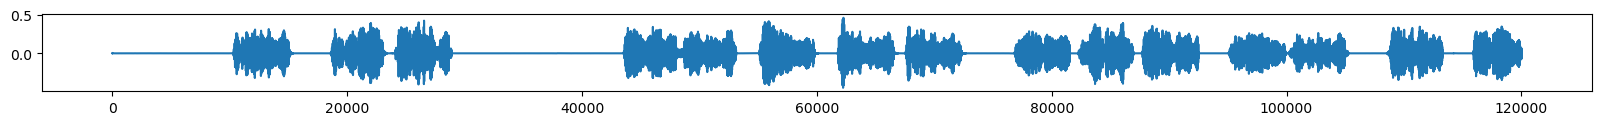

Finished epoch number 145 with a total of 10000 debug_seqs
 time: 2025-10-25 18:15:18.519435, epoch 146,  Loss: 0.2389
  Quantizer 0 Loss: 2.1536
  Quantizer 1 Loss: 3.0803
  Quantizer 2 Loss: 3.8386
  Quantizer 3 Loss: 4.3155
  Quantizer 4 Loss: 4.6267
  Quantizer 5 Loss: 4.8177
  Quantizer 6 Loss: 5.0491
  Quantizer 7 Loss: 5.1551
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


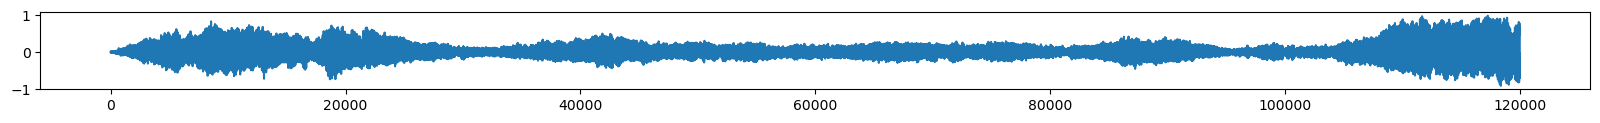

Finished epoch number 146 with a total of 10000 debug_seqs
 time: 2025-10-25 18:16:05.483480, epoch 147,  Loss: 0.2446
  Quantizer 0 Loss: 2.1592
  Quantizer 1 Loss: 3.0837
  Quantizer 2 Loss: 3.8412
  Quantizer 3 Loss: 4.3174
  Quantizer 4 Loss: 4.6181
  Quantizer 5 Loss: 4.8143
  Quantizer 6 Loss: 5.0462
  Quantizer 7 Loss: 5.1476
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


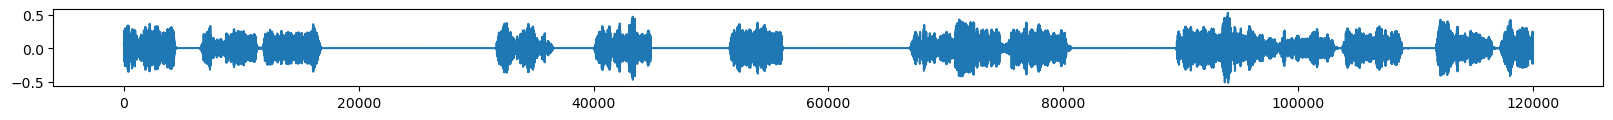

Finished epoch number 147 with a total of 10000 debug_seqs
 time: 2025-10-25 18:16:53.986881, epoch 148,  Loss: 0.2383
  Quantizer 0 Loss: 2.1516
  Quantizer 1 Loss: 3.0826
  Quantizer 2 Loss: 3.8390
  Quantizer 3 Loss: 4.3150
  Quantizer 4 Loss: 4.6259
  Quantizer 5 Loss: 4.8147
  Quantizer 6 Loss: 5.0552
  Quantizer 7 Loss: 5.1556
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


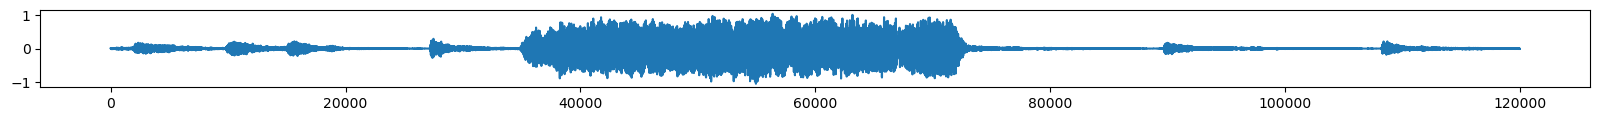

Finished epoch number 148 with a total of 10000 debug_seqs
 time: 2025-10-25 18:17:41.246616, epoch 149,  Loss: 0.2545
  Quantizer 0 Loss: 2.1517
  Quantizer 1 Loss: 3.0888
  Quantizer 2 Loss: 3.8467
  Quantizer 3 Loss: 4.3237
  Quantizer 4 Loss: 4.6337
  Quantizer 5 Loss: 4.8288
  Quantizer 6 Loss: 5.0570
  Quantizer 7 Loss: 5.1603
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


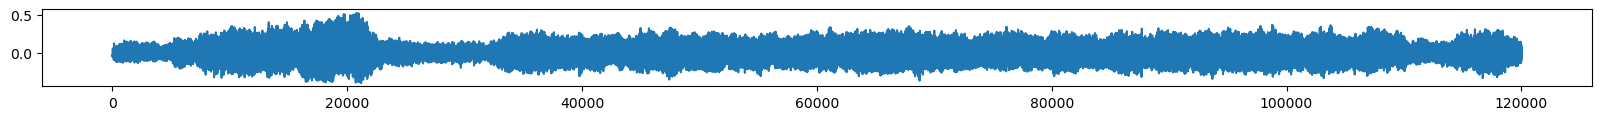

Finished epoch number 149 with a total of 10000 debug_seqs
 time: 2025-10-25 18:18:29.777995, epoch 150,  Loss: 0.2374
  Quantizer 0 Loss: 2.1454
  Quantizer 1 Loss: 3.0855
  Quantizer 2 Loss: 3.8417
  Quantizer 3 Loss: 4.3156
  Quantizer 4 Loss: 4.6314
  Quantizer 5 Loss: 4.8280
  Quantizer 6 Loss: 5.0592
  Quantizer 7 Loss: 5.1686
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


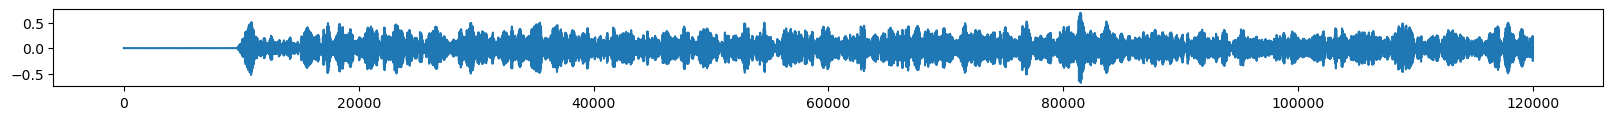

Saved checkpoint at epoch 150
Finished epoch number 150 with a total of 10000 debug_seqs
 time: 2025-10-25 18:19:18.005520, epoch 151,  Loss: 0.2255
  Quantizer 0 Loss: 2.1552
  Quantizer 1 Loss: 2.7809
  Quantizer 2 Loss: 3.5113
  Quantizer 3 Loss: 4.0071
  Quantizer 4 Loss: 4.3417
  Quantizer 5 Loss: 4.5595
  Quantizer 6 Loss: 4.8042
  Quantizer 7 Loss: 4.9400
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


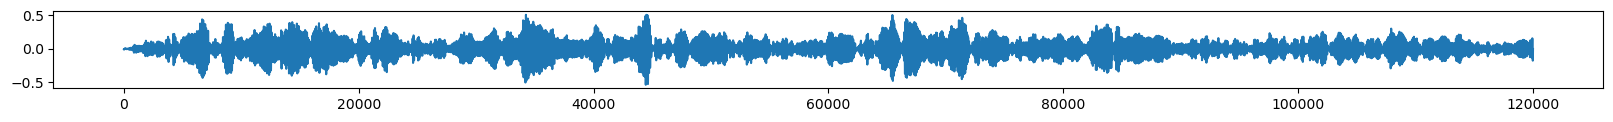

Finished epoch number 151 with a total of 10000 debug_seqs
 time: 2025-10-25 18:20:05.583690, epoch 152,  Loss: 0.2172
  Quantizer 0 Loss: 2.1443
  Quantizer 1 Loss: 2.6934
  Quantizer 2 Loss: 3.3827
  Quantizer 3 Loss: 3.8627
  Quantizer 4 Loss: 4.1949
  Quantizer 5 Loss: 4.4168
  Quantizer 6 Loss: 4.6616
  Quantizer 7 Loss: 4.7994
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


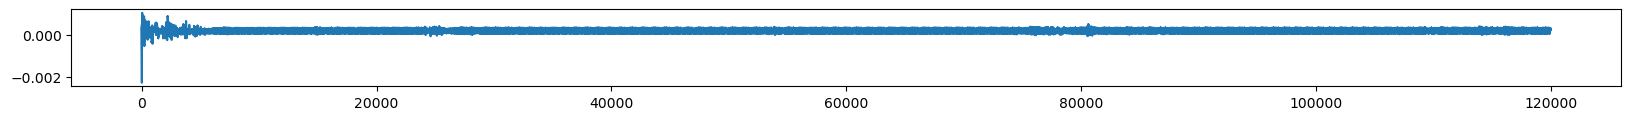

Finished epoch number 152 with a total of 10000 debug_seqs
 time: 2025-10-25 18:20:53.180695, epoch 153,  Loss: 0.2170
  Quantizer 0 Loss: 2.1584
  Quantizer 1 Loss: 2.7007
  Quantizer 2 Loss: 3.3770
  Quantizer 3 Loss: 3.8421
  Quantizer 4 Loss: 4.1754
  Quantizer 5 Loss: 4.3887
  Quantizer 6 Loss: 4.6377
  Quantizer 7 Loss: 4.7759
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


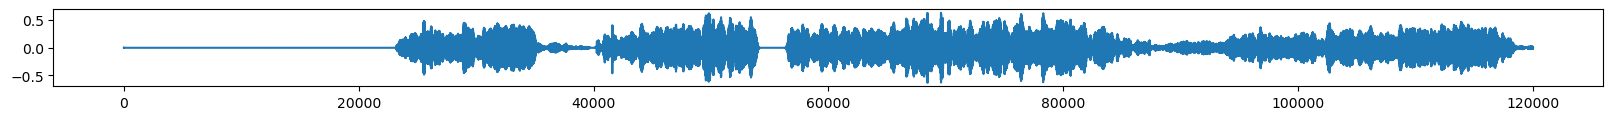

Finished epoch number 153 with a total of 10000 debug_seqs
 time: 2025-10-25 18:21:40.519004, epoch 154,  Loss: 0.2150
  Quantizer 0 Loss: 2.1391
  Quantizer 1 Loss: 2.6647
  Quantizer 2 Loss: 3.3288
  Quantizer 3 Loss: 3.7982
  Quantizer 4 Loss: 4.1231
  Quantizer 5 Loss: 4.3336
  Quantizer 6 Loss: 4.5795
  Quantizer 7 Loss: 4.7189
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


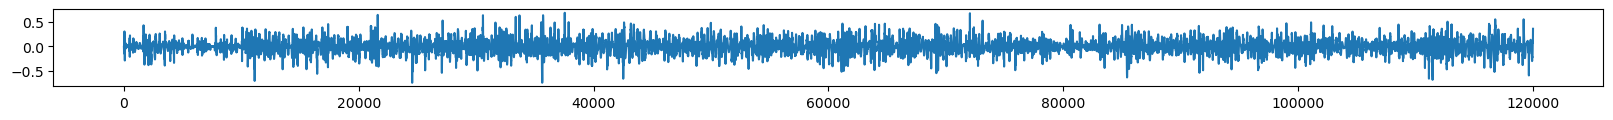

Finished epoch number 154 with a total of 10000 debug_seqs
 time: 2025-10-25 18:22:27.697484, epoch 155,  Loss: 0.2272
  Quantizer 0 Loss: 2.1506
  Quantizer 1 Loss: 2.6761
  Quantizer 2 Loss: 3.3381
  Quantizer 3 Loss: 3.8002
  Quantizer 4 Loss: 4.1241
  Quantizer 5 Loss: 4.3335
  Quantizer 6 Loss: 4.5849
  Quantizer 7 Loss: 4.7181
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


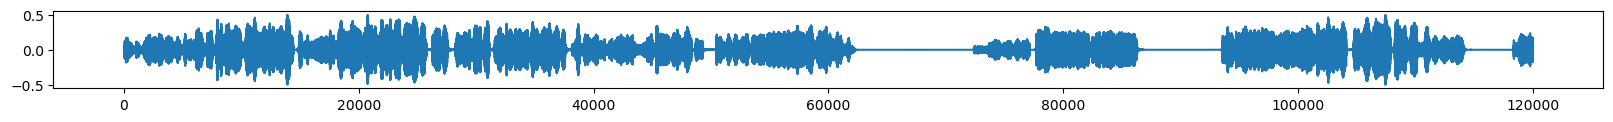

Finished epoch number 155 with a total of 10000 debug_seqs
 time: 2025-10-25 18:23:15.484832, epoch 156,  Loss: 0.2199
  Quantizer 0 Loss: 2.1483
  Quantizer 1 Loss: 2.6707
  Quantizer 2 Loss: 3.3282
  Quantizer 3 Loss: 3.7928
  Quantizer 4 Loss: 4.1141
  Quantizer 5 Loss: 4.3195
  Quantizer 6 Loss: 4.5727
  Quantizer 7 Loss: 4.7006
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


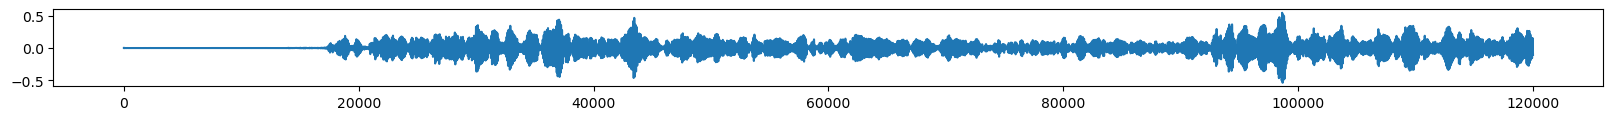

Finished epoch number 156 with a total of 10000 debug_seqs
 time: 2025-10-25 18:24:02.982341, epoch 157,  Loss: 0.2108
  Quantizer 0 Loss: 2.1613
  Quantizer 1 Loss: 2.6822
  Quantizer 2 Loss: 3.3404
  Quantizer 3 Loss: 3.8019
  Quantizer 4 Loss: 4.1204
  Quantizer 5 Loss: 4.3299
  Quantizer 6 Loss: 4.5778
  Quantizer 7 Loss: 4.7092
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


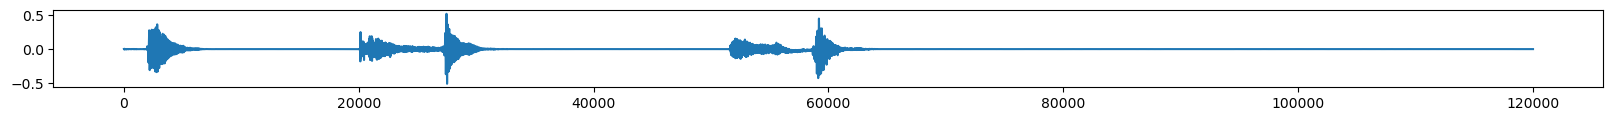

Finished epoch number 157 with a total of 10000 debug_seqs
 time: 2025-10-25 18:24:49.842018, epoch 158,  Loss: 0.2192
  Quantizer 0 Loss: 2.1465
  Quantizer 1 Loss: 2.6672
  Quantizer 2 Loss: 3.3220
  Quantizer 3 Loss: 3.7761
  Quantizer 4 Loss: 4.0985
  Quantizer 5 Loss: 4.3057
  Quantizer 6 Loss: 4.5545
  Quantizer 7 Loss: 4.6924
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


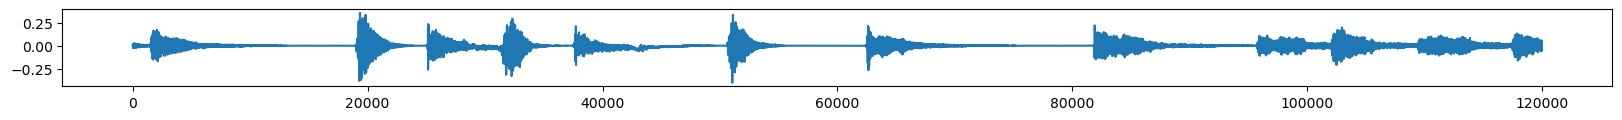

Finished epoch number 158 with a total of 10000 debug_seqs
 time: 2025-10-25 18:25:36.795865, epoch 159,  Loss: 0.2160
  Quantizer 0 Loss: 2.1510
  Quantizer 1 Loss: 2.6633
  Quantizer 2 Loss: 3.3168
  Quantizer 3 Loss: 3.7737
  Quantizer 4 Loss: 4.0880
  Quantizer 5 Loss: 4.2964
  Quantizer 6 Loss: 4.5386
  Quantizer 7 Loss: 4.6747
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


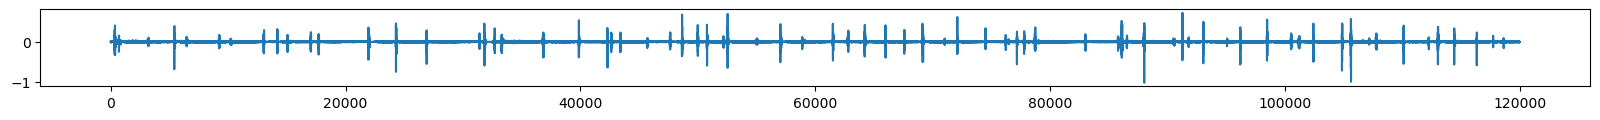

Finished epoch number 159 with a total of 10000 debug_seqs
 time: 2025-10-25 18:26:24.874223, epoch 160,  Loss: 0.2150
  Quantizer 0 Loss: 2.1513
  Quantizer 1 Loss: 2.6573
  Quantizer 2 Loss: 3.3222
  Quantizer 3 Loss: 3.7757
  Quantizer 4 Loss: 4.0907
  Quantizer 5 Loss: 4.2950
  Quantizer 6 Loss: 4.5409
  Quantizer 7 Loss: 4.6777
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


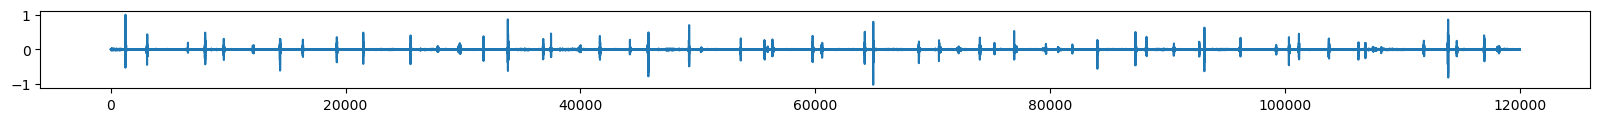

Finished epoch number 160 with a total of 10000 debug_seqs
 time: 2025-10-25 18:27:11.796847, epoch 161,  Loss: 0.2122
  Quantizer 0 Loss: 2.1488
  Quantizer 1 Loss: 2.6632
  Quantizer 2 Loss: 3.3147
  Quantizer 3 Loss: 3.7691
  Quantizer 4 Loss: 4.0817
  Quantizer 5 Loss: 4.2913
  Quantizer 6 Loss: 4.5352
  Quantizer 7 Loss: 4.6738
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


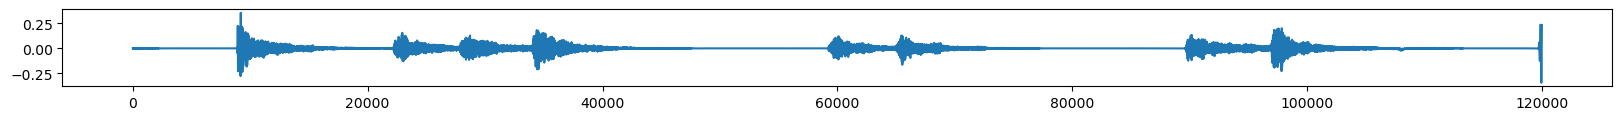

Finished epoch number 161 with a total of 10000 debug_seqs
 time: 2025-10-25 18:27:59.728243, epoch 162,  Loss: 0.2094
  Quantizer 0 Loss: 2.1545
  Quantizer 1 Loss: 2.6590
  Quantizer 2 Loss: 3.3139
  Quantizer 3 Loss: 3.7709
  Quantizer 4 Loss: 4.0860
  Quantizer 5 Loss: 4.2914
  Quantizer 6 Loss: 4.5339
  Quantizer 7 Loss: 4.6695
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


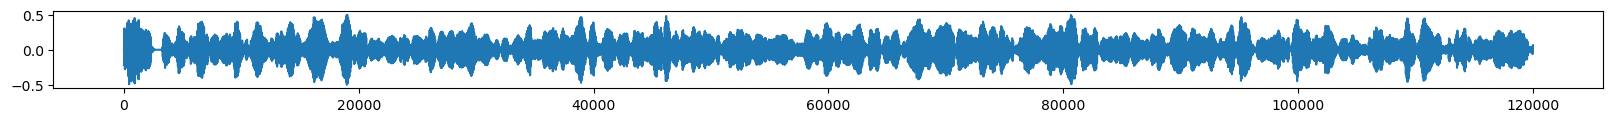

Finished epoch number 162 with a total of 10000 debug_seqs
 time: 2025-10-25 18:28:46.858116, epoch 163,  Loss: 0.2186
  Quantizer 0 Loss: 2.1527
  Quantizer 1 Loss: 2.6683
  Quantizer 2 Loss: 3.3168
  Quantizer 3 Loss: 3.7710
  Quantizer 4 Loss: 4.0860
  Quantizer 5 Loss: 4.2958
  Quantizer 6 Loss: 4.5439
  Quantizer 7 Loss: 4.6751
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


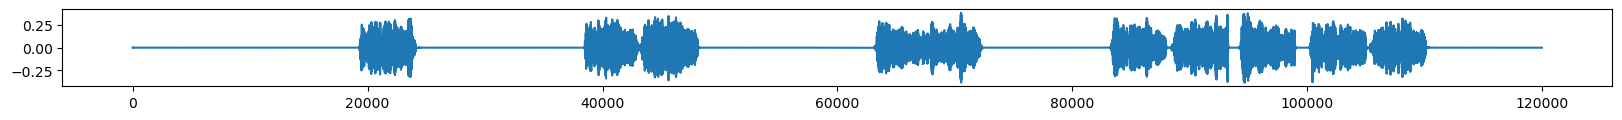

Finished epoch number 163 with a total of 10000 debug_seqs
 time: 2025-10-25 18:29:33.531090, epoch 164,  Loss: 0.2214
  Quantizer 0 Loss: 2.1593
  Quantizer 1 Loss: 2.6618
  Quantizer 2 Loss: 3.3179
  Quantizer 3 Loss: 3.7665
  Quantizer 4 Loss: 4.0842
  Quantizer 5 Loss: 4.2878
  Quantizer 6 Loss: 4.5318
  Quantizer 7 Loss: 4.6647
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


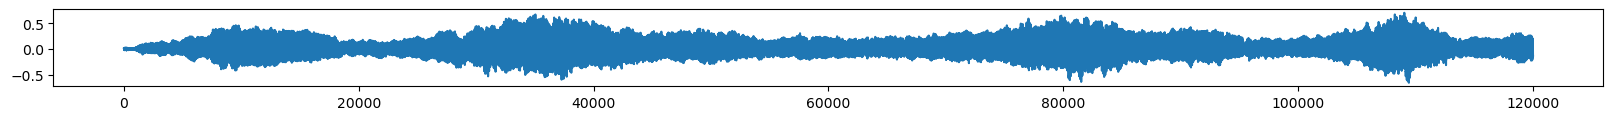

Finished epoch number 164 with a total of 10000 debug_seqs
 time: 2025-10-25 18:30:20.847328, epoch 165,  Loss: 0.2159
  Quantizer 0 Loss: 2.1503
  Quantizer 1 Loss: 2.6612
  Quantizer 2 Loss: 3.3110
  Quantizer 3 Loss: 3.7588
  Quantizer 4 Loss: 4.0787
  Quantizer 5 Loss: 4.2893
  Quantizer 6 Loss: 4.5349
  Quantizer 7 Loss: 4.6680
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


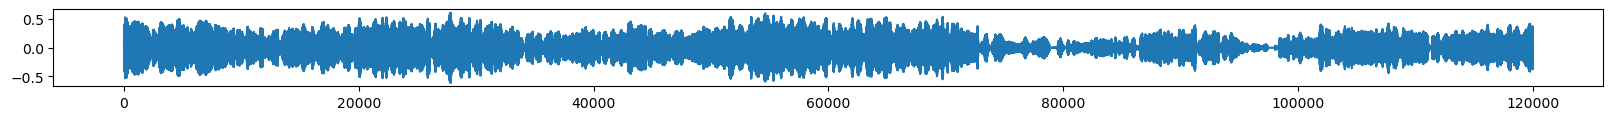

Finished epoch number 165 with a total of 10000 debug_seqs
 time: 2025-10-25 18:31:08.364380, epoch 166,  Loss: 0.2265
  Quantizer 0 Loss: 2.1631
  Quantizer 1 Loss: 2.6653
  Quantizer 2 Loss: 3.3142
  Quantizer 3 Loss: 3.7694
  Quantizer 4 Loss: 4.0828
  Quantizer 5 Loss: 4.2855
  Quantizer 6 Loss: 4.5375
  Quantizer 7 Loss: 4.6680
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


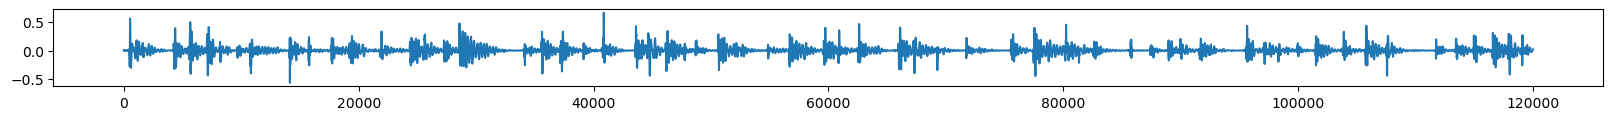

Finished epoch number 166 with a total of 10000 debug_seqs
 time: 2025-10-25 18:31:56.799776, epoch 167,  Loss: 0.2187
  Quantizer 0 Loss: 2.1565
  Quantizer 1 Loss: 2.6753
  Quantizer 2 Loss: 3.3216
  Quantizer 3 Loss: 3.7774
  Quantizer 4 Loss: 4.0940
  Quantizer 5 Loss: 4.3048
  Quantizer 6 Loss: 4.5560
  Quantizer 7 Loss: 4.6865
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


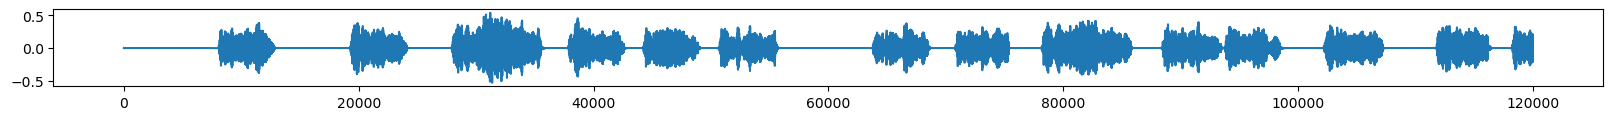

Finished epoch number 167 with a total of 10000 debug_seqs
 time: 2025-10-25 18:32:44.161165, epoch 168,  Loss: 0.2131
  Quantizer 0 Loss: 2.1439
  Quantizer 1 Loss: 2.6422
  Quantizer 2 Loss: 3.2918
  Quantizer 3 Loss: 3.7428
  Quantizer 4 Loss: 4.0560
  Quantizer 5 Loss: 4.2607
  Quantizer 6 Loss: 4.5066
  Quantizer 7 Loss: 4.6432
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


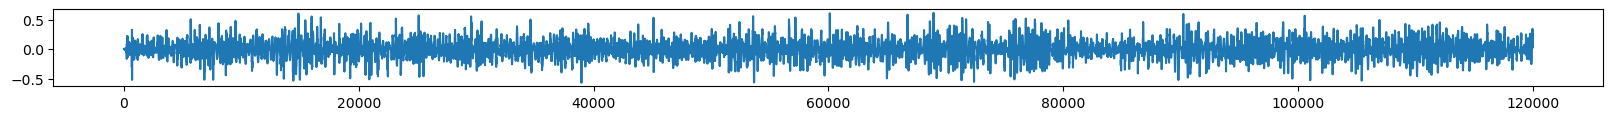

Finished epoch number 168 with a total of 10000 debug_seqs
 time: 2025-10-25 18:33:31.539836, epoch 169,  Loss: 0.2211
  Quantizer 0 Loss: 2.1477
  Quantizer 1 Loss: 2.6554
  Quantizer 2 Loss: 3.3037
  Quantizer 3 Loss: 3.7559
  Quantizer 4 Loss: 4.0712
  Quantizer 5 Loss: 4.2766
  Quantizer 6 Loss: 4.5201
  Quantizer 7 Loss: 4.6557
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


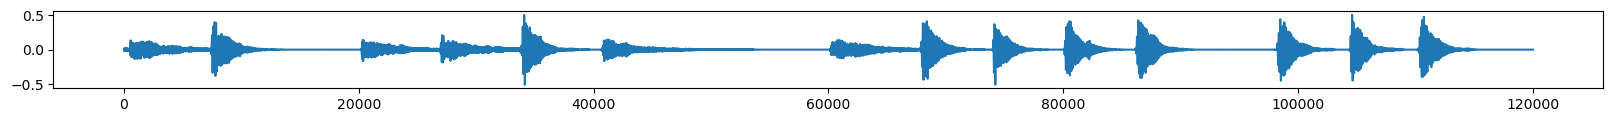

Finished epoch number 169 with a total of 10000 debug_seqs
 time: 2025-10-25 18:34:18.104584, epoch 170,  Loss: 0.2121
  Quantizer 0 Loss: 2.1538
  Quantizer 1 Loss: 2.6563
  Quantizer 2 Loss: 3.3119
  Quantizer 3 Loss: 3.7638
  Quantizer 4 Loss: 4.0789
  Quantizer 5 Loss: 4.2870
  Quantizer 6 Loss: 4.5343
  Quantizer 7 Loss: 4.6701
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


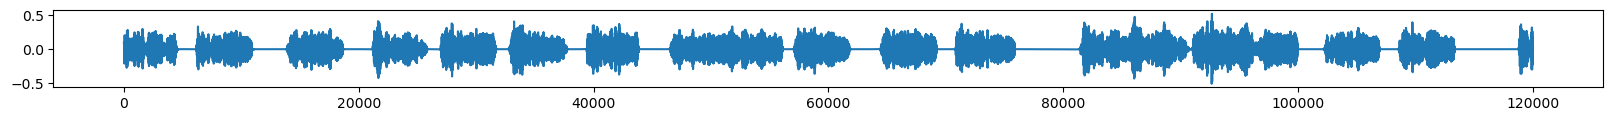

Finished epoch number 170 with a total of 10000 debug_seqs
 time: 2025-10-25 18:35:05.181177, epoch 171,  Loss: 0.2169
  Quantizer 0 Loss: 2.1489
  Quantizer 1 Loss: 2.6552
  Quantizer 2 Loss: 3.3096
  Quantizer 3 Loss: 3.7579
  Quantizer 4 Loss: 4.0750
  Quantizer 5 Loss: 4.2832
  Quantizer 6 Loss: 4.5279
  Quantizer 7 Loss: 4.6669
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


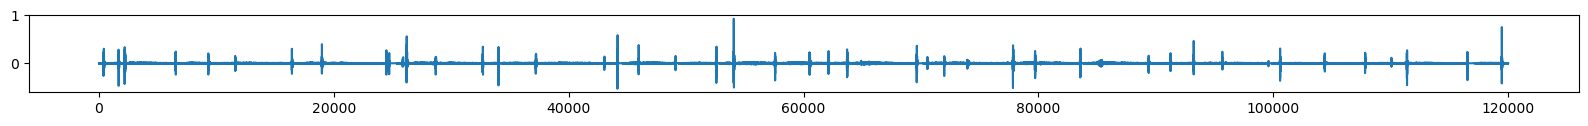

Finished epoch number 171 with a total of 10000 debug_seqs
 time: 2025-10-25 18:35:51.889535, epoch 172,  Loss: 0.2120
  Quantizer 0 Loss: 2.1507
  Quantizer 1 Loss: 2.6491
  Quantizer 2 Loss: 3.3030
  Quantizer 3 Loss: 3.7509
  Quantizer 4 Loss: 4.0639
  Quantizer 5 Loss: 4.2708
  Quantizer 6 Loss: 4.5128
  Quantizer 7 Loss: 4.6513
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


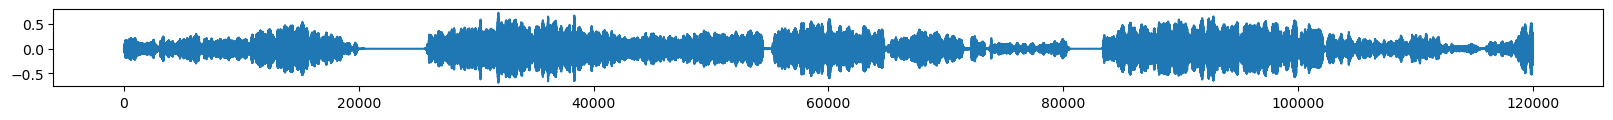

Finished epoch number 172 with a total of 10000 debug_seqs
 time: 2025-10-25 18:36:38.708622, epoch 173,  Loss: 0.2119
  Quantizer 0 Loss: 2.1406
  Quantizer 1 Loss: 2.6423
  Quantizer 2 Loss: 3.2887
  Quantizer 3 Loss: 3.7417
  Quantizer 4 Loss: 4.0547
  Quantizer 5 Loss: 4.2627
  Quantizer 6 Loss: 4.5033
  Quantizer 7 Loss: 4.6409
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


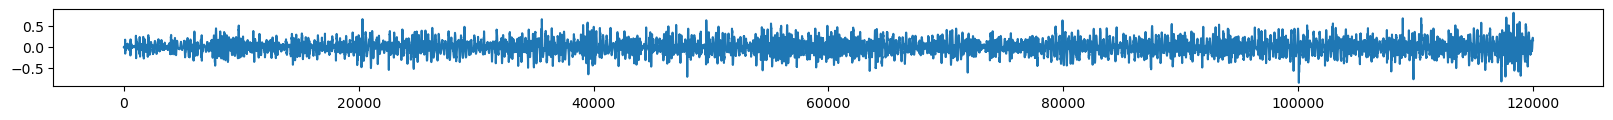

Finished epoch number 173 with a total of 10000 debug_seqs
 time: 2025-10-25 18:37:25.416828, epoch 174,  Loss: 0.2167
  Quantizer 0 Loss: 2.1498
  Quantizer 1 Loss: 2.6527
  Quantizer 2 Loss: 3.3042
  Quantizer 3 Loss: 3.7541
  Quantizer 4 Loss: 4.0718
  Quantizer 5 Loss: 4.2774
  Quantizer 6 Loss: 4.5248
  Quantizer 7 Loss: 4.6601
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


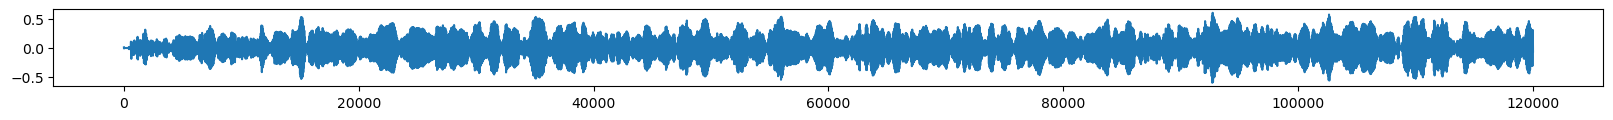

Finished epoch number 174 with a total of 10000 debug_seqs
 time: 2025-10-25 18:38:12.237067, epoch 175,  Loss: 0.2038
  Quantizer 0 Loss: 2.1546
  Quantizer 1 Loss: 2.6538
  Quantizer 2 Loss: 3.3093
  Quantizer 3 Loss: 3.7597
  Quantizer 4 Loss: 4.0739
  Quantizer 5 Loss: 4.2837
  Quantizer 6 Loss: 4.5312
  Quantizer 7 Loss: 4.6619
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


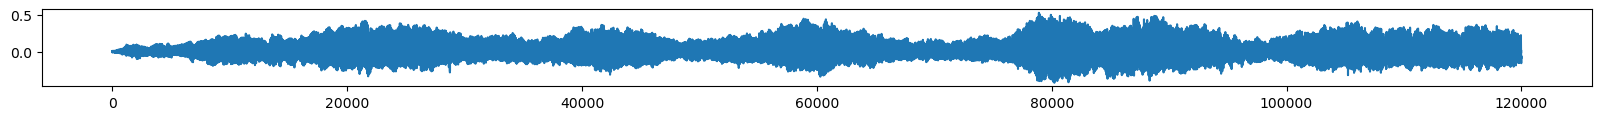

Saved checkpoint at epoch 175
Finished epoch number 175 with a total of 10000 debug_seqs
 time: 2025-10-25 18:38:59.181142, epoch 176,  Loss: 0.2538
  Quantizer 0 Loss: 2.1629
  Quantizer 1 Loss: 3.2738
  Quantizer 2 Loss: 4.0979
  Quantizer 3 Loss: 4.6109
  Quantizer 4 Loss: 4.9232
  Quantizer 5 Loss: 5.1137
  Quantizer 6 Loss: 5.3344
  Quantizer 7 Loss: 5.4164
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


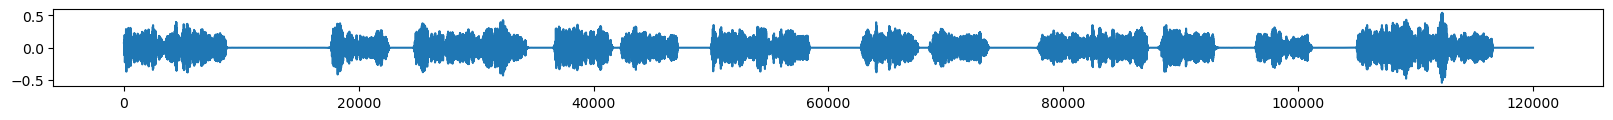

Finished epoch number 176 with a total of 10000 debug_seqs
 time: 2025-10-25 18:39:46.601351, epoch 177,  Loss: 0.2540
  Quantizer 0 Loss: 2.1643
  Quantizer 1 Loss: 3.1520
  Quantizer 2 Loss: 3.9459
  Quantizer 3 Loss: 4.4451
  Quantizer 4 Loss: 4.7631
  Quantizer 5 Loss: 4.9666
  Quantizer 6 Loss: 5.2064
  Quantizer 7 Loss: 5.3024
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


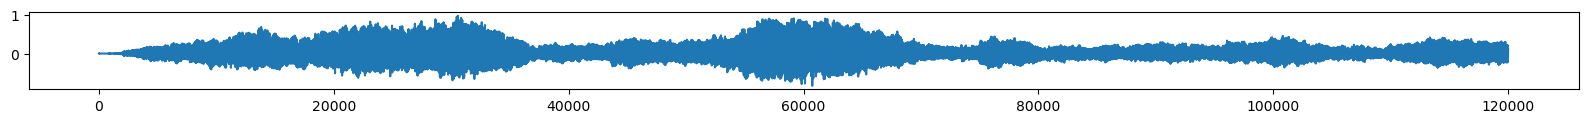

Finished epoch number 177 with a total of 10000 debug_seqs
 time: 2025-10-25 18:40:34.740882, epoch 178,  Loss: 0.2493
  Quantizer 0 Loss: 2.1560
  Quantizer 1 Loss: 3.1328
  Quantizer 2 Loss: 3.9093
  Quantizer 3 Loss: 4.4051
  Quantizer 4 Loss: 4.7234
  Quantizer 5 Loss: 4.9283
  Quantizer 6 Loss: 5.1655
  Quantizer 7 Loss: 5.2704
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


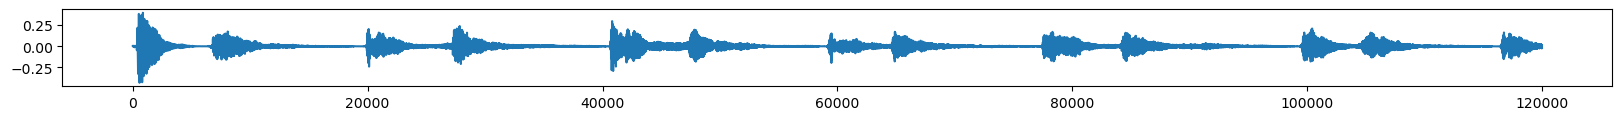

Finished epoch number 178 with a total of 10000 debug_seqs
 time: 2025-10-25 18:41:22.472227, epoch 179,  Loss: 0.2477
  Quantizer 0 Loss: 2.1606
  Quantizer 1 Loss: 3.1124
  Quantizer 2 Loss: 3.8853
  Quantizer 3 Loss: 4.3623
  Quantizer 4 Loss: 4.6821
  Quantizer 5 Loss: 4.8878
  Quantizer 6 Loss: 5.1182
  Quantizer 7 Loss: 5.2258
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


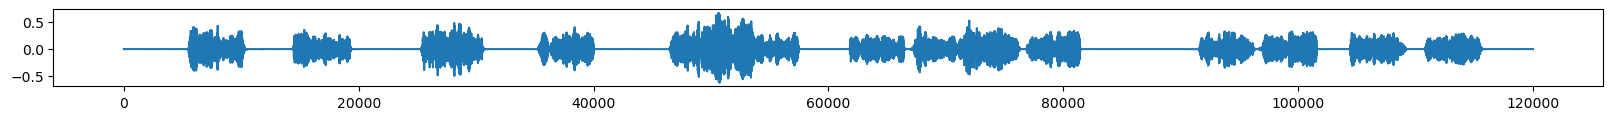

Finished epoch number 179 with a total of 10000 debug_seqs
 time: 2025-10-25 18:42:09.436572, epoch 180,  Loss: 0.2358
  Quantizer 0 Loss: 2.1585
  Quantizer 1 Loss: 3.1045
  Quantizer 2 Loss: 3.8753
  Quantizer 3 Loss: 4.3549
  Quantizer 4 Loss: 4.6682
  Quantizer 5 Loss: 4.8635
  Quantizer 6 Loss: 5.0994
  Quantizer 7 Loss: 5.1997
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


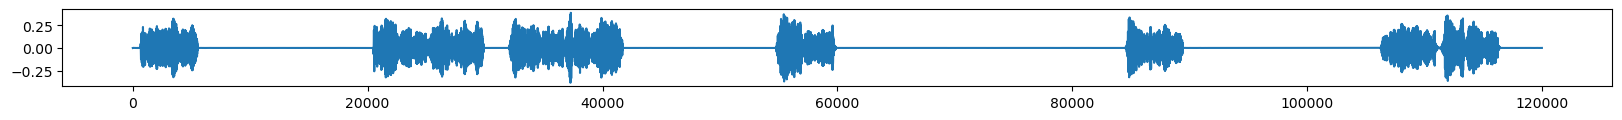

Finished epoch number 180 with a total of 10000 debug_seqs
 time: 2025-10-25 18:42:57.311395, epoch 181,  Loss: 0.2447
  Quantizer 0 Loss: 2.1577
  Quantizer 1 Loss: 3.1038
  Quantizer 2 Loss: 3.8717
  Quantizer 3 Loss: 4.3527
  Quantizer 4 Loss: 4.6676
  Quantizer 5 Loss: 4.8622
  Quantizer 6 Loss: 5.0921
  Quantizer 7 Loss: 5.2004
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


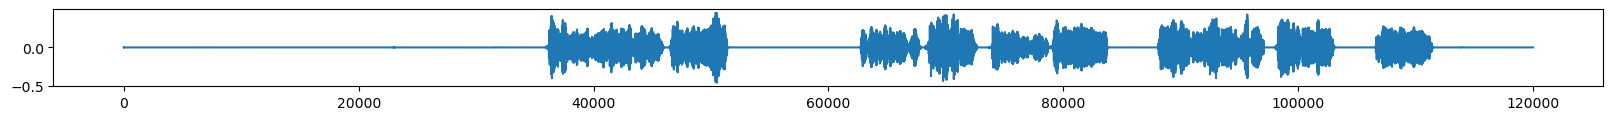

Finished epoch number 181 with a total of 10000 debug_seqs
 time: 2025-10-25 18:43:45.394677, epoch 182,  Loss: 0.2437
  Quantizer 0 Loss: 2.1514
  Quantizer 1 Loss: 3.1021
  Quantizer 2 Loss: 3.8604
  Quantizer 3 Loss: 4.3422
  Quantizer 4 Loss: 4.6565
  Quantizer 5 Loss: 4.8591
  Quantizer 6 Loss: 5.0862
  Quantizer 7 Loss: 5.1960
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


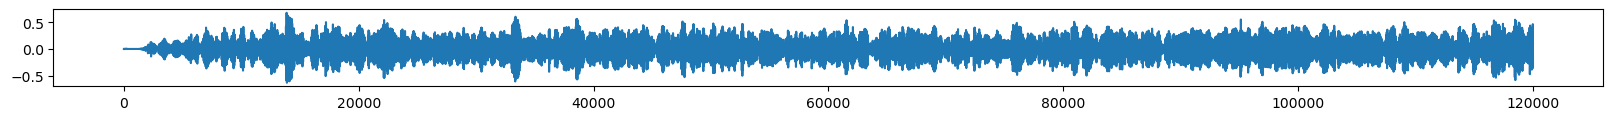

Finished epoch number 182 with a total of 10000 debug_seqs
 time: 2025-10-25 18:44:33.219775, epoch 183,  Loss: 0.2398
  Quantizer 0 Loss: 2.1464
  Quantizer 1 Loss: 3.0839
  Quantizer 2 Loss: 3.8473
  Quantizer 3 Loss: 4.3199
  Quantizer 4 Loss: 4.6343
  Quantizer 5 Loss: 4.8298
  Quantizer 6 Loss: 5.0621
  Quantizer 7 Loss: 5.1658
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


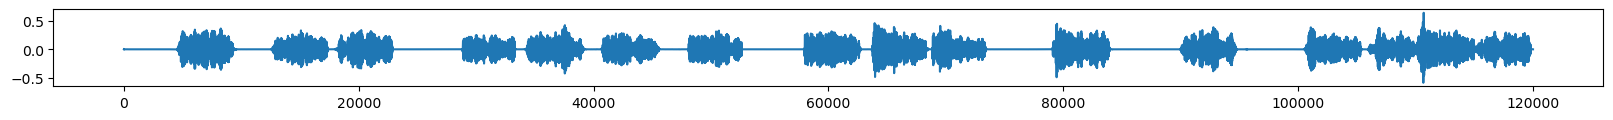

Finished epoch number 183 with a total of 10000 debug_seqs
 time: 2025-10-25 18:45:21.213299, epoch 184,  Loss: 0.2513
  Quantizer 0 Loss: 2.1456
  Quantizer 1 Loss: 3.0891
  Quantizer 2 Loss: 3.8524
  Quantizer 3 Loss: 4.3310
  Quantizer 4 Loss: 4.6432
  Quantizer 5 Loss: 4.8429
  Quantizer 6 Loss: 5.0747
  Quantizer 7 Loss: 5.1791
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


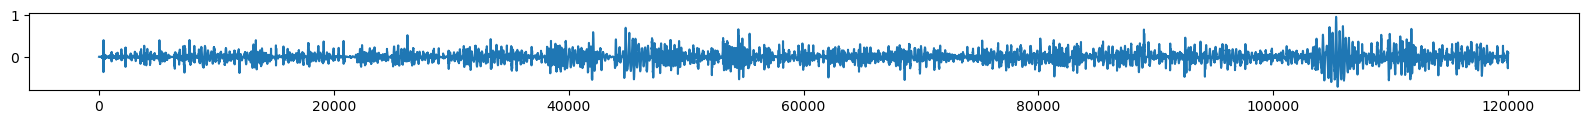

Finished epoch number 184 with a total of 10000 debug_seqs
 time: 2025-10-25 18:46:07.622877, epoch 185,  Loss: 0.2430
  Quantizer 0 Loss: 2.1415
  Quantizer 1 Loss: 3.0736
  Quantizer 2 Loss: 3.8379
  Quantizer 3 Loss: 4.3063
  Quantizer 4 Loss: 4.6207
  Quantizer 5 Loss: 4.8121
  Quantizer 6 Loss: 5.0421
  Quantizer 7 Loss: 5.1492
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


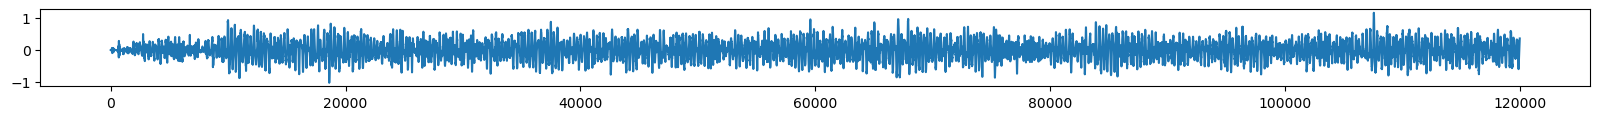

Finished epoch number 185 with a total of 10000 debug_seqs
 time: 2025-10-25 18:46:56.090762, epoch 186,  Loss: 0.2415
  Quantizer 0 Loss: 2.1498
  Quantizer 1 Loss: 3.0901
  Quantizer 2 Loss: 3.8512
  Quantizer 3 Loss: 4.3337
  Quantizer 4 Loss: 4.6376
  Quantizer 5 Loss: 4.8352
  Quantizer 6 Loss: 5.0625
  Quantizer 7 Loss: 5.1701
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


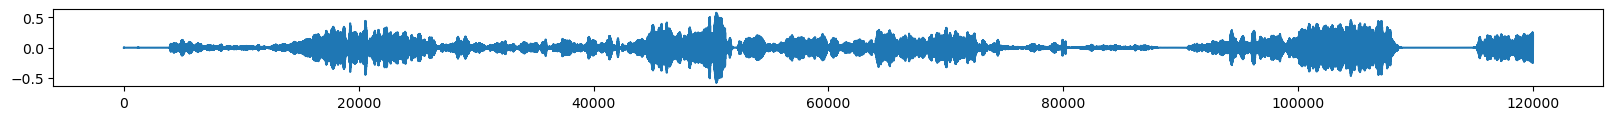

Finished epoch number 186 with a total of 10000 debug_seqs
 time: 2025-10-25 18:47:42.994043, epoch 187,  Loss: 0.2546
  Quantizer 0 Loss: 2.1368
  Quantizer 1 Loss: 3.0750
  Quantizer 2 Loss: 3.8348
  Quantizer 3 Loss: 4.3089
  Quantizer 4 Loss: 4.6238
  Quantizer 5 Loss: 4.8210
  Quantizer 6 Loss: 5.0567
  Quantizer 7 Loss: 5.1658
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


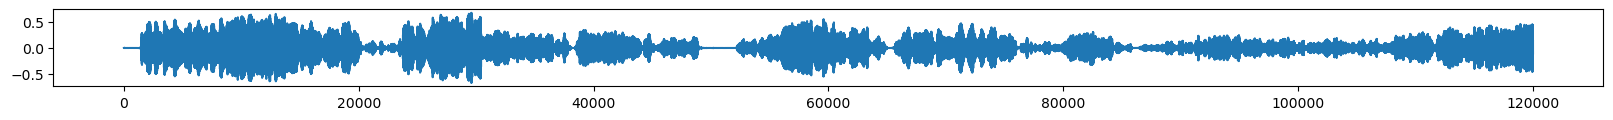

Finished epoch number 187 with a total of 10000 debug_seqs
 time: 2025-10-25 18:48:29.847476, epoch 188,  Loss: 0.2374
  Quantizer 0 Loss: 2.1413
  Quantizer 1 Loss: 3.0846
  Quantizer 2 Loss: 3.8412
  Quantizer 3 Loss: 4.3151
  Quantizer 4 Loss: 4.6273
  Quantizer 5 Loss: 4.8216
  Quantizer 6 Loss: 5.0510
  Quantizer 7 Loss: 5.1607
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


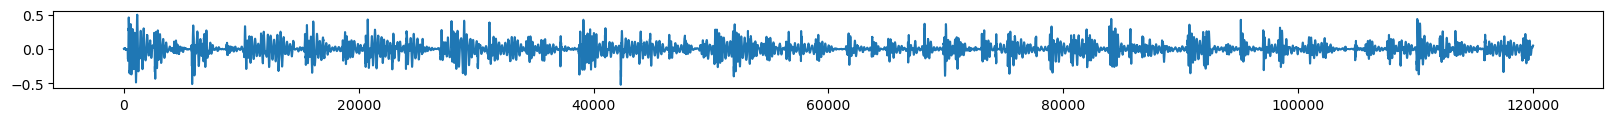

Finished epoch number 188 with a total of 10000 debug_seqs
 time: 2025-10-25 18:49:16.697728, epoch 189,  Loss: 0.2452
  Quantizer 0 Loss: 2.1350
  Quantizer 1 Loss: 3.0680
  Quantizer 2 Loss: 3.8343
  Quantizer 3 Loss: 4.3062
  Quantizer 4 Loss: 4.6181
  Quantizer 5 Loss: 4.8163
  Quantizer 6 Loss: 5.0452
  Quantizer 7 Loss: 5.1504
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


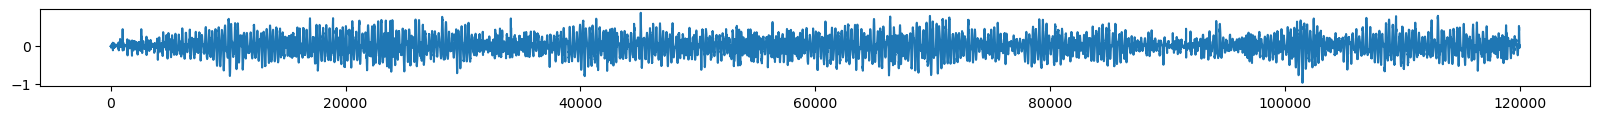

Finished epoch number 189 with a total of 10000 debug_seqs
 time: 2025-10-25 18:50:03.674254, epoch 190,  Loss: 0.2413
  Quantizer 0 Loss: 2.1559
  Quantizer 1 Loss: 3.0908
  Quantizer 2 Loss: 3.8498
  Quantizer 3 Loss: 4.3220
  Quantizer 4 Loss: 4.6352
  Quantizer 5 Loss: 4.8311
  Quantizer 6 Loss: 5.0549
  Quantizer 7 Loss: 5.1621
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


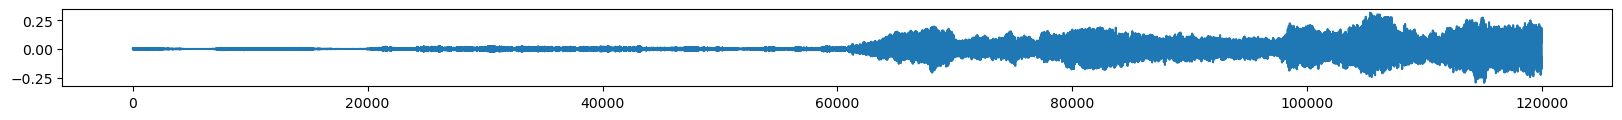

Finished epoch number 190 with a total of 10000 debug_seqs
 time: 2025-10-25 18:50:50.511799, epoch 191,  Loss: 0.2368
  Quantizer 0 Loss: 2.1460
  Quantizer 1 Loss: 3.0878
  Quantizer 2 Loss: 3.8455
  Quantizer 3 Loss: 4.3194
  Quantizer 4 Loss: 4.6363
  Quantizer 5 Loss: 4.8347
  Quantizer 6 Loss: 5.0605
  Quantizer 7 Loss: 5.1697
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


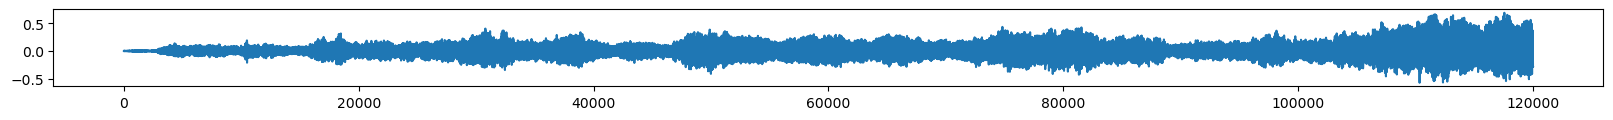

Finished epoch number 191 with a total of 10000 debug_seqs
 time: 2025-10-25 18:51:36.881001, epoch 192,  Loss: 0.2471
  Quantizer 0 Loss: 2.1552
  Quantizer 1 Loss: 3.0878
  Quantizer 2 Loss: 3.8486
  Quantizer 3 Loss: 4.3213
  Quantizer 4 Loss: 4.6299
  Quantizer 5 Loss: 4.8220
  Quantizer 6 Loss: 5.0502
  Quantizer 7 Loss: 5.1642
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


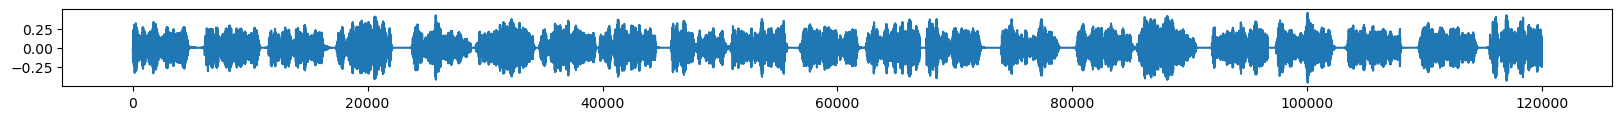

Finished epoch number 192 with a total of 10000 debug_seqs
 time: 2025-10-25 18:52:23.726320, epoch 193,  Loss: 0.2426
  Quantizer 0 Loss: 2.1581
  Quantizer 1 Loss: 3.0848
  Quantizer 2 Loss: 3.8441
  Quantizer 3 Loss: 4.3203
  Quantizer 4 Loss: 4.6338
  Quantizer 5 Loss: 4.8290
  Quantizer 6 Loss: 5.0578
  Quantizer 7 Loss: 5.1600
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


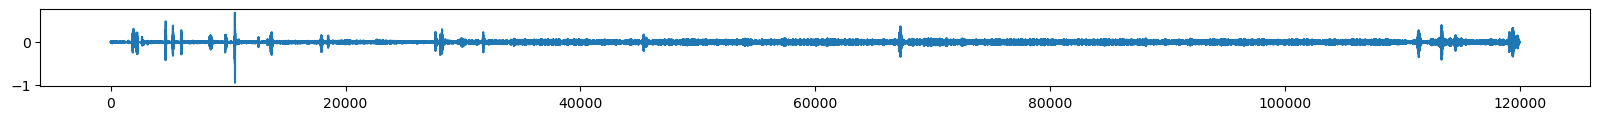

Finished epoch number 193 with a total of 10000 debug_seqs
 time: 2025-10-25 18:53:10.016379, epoch 194,  Loss: 0.2413
  Quantizer 0 Loss: 2.1395
  Quantizer 1 Loss: 3.0726
  Quantizer 2 Loss: 3.8364
  Quantizer 3 Loss: 4.3124
  Quantizer 4 Loss: 4.6178
  Quantizer 5 Loss: 4.8171
  Quantizer 6 Loss: 5.0496
  Quantizer 7 Loss: 5.1507
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


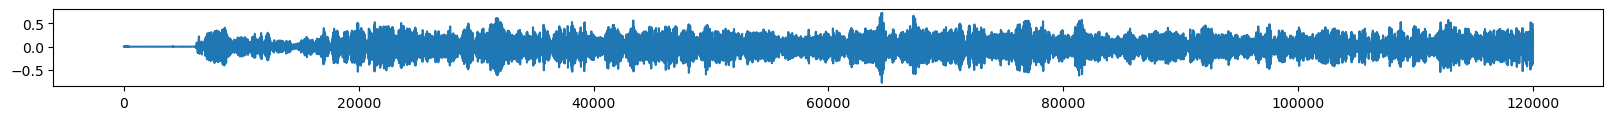

Finished epoch number 194 with a total of 10000 debug_seqs
 time: 2025-10-25 18:53:57.965506, epoch 195,  Loss: 0.2314
  Quantizer 0 Loss: 2.1453
  Quantizer 1 Loss: 3.0731
  Quantizer 2 Loss: 3.8301
  Quantizer 3 Loss: 4.3049
  Quantizer 4 Loss: 4.6157
  Quantizer 5 Loss: 4.8147
  Quantizer 6 Loss: 5.0395
  Quantizer 7 Loss: 5.1488
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


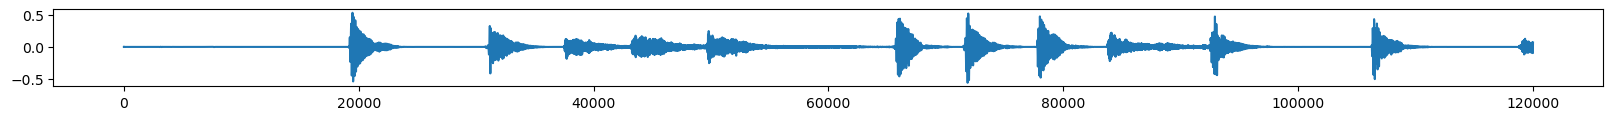

Finished epoch number 195 with a total of 10000 debug_seqs
 time: 2025-10-25 18:54:46.258055, epoch 196,  Loss: 0.2388
  Quantizer 0 Loss: 2.1400
  Quantizer 1 Loss: 3.0705
  Quantizer 2 Loss: 3.8340
  Quantizer 3 Loss: 4.3097
  Quantizer 4 Loss: 4.6239
  Quantizer 5 Loss: 4.8153
  Quantizer 6 Loss: 5.0467
  Quantizer 7 Loss: 5.1538
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


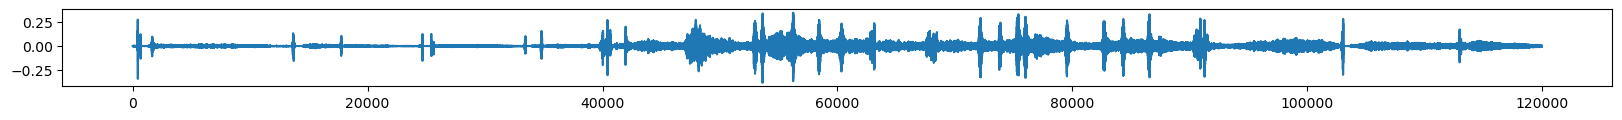

Finished epoch number 196 with a total of 10000 debug_seqs
 time: 2025-10-25 18:55:33.802888, epoch 197,  Loss: 0.2382
  Quantizer 0 Loss: 2.1465
  Quantizer 1 Loss: 3.0687
  Quantizer 2 Loss: 3.8312
  Quantizer 3 Loss: 4.3055
  Quantizer 4 Loss: 4.6101
  Quantizer 5 Loss: 4.8045
  Quantizer 6 Loss: 5.0348
  Quantizer 7 Loss: 5.1389
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


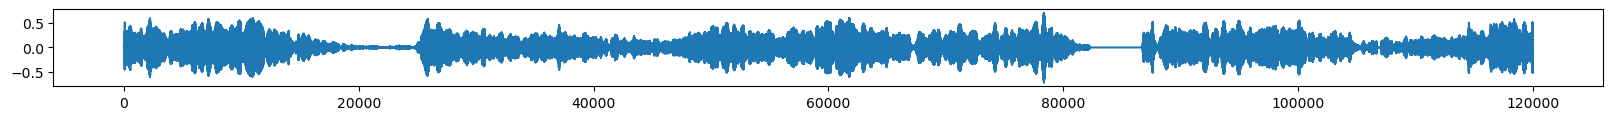

Finished epoch number 197 with a total of 10000 debug_seqs
 time: 2025-10-25 18:56:21.591518, epoch 198,  Loss: 0.2460
  Quantizer 0 Loss: 2.1505
  Quantizer 1 Loss: 3.0865
  Quantizer 2 Loss: 3.8482
  Quantizer 3 Loss: 4.3234
  Quantizer 4 Loss: 4.6350
  Quantizer 5 Loss: 4.8325
  Quantizer 6 Loss: 5.0637
  Quantizer 7 Loss: 5.1677
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


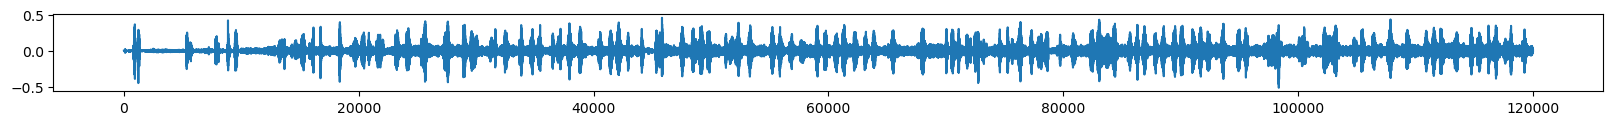

Finished epoch number 198 with a total of 10000 debug_seqs
 time: 2025-10-25 18:57:08.395620, epoch 199,  Loss: 0.2477
  Quantizer 0 Loss: 2.1470
  Quantizer 1 Loss: 3.0892
  Quantizer 2 Loss: 3.8436
  Quantizer 3 Loss: 4.3178
  Quantizer 4 Loss: 4.6293
  Quantizer 5 Loss: 4.8223
  Quantizer 6 Loss: 5.0577
  Quantizer 7 Loss: 5.1697
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


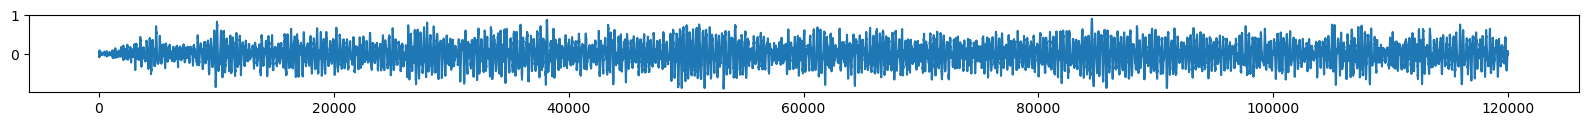

Finished epoch number 199 with a total of 10000 debug_seqs
 time: 2025-10-25 18:57:55.484897, epoch 200,  Loss: 0.2444
  Quantizer 0 Loss: 2.1492
  Quantizer 1 Loss: 3.0815
  Quantizer 2 Loss: 3.8383
  Quantizer 3 Loss: 4.3170
  Quantizer 4 Loss: 4.6230
  Quantizer 5 Loss: 4.8182
  Quantizer 6 Loss: 5.0560
  Quantizer 7 Loss: 5.1607
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


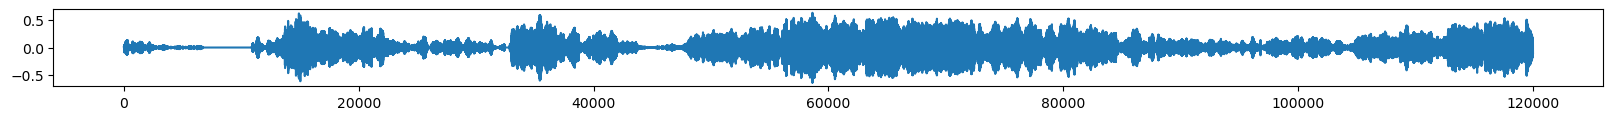

Saved checkpoint at epoch 200
Finished epoch number 200 with a total of 10000 debug_seqs
 time: 2025-10-25 18:58:43.052401, epoch 201,  Loss: 0.2257
  Quantizer 0 Loss: 2.1428
  Quantizer 1 Loss: 2.7734
  Quantizer 2 Loss: 3.4969
  Quantizer 3 Loss: 3.9970
  Quantizer 4 Loss: 4.3396
  Quantizer 5 Loss: 4.5516
  Quantizer 6 Loss: 4.8054
  Quantizer 7 Loss: 4.9323
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


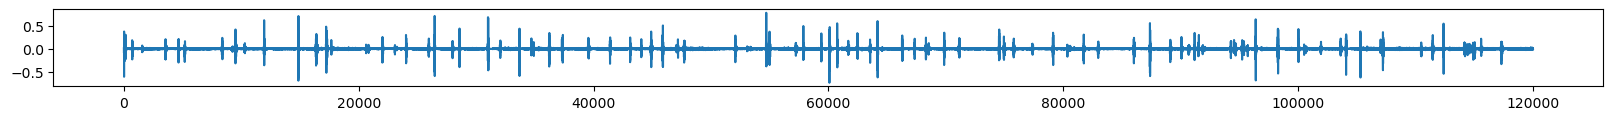

Finished epoch number 201 with a total of 10000 debug_seqs
 time: 2025-10-25 18:59:29.386255, epoch 202,  Loss: 0.2248
  Quantizer 0 Loss: 2.1406
  Quantizer 1 Loss: 2.6857
  Quantizer 2 Loss: 3.3807
  Quantizer 3 Loss: 3.8582
  Quantizer 4 Loss: 4.1924
  Quantizer 5 Loss: 4.4128
  Quantizer 6 Loss: 4.6610
  Quantizer 7 Loss: 4.8010
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


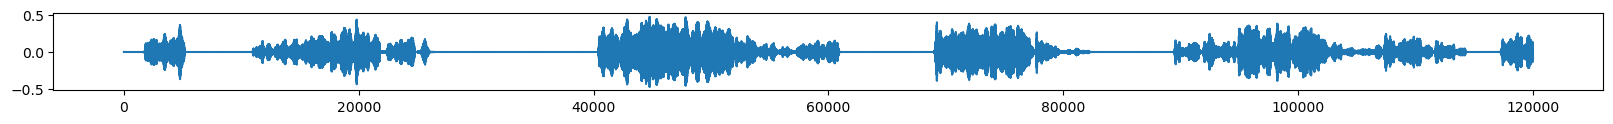

Finished epoch number 202 with a total of 10000 debug_seqs
 time: 2025-10-25 19:00:15.576891, epoch 203,  Loss: 0.2200
  Quantizer 0 Loss: 2.1447
  Quantizer 1 Loss: 2.6818
  Quantizer 2 Loss: 3.3574
  Quantizer 3 Loss: 3.8241
  Quantizer 4 Loss: 4.1524
  Quantizer 5 Loss: 4.3648
  Quantizer 6 Loss: 4.6172
  Quantizer 7 Loss: 4.7534
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


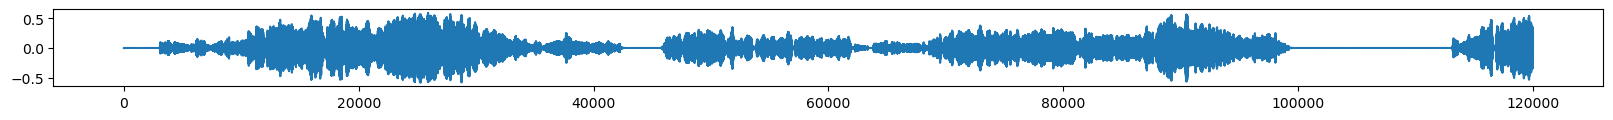

Finished epoch number 203 with a total of 10000 debug_seqs
 time: 2025-10-25 19:01:03.106859, epoch 204,  Loss: 0.2215
  Quantizer 0 Loss: 2.1415
  Quantizer 1 Loss: 2.6729
  Quantizer 2 Loss: 3.3431
  Quantizer 3 Loss: 3.8061
  Quantizer 4 Loss: 4.1301
  Quantizer 5 Loss: 4.3449
  Quantizer 6 Loss: 4.5934
  Quantizer 7 Loss: 4.7322
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


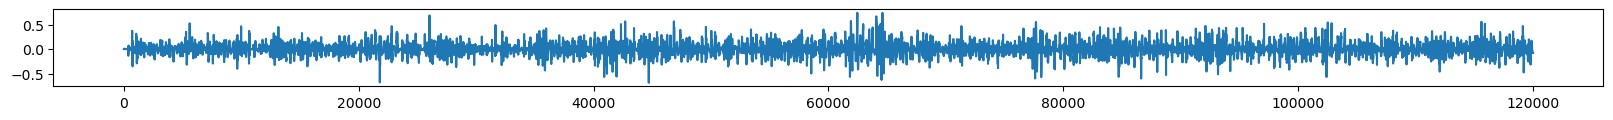

Finished epoch number 204 with a total of 10000 debug_seqs
 time: 2025-10-25 19:01:49.400290, epoch 205,  Loss: 0.2266
  Quantizer 0 Loss: 2.1358
  Quantizer 1 Loss: 2.6528
  Quantizer 2 Loss: 3.3201
  Quantizer 3 Loss: 3.7851
  Quantizer 4 Loss: 4.1035
  Quantizer 5 Loss: 4.3139
  Quantizer 6 Loss: 4.5627
  Quantizer 7 Loss: 4.6990
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


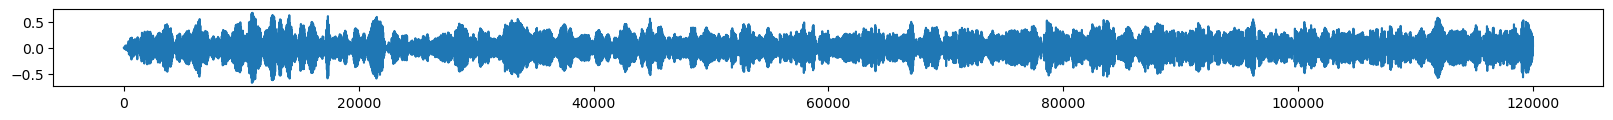

Finished epoch number 205 with a total of 10000 debug_seqs
 time: 2025-10-25 19:02:36.682642, epoch 206,  Loss: 0.2064
  Quantizer 0 Loss: 2.1367
  Quantizer 1 Loss: 2.6496
  Quantizer 2 Loss: 3.3093
  Quantizer 3 Loss: 3.7697
  Quantizer 4 Loss: 4.0922
  Quantizer 5 Loss: 4.3005
  Quantizer 6 Loss: 4.5452
  Quantizer 7 Loss: 4.6802
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


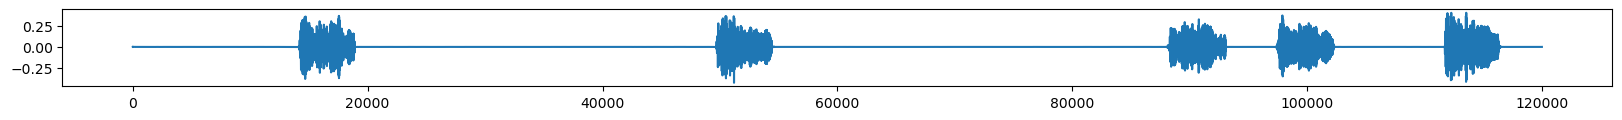

Finished epoch number 206 with a total of 10000 debug_seqs
 time: 2025-10-25 19:03:23.710805, epoch 207,  Loss: 0.2240
  Quantizer 0 Loss: 2.1397
  Quantizer 1 Loss: 2.6606
  Quantizer 2 Loss: 3.3170
  Quantizer 3 Loss: 3.7749
  Quantizer 4 Loss: 4.0961
  Quantizer 5 Loss: 4.3032
  Quantizer 6 Loss: 4.5520
  Quantizer 7 Loss: 4.6816
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


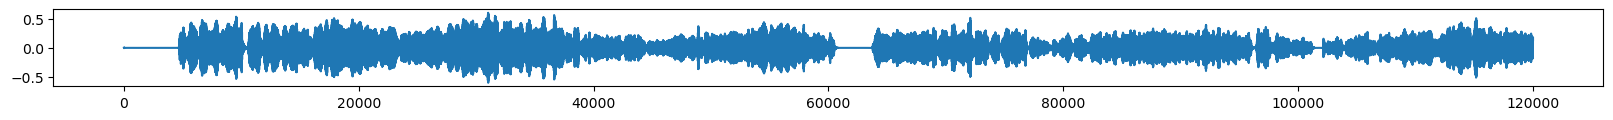

Finished epoch number 207 with a total of 10000 debug_seqs
 time: 2025-10-25 19:04:10.490104, epoch 208,  Loss: 0.2142
  Quantizer 0 Loss: 2.1490
  Quantizer 1 Loss: 2.6692
  Quantizer 2 Loss: 3.3227
  Quantizer 3 Loss: 3.7772
  Quantizer 4 Loss: 4.0975
  Quantizer 5 Loss: 4.3030
  Quantizer 6 Loss: 4.5531
  Quantizer 7 Loss: 4.6880
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


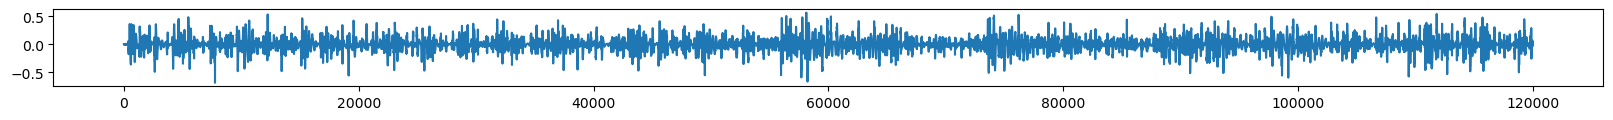

Finished epoch number 208 with a total of 10000 debug_seqs
 time: 2025-10-25 19:04:58.048145, epoch 209,  Loss: 0.2176
  Quantizer 0 Loss: 2.1514
  Quantizer 1 Loss: 2.6593
  Quantizer 2 Loss: 3.3236
  Quantizer 3 Loss: 3.7812
  Quantizer 4 Loss: 4.0955
  Quantizer 5 Loss: 4.3084
  Quantizer 6 Loss: 4.5565
  Quantizer 7 Loss: 4.6927
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


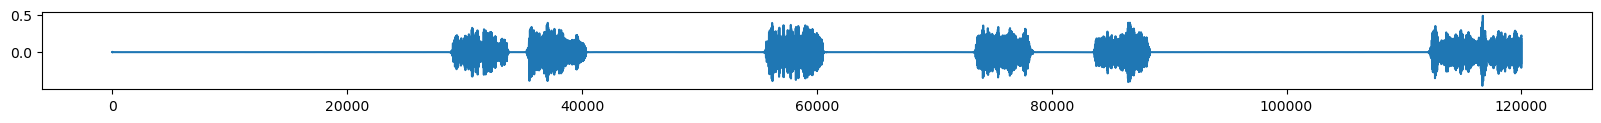

Finished epoch number 209 with a total of 10000 debug_seqs
 time: 2025-10-25 19:05:44.706142, epoch 210,  Loss: 0.2127
  Quantizer 0 Loss: 2.1482
  Quantizer 1 Loss: 2.6625
  Quantizer 2 Loss: 3.3216
  Quantizer 3 Loss: 3.7776
  Quantizer 4 Loss: 4.0935
  Quantizer 5 Loss: 4.3023
  Quantizer 6 Loss: 4.5488
  Quantizer 7 Loss: 4.6847
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


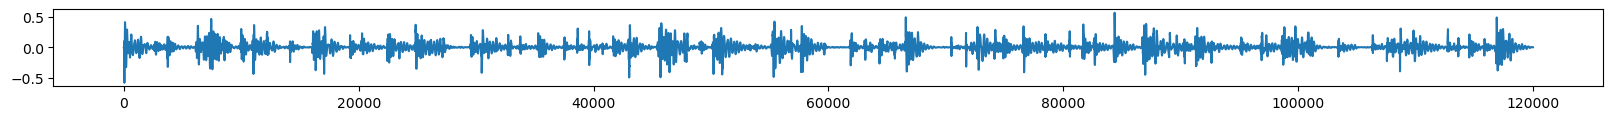

Finished epoch number 210 with a total of 10000 debug_seqs
 time: 2025-10-25 19:06:31.374552, epoch 211,  Loss: 0.2166
  Quantizer 0 Loss: 2.1413
  Quantizer 1 Loss: 2.6515
  Quantizer 2 Loss: 3.3052
  Quantizer 3 Loss: 3.7588
  Quantizer 4 Loss: 4.0821
  Quantizer 5 Loss: 4.2847
  Quantizer 6 Loss: 4.5326
  Quantizer 7 Loss: 4.6663
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


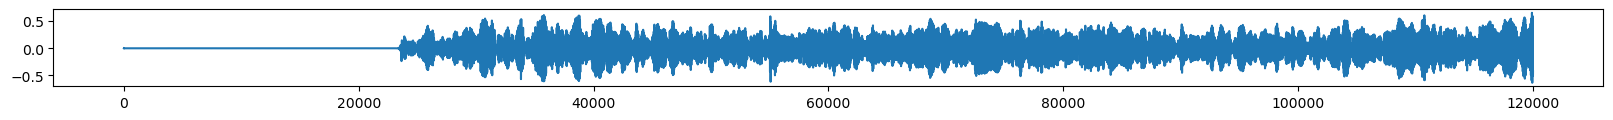

Finished epoch number 211 with a total of 10000 debug_seqs
 time: 2025-10-25 19:07:18.868108, epoch 212,  Loss: 0.2097
  Quantizer 0 Loss: 2.1509
  Quantizer 1 Loss: 2.6587
  Quantizer 2 Loss: 3.3148
  Quantizer 3 Loss: 3.7650
  Quantizer 4 Loss: 4.0783
  Quantizer 5 Loss: 4.2858
  Quantizer 6 Loss: 4.5316
  Quantizer 7 Loss: 4.6619
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


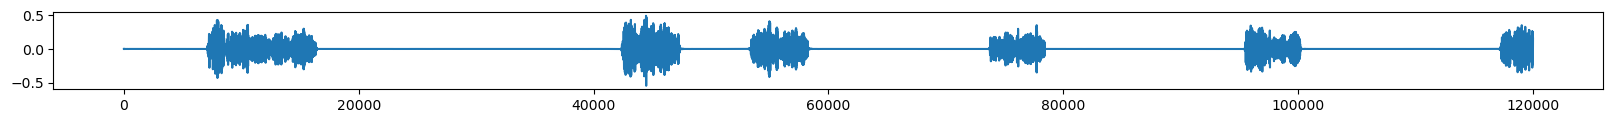

Finished epoch number 212 with a total of 10000 debug_seqs
 time: 2025-10-25 19:08:06.689084, epoch 213,  Loss: 0.2182
  Quantizer 0 Loss: 2.1456
  Quantizer 1 Loss: 2.6534
  Quantizer 2 Loss: 3.3078
  Quantizer 3 Loss: 3.7644
  Quantizer 4 Loss: 4.0811
  Quantizer 5 Loss: 4.2939
  Quantizer 6 Loss: 4.5358
  Quantizer 7 Loss: 4.6709
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


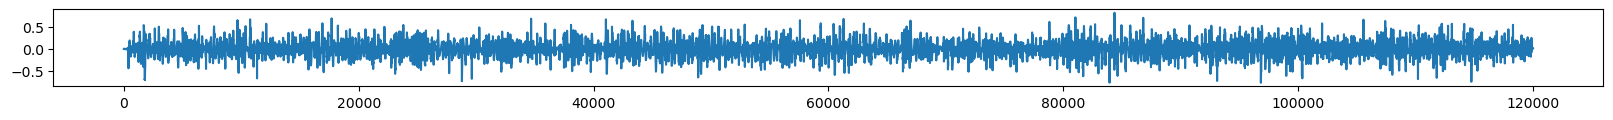

Finished epoch number 213 with a total of 10000 debug_seqs
 time: 2025-10-25 19:08:53.282012, epoch 214,  Loss: 0.2127
  Quantizer 0 Loss: 2.1436
  Quantizer 1 Loss: 2.6421
  Quantizer 2 Loss: 3.2979
  Quantizer 3 Loss: 3.7458
  Quantizer 4 Loss: 4.0680
  Quantizer 5 Loss: 4.2774
  Quantizer 6 Loss: 4.5169
  Quantizer 7 Loss: 4.6579
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


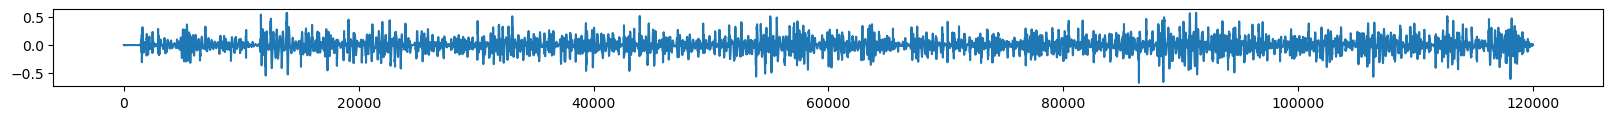

Finished epoch number 214 with a total of 10000 debug_seqs
 time: 2025-10-25 19:09:40.155709, epoch 215,  Loss: 0.2064
  Quantizer 0 Loss: 2.1298
  Quantizer 1 Loss: 2.6335
  Quantizer 2 Loss: 3.2822
  Quantizer 3 Loss: 3.7360
  Quantizer 4 Loss: 4.0599
  Quantizer 5 Loss: 4.2636
  Quantizer 6 Loss: 4.5093
  Quantizer 7 Loss: 4.6440
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


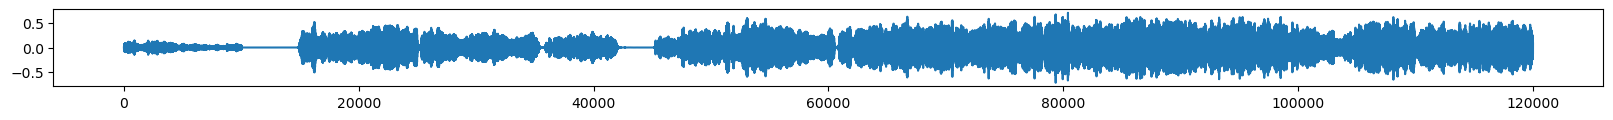

Finished epoch number 215 with a total of 10000 debug_seqs
 time: 2025-10-25 19:10:28.286768, epoch 216,  Loss: 0.2217
  Quantizer 0 Loss: 2.1441
  Quantizer 1 Loss: 2.6505
  Quantizer 2 Loss: 3.2966
  Quantizer 3 Loss: 3.7540
  Quantizer 4 Loss: 4.0654
  Quantizer 5 Loss: 4.2709
  Quantizer 6 Loss: 4.5229
  Quantizer 7 Loss: 4.6606
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


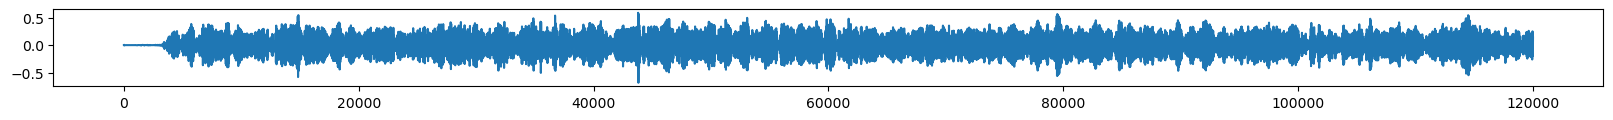

Finished epoch number 216 with a total of 10000 debug_seqs
 time: 2025-10-25 19:11:15.367923, epoch 217,  Loss: 0.2240
  Quantizer 0 Loss: 2.1352
  Quantizer 1 Loss: 2.6439
  Quantizer 2 Loss: 3.2901
  Quantizer 3 Loss: 3.7409
  Quantizer 4 Loss: 4.0645
  Quantizer 5 Loss: 4.2690
  Quantizer 6 Loss: 4.5172
  Quantizer 7 Loss: 4.6567
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


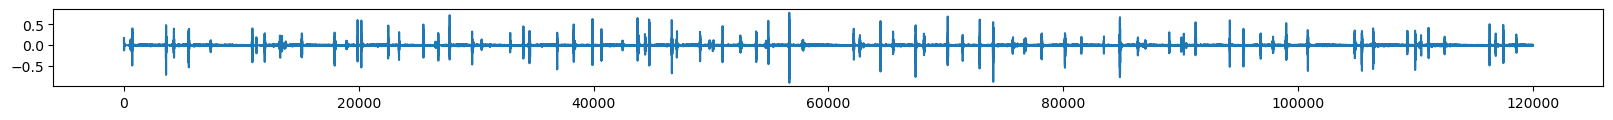

Finished epoch number 217 with a total of 10000 debug_seqs
 time: 2025-10-25 19:12:02.521478, epoch 218,  Loss: 0.2094
  Quantizer 0 Loss: 2.1314
  Quantizer 1 Loss: 2.6354
  Quantizer 2 Loss: 3.2833
  Quantizer 3 Loss: 3.7385
  Quantizer 4 Loss: 4.0601
  Quantizer 5 Loss: 4.2670
  Quantizer 6 Loss: 4.5151
  Quantizer 7 Loss: 4.6479
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


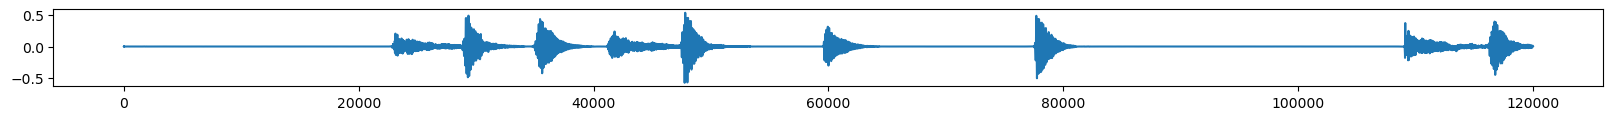

Finished epoch number 218 with a total of 10000 debug_seqs
 time: 2025-10-25 19:12:49.117832, epoch 219,  Loss: 0.2138
  Quantizer 0 Loss: 2.1495
  Quantizer 1 Loss: 2.6522
  Quantizer 2 Loss: 3.3021
  Quantizer 3 Loss: 3.7541
  Quantizer 4 Loss: 4.0706
  Quantizer 5 Loss: 4.2785
  Quantizer 6 Loss: 4.5213
  Quantizer 7 Loss: 4.6590
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


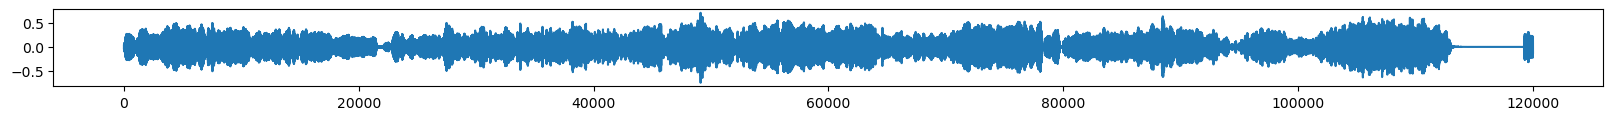

Finished epoch number 219 with a total of 10000 debug_seqs
 time: 2025-10-25 19:13:36.443670, epoch 220,  Loss: 0.2198
  Quantizer 0 Loss: 2.1399
  Quantizer 1 Loss: 2.6399
  Quantizer 2 Loss: 3.2995
  Quantizer 3 Loss: 3.7487
  Quantizer 4 Loss: 4.0641
  Quantizer 5 Loss: 4.2714
  Quantizer 6 Loss: 4.5173
  Quantizer 7 Loss: 4.6579
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


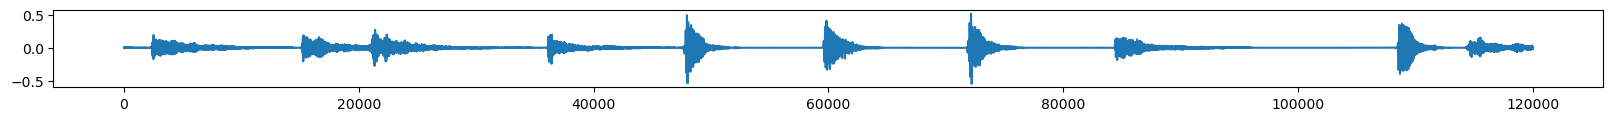

Finished epoch number 220 with a total of 10000 debug_seqs
 time: 2025-10-25 19:14:23.960386, epoch 221,  Loss: 0.2235
  Quantizer 0 Loss: 2.1424
  Quantizer 1 Loss: 2.6434
  Quantizer 2 Loss: 3.2977
  Quantizer 3 Loss: 3.7468
  Quantizer 4 Loss: 4.0611
  Quantizer 5 Loss: 4.2695
  Quantizer 6 Loss: 4.5114
  Quantizer 7 Loss: 4.6539
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


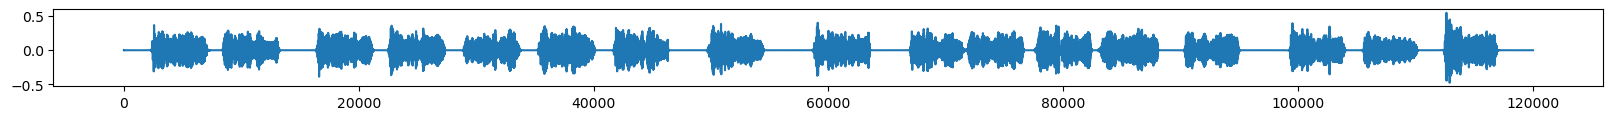

Finished epoch number 221 with a total of 10000 debug_seqs
 time: 2025-10-25 19:15:12.149730, epoch 222,  Loss: 0.2160
  Quantizer 0 Loss: 2.1385
  Quantizer 1 Loss: 2.6346
  Quantizer 2 Loss: 3.2884
  Quantizer 3 Loss: 3.7329
  Quantizer 4 Loss: 4.0554
  Quantizer 5 Loss: 4.2604
  Quantizer 6 Loss: 4.5041
  Quantizer 7 Loss: 4.6432
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


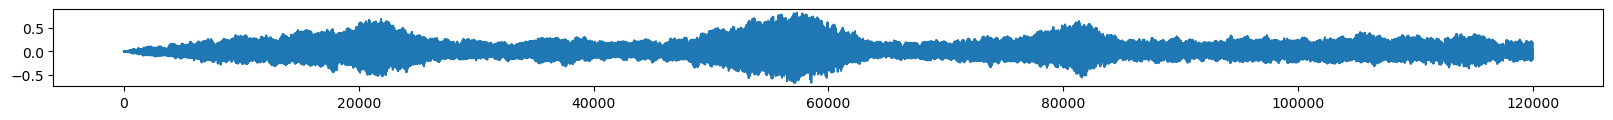

Finished epoch number 222 with a total of 10000 debug_seqs
 time: 2025-10-25 19:15:59.030471, epoch 223,  Loss: 0.2220
  Quantizer 0 Loss: 2.1478
  Quantizer 1 Loss: 2.6511
  Quantizer 2 Loss: 3.3028
  Quantizer 3 Loss: 3.7575
  Quantizer 4 Loss: 4.0751
  Quantizer 5 Loss: 4.2806
  Quantizer 6 Loss: 4.5316
  Quantizer 7 Loss: 4.6671
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


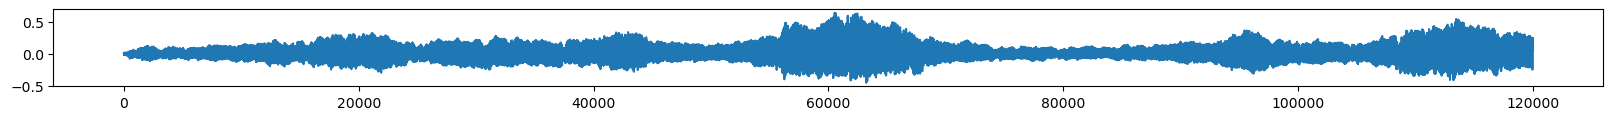

Finished epoch number 223 with a total of 10000 debug_seqs
 time: 2025-10-25 19:16:47.214876, epoch 224,  Loss: 0.2130
  Quantizer 0 Loss: 2.1406
  Quantizer 1 Loss: 2.6373
  Quantizer 2 Loss: 3.2926
  Quantizer 3 Loss: 3.7440
  Quantizer 4 Loss: 4.0612
  Quantizer 5 Loss: 4.2690
  Quantizer 6 Loss: 4.5133
  Quantizer 7 Loss: 4.6498
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


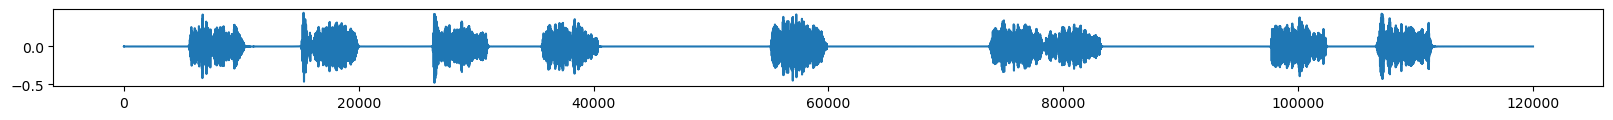

Finished epoch number 224 with a total of 10000 debug_seqs
 time: 2025-10-25 19:17:33.638056, epoch 225,  Loss: 0.2214
  Quantizer 0 Loss: 2.1441
  Quantizer 1 Loss: 2.6480
  Quantizer 2 Loss: 3.2959
  Quantizer 3 Loss: 3.7470
  Quantizer 4 Loss: 4.0656
  Quantizer 5 Loss: 4.2754
  Quantizer 6 Loss: 4.5213
  Quantizer 7 Loss: 4.6570
Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


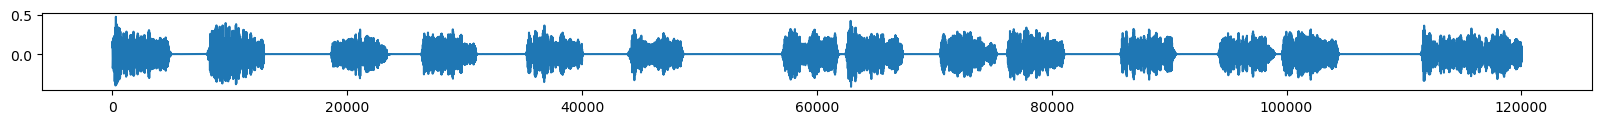

Saved checkpoint at epoch 225
Training time taken: 3:02:41
Saved checkpoint at epoch 225


'/home/lonce/working/RNeNcodec/notebooks/output/20251025_161452_multiclass_test_HARDcascade/checkpoints/last_checkpoint.pt'

In [16]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


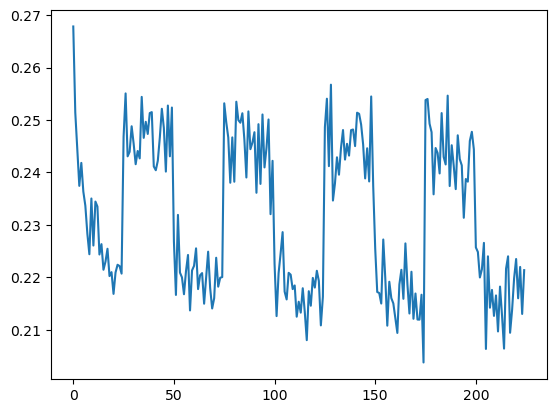

In [17]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [18]:
list_of_losses

[0.2678219909667969,
 0.251412841796875,
 0.24447296142578126,
 0.23744503784179688,
 0.24182206726074218,
 0.2363457794189453,
 0.23365664672851563,
 0.2283192443847656,
 0.22441111755371093,
 0.23503709411621093,
 0.226070556640625,
 0.2344505615234375,
 0.23350202941894532,
 0.22436514282226563,
 0.22633558654785157,
 0.2214586181640625,
 0.2229895477294922,
 0.22545536804199218,
 0.22024893188476563,
 0.2210012664794922,
 0.21685621643066405,
 0.22093882751464844,
 0.22240406799316406,
 0.22216058349609374,
 0.22072161865234374,
 0.24682730102539063,
 0.2550634307861328,
 0.24307154846191406,
 0.24393826293945312,
 0.24880303955078126,
 0.24547093200683595,
 0.24156935119628906,
 0.2440960235595703,
 0.24268553161621093,
 0.25440335083007815,
 0.246593994140625,
 0.24965336608886718,
 0.2473404541015625,
 0.25131797790527344,
 0.2514972381591797,
 0.24114688110351562,
 0.24042340087890626,
 0.24223524475097657,
 0.24667245483398437,
 0.25213310241699216,
 0.2484915771484375,
 0.240